## **IMPORTS**

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
import os
from dotenv import load_dotenv

import src.experiments.config as cfg_module
import src.experiments.simulation as sim_module
import src.experiments.simulation_greedy as sim_greedy
from src.experiments.run import define_agents
from src.metrics.plots_metrics import *
from src.metrics.plots_metrics_comparison import *
from src.metrics.other_metrics import *

pygame 2.6.1 (SDL 2.28.4, Python 3.12.0)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
load_dotenv()

ROOT_PATH = os.getenv("ROOT_PATH")
OUTPUT_DIR = 'outputs'
OUTPUT_PATH = f'{ROOT_PATH}/{OUTPUT_DIR}'
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f'--> outputs logs in: {OUTPUT_PATH}')

--> outputs logs in: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs


## **UTILS**

### **CONFIG**

In [4]:
# --- CONFIG FUNCTION

def notebook_config(
    total_time=None,
    nb_car=None,
    nb_society=None,
    nb_station=None,
    base_car_behavior=None,
    station_strategy_noise=None,
    log_iter=None
):
    """
    Crée et configure un objet SimulationConfig
    pour les notebooks/tests.
    """

    config = cfg_module.SimulationConfig()

    # ------------------------------------------------ VISUALISATION
    config.set_VISUALIZE(False)

    # ------------------------------------------------ TEMPS
    if total_time is not None:
        config.set_TOTAL_TIME(total_time)

    if log_iter is not None:
        config.set_log_iter(log_iter)

    # ------------------------------------------------ AGENTS
    if nb_car is not None:

        if type(nb_car) is not int:
            raise TypeError(
                f"nb_car doit être un int, reçu : {type(nb_car).__name__}"
            )

        if nb_car <= 0:
            raise ValueError("nb_car doit être > 0")

        config.NB_CARS = nb_car

    if nb_society is not None:

        if type(nb_society) is not int:
            raise TypeError(
                f"nb_society doit être un int, reçu : {type(nb_society).__name__}"
            )

        if nb_society <= 0:
            raise ValueError("nb_society doit être > 0")

        config.NB_SOCIETIES = nb_society

    if nb_station is not None:

        if type(nb_station) is not int:
            raise TypeError(
                f"nb_station doit être un int, reçu : {type(nb_station).__name__}"
            )

        if nb_station <= 0:
            raise ValueError("nb_station doit être > 0")

        config.NB_STATIONS = nb_station

    # ------------------------------------------------ COMPORTEMENTS VOITURES
    if base_car_behavior is not None:

        required_keys = {
            'pres',
            'abs',
            'early',
            'late',
            'noise'
        }

        missing = required_keys - set(base_car_behavior.keys())

        if missing:
            raise ValueError(
                f"Clés manquantes dans base_car_behavior : {missing}"
            )

        total_prob = (
            base_car_behavior['pres']
            + base_car_behavior['abs']
            + base_car_behavior['early']
            + base_car_behavior['late']
        )

        if total_prob != 100:
            raise ValueError(
                f"La somme des probabilités doit valoir 100, reçu : {total_prob}"
            )

        config.BASE_CANCEL_PROB = base_car_behavior.copy()

    # ------------------------------------------------ BRUIT STRATÉGIE STATION
    if station_strategy_noise is not None:

        if not isinstance(station_strategy_noise, (int, float)):
            raise TypeError(
                "station_strategy_noise doit être numérique"
            )

        if station_strategy_noise < 0:
            raise ValueError(
                "station_strategy_noise doit être >= 0"
            )

        config.STRATEGY_NOISE = float(station_strategy_noise)

    return config

In [5]:
# --- EXAMPLE

total_time = 12 * 24 * 1  # une journée
log_iter = 12

nb_car = 50
nb_society = 4
nb_station = 40

strategy_noise = 0.5  # variation proportionnelle ±50%

base_car_behavior = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

c = notebook_config(total_time=total_time, nb_car=nb_car, nb_society=nb_society,
                nb_station=nb_station, base_car_behavior=base_car_behavior,
                station_strategy_noise=strategy_noise, log_iter=log_iter)

slot_h = c.SLOT_DURATION / 60
dist_slot = c.CAR_SPEED          # m/slot
autonomy_mean = c.CAR_AUTONOMY_PARAMS_KM['mean']
conso = c.ENERGY_CONSUMPTION['quantity_kW'] / c.ENERGY_CONSUMPTION['distance_unit_m']
delta_soc = dist_slot * conso / (c.ENERGY_CONSUMPTION['quantity_kW'] * autonomy_mean / 100)

print(f"Grille            : {c.C_GRID/1e3:.1f} km × {c.C_GRID/1e3:.1f} km")
print(f"Vitesse           : {c.CAR_SPEED} m/slot  ({c.CAR_SPEED/1000/slot_h:.0f} km/h)")
print(f"ΔSoC / slot       : {delta_soc:.5f}  ({1/delta_soc:.0f} slots pour vider)")
print(f"Autonomie moy.    : {autonomy_mean} km")
print(f"Distance max grille traversée avec soc=0.10 : {0.10*autonomy_mean:.0f} km >> {c.C_GRID/1e3:.1f} km ✓")


Grille            : 3.0 km × 3.0 km
Vitesse           : 4167.0 m/slot  (50 km/h)
ΔSoC / slot       : 0.01042  (96 slots pour vider)
Autonomie moy.    : 400 km
Distance max grille traversée avec soc=0.10 : 40 km >> 3.0 km ✓


### **CHARTS**

#### *Demand Satisfaction*

In [6]:
def plot_exact_needs_comparison(exact_values, needs_values, labels, colors,
                                scenario_name, nb_car):

    # Création des graphiques côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Graphique Exact --------
    bars1 = axes[0].bar(labels, exact_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Exact Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[0].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[0].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Graphique Needs --------
    bars2 = axes[1].bar(labels, needs_values, color=colors, alpha=0.7)
    

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Needs Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[1].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[1].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Travel & Waiting*

In [7]:
def plot_travel_waiting_comparison(travel_values, waiting_values, labels, colors,
                                scenario_name, nb_car):

    # Création des subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Travel Distance --------
    bars1 = axes[0].bar(labels, travel_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Travel Distance (km)', fontweight='bold')
    axes[0].set_ylabel('Distance (km)')
    axes[0].set_ylim(top = 1.15 * max(travel_values))

    # Valeurs sur les barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Waiting Time --------
    bars2 = axes[1].bar(labels, waiting_values, color=colors, alpha=0.7)

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Waiting Time (min)', fontweight='bold')
    axes[1].set_ylabel('Time (min)')
    if max(waiting_values) > 0.:
        axes[1].set_ylim(top = 1.15 * max(waiting_values))
    else:
        axes[1].set_ylim(bottom = 0. ,top = 5.)

    # Valeurs sur les barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Scalability*

In [8]:
def plot_mean_response_time_comparison(labels, colors, values, scenario_name, nb_car):

    fig, ax = plt.subplots(figsize=(6, 5))

    bars = ax.bar(labels, values, color=colors, alpha=0.8)

    scenario_tag = f"[{scenario_name[:3].upper()}@{nb_car}]"

    ax.set_title(
        f'{scenario_tag} Mean Response Time (ms)',
        fontweight='bold'
    )

    ax.set_ylabel('Response Time (ms)')

    if max(values) > 0:
        ax.set_ylim(0, 1.15 * max(values))

    # Affichage des valeurs
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01 * max(values),
            f'{height:.2f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Comparison*

In [9]:
def plot_metric_comparison(
    greedy_values,
    bramev_values,
    nb_car_list,
    ylabel,
    title,
    colors,
    scenario_name
):

    x = np.arange(len(nb_car_list))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    bars1 = ax.bar(
        x - width / 2,
        greedy_values,
        width,
        label='Greedy',
        color=colors[0],
        alpha=0.8
    )

    bars2 = ax.bar(
        x + width / 2,
        bramev_values,
        width,
        label='BRAMEV',
        color=colors[1],
        alpha=0.8
    )

    scenario_tag = f"[{scenario_name[:3].upper()}]"

    ax.set_title(
        f'{scenario_tag} {title}',
        fontweight='bold'
    )

    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(nb_car_list)
    ax.set_xlabel('Number of Cars')

    ax.legend()

    max_value = max(
        max(greedy_values),
        max(bramev_values)
    )

    if max_value > 0:
        ax.set_ylim(0, 1.15 * max_value)

    # Valeurs sur les barres
    for bars in [bars1, bars2]:

        for bar in bars:

            height = bar.get_height()

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.01 * max_value,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

    plt.tight_layout()
    plt.show()
    plt.close()


# =========================================================
# 1. Exact Satisfaction
# =========================================================

def plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        exact_satif_greedy_list,
        exact_satif_bramev_list,
        nb_car_list,
        ylabel='Satisfaction (%)',
        title='Exact Satisfaction (%)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 2. Needs Satisfaction
# =========================================================

def plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        needs_satif_greedy_list,
        needs_satif_bramev_list,
        nb_car_list,
        ylabel='Satisfaction (%)',
        title='Needs Satisfaction (%)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 3. Mean Travel Distance
# =========================================================

def plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_travel_greedy_list,
        mean_travel_bramev_list,
        nb_car_list,
        ylabel='Distance (km)',
        title='Mean Travel Distance (km)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 4. Mean Waiting Time
# =========================================================

def plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_waiting_greedy_list,
        mean_waiting_bramev_list,
        nb_car_list,
        ylabel='Waiting Time (min)',
        title='Mean Waiting Time (min)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 5. Mean Response Time
# =========================================================

def plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_response_greedy_list,
        mean_response_bramev_list,
        nb_car_list,
        ylabel='Response Time (ms)',
        title='Mean Response Time (ms)',
        colors=colors,
        scenario_name=scenario_name
    )
    

## **EXPERIMENTS**

### **GLOBAL CONFIG**

In [10]:
SCENARIO = 'balance'

BASE_CAR_BEHAVIOR = {
    'pres': 60,     # présent et honore la réservation
    'abs': 20,      # no-show complet
    'early': 12,    # annulation anticipée (> 2h avant)
    'late': 8,      # annulation tardive (< 2h avant)
    'noise': 0.10
}

In [11]:
OUTPUT_FOLDER_PATH = f'{OUTPUT_PATH}/{SCENARIO}'
os.makedirs(OUTPUT_FOLDER_PATH, exist_ok=True)

print(f'Scenario outputs folders in folder: {OUTPUT_FOLDER_PATH}')

Scenario outputs folders in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/balance


In [12]:
TOTAL_TIME = 12 * 24 * 5  # 5 jours
LOG_ITER = 12             # 12 -> toutes les heures

NB_SOCIETY = 4
NB_STATION = 40

STRATEGY_NOISE = 0.5  # variation proportionnelle ±50%

In [13]:
nb_car_list = []

exact_satif_greedy_list, exact_satif_bramev_list = [], []
needs_satif_greedy_list, needs_satif_bramev_list = [], []
mean_travel_greedy_list, mean_travel_bramev_list = [], []
mean_waiting_greedy_list, mean_waiting_bramev_list = [], []
mean_response_greedy_list, mean_response_bramev_list = [], []

### **EVChargingManagement@50cars**

#### **CONFIG**

In [14]:
nb_car = 50
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [15]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [16]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [17]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:31:10.998 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-13 23:31:11.220 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-13 23:31:11.343 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-13 23:31:11.404 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-13 23:31:11.544 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-13 23:31:11.634 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-13 23:31:11.740 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-13 23:31:11.826 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-13 23:31:11.872 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-13 23:31:11.953 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-13 23:31:12.051 | IN

##### *Metrics*

In [18]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 0.00 kWh
  Station 1: 3.08 kWh
  Station 2: 20.10 kWh
  Station 3: 1.27 kWh
  Station 4: 11.84 kWh
  Station 5: 51.83 kWh
  Station 6: 1.40 kWh
  Station 7: 18.82 kWh
  Station 8: 99.38 kWh
  Station 9: 0.00 kWh
  Station 10: 6.73 kWh
  Station 11: 16.05 kWh
  Station 12: 5.19 kWh
  Station 13: 73.01 kWh
  Station 14: 2.50 kWh
  Station 15: 1.40 kWh
  Station 16: 17.76 kWh
  Station 17: 0.00 kWh
  Station 18: 0.00 kWh
  Station 19: 27.84 kWh
  Station 20: 0.00 kWh
  Station 21: 14.07 kWh
  Station 22: 7.78 kWh
  Station 23: 0.00 kWh
  Station 24: 4.77 kWh
  Station 25: 3.89 kWh
  Station 26: 19.25 kWh
  Station 27: 0.00 kWh
  Station 28: 16.12 kWh
  Station 29: 1.33 kWh
  Station 30: 1.96 kWh
  Station 31: 0.00 kWh
  Station 32: 3.60 kWh
  Station 33: 2.18 kWh
  Station 34: 62.06 kWh
  Station 35: 1.33 kWh
  Station 36: 11.10 kWh
  Station 37: 0.00 kWh
  Station 38: 23.57 kWh
  Station 39: 15.44 kWh

--- User R

In [19]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

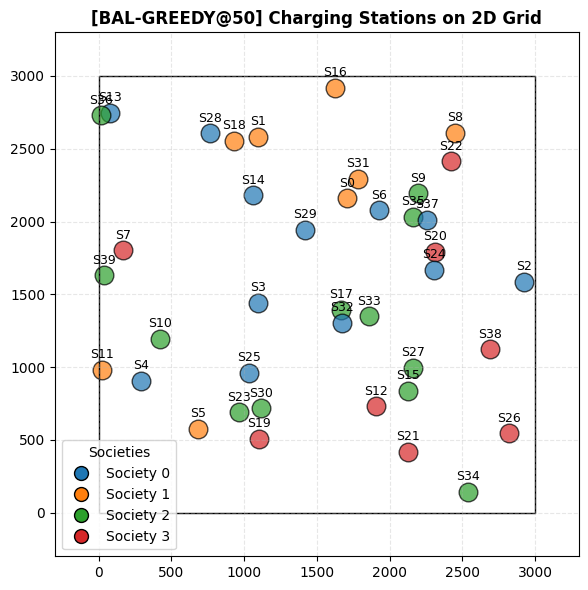

In [20]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=300)

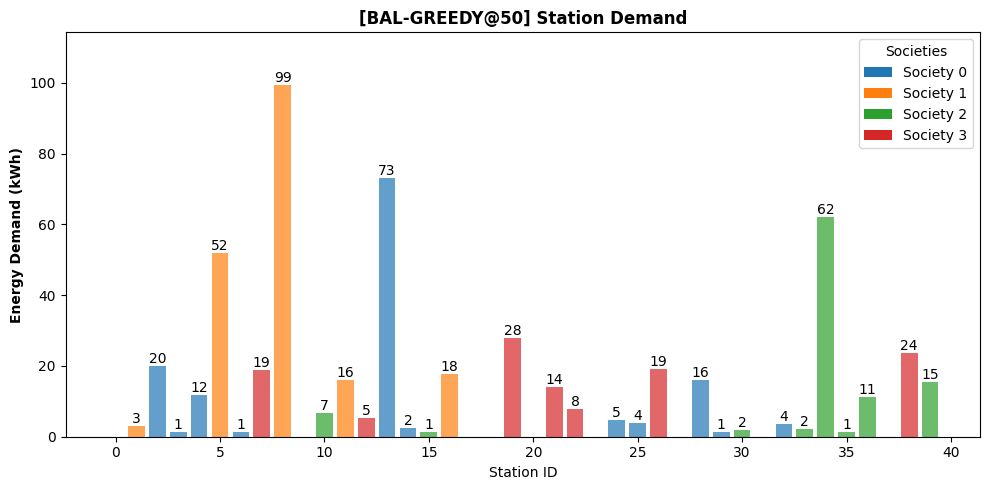

In [21]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

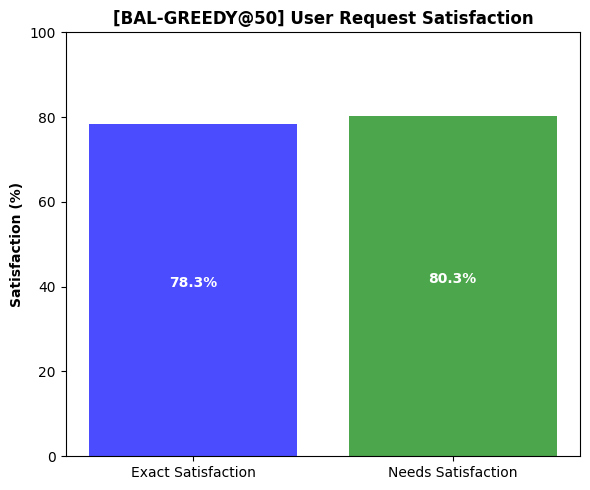

In [22]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

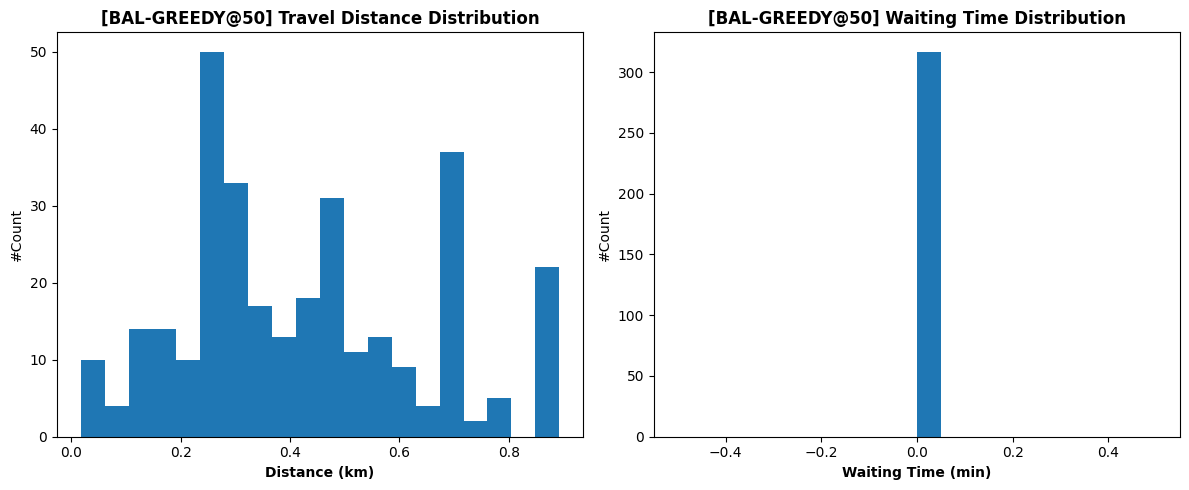

In [23]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

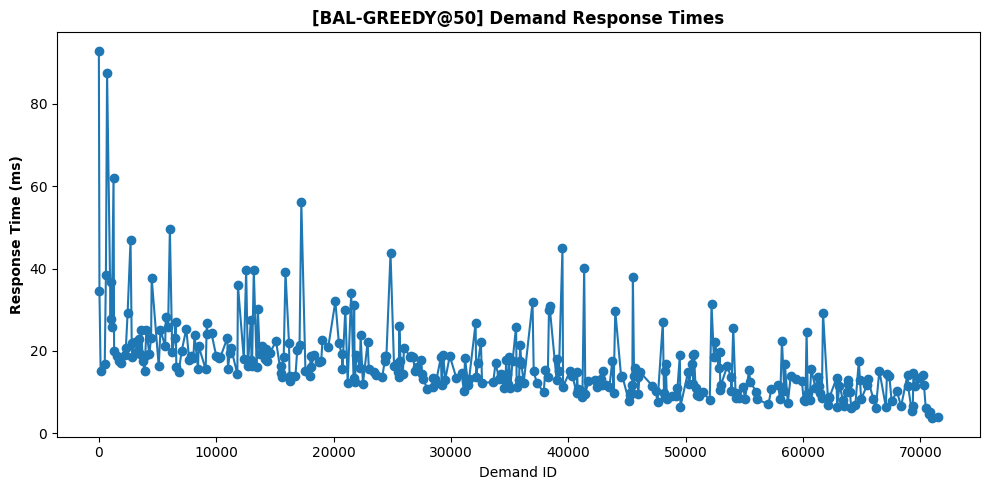

In [24]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

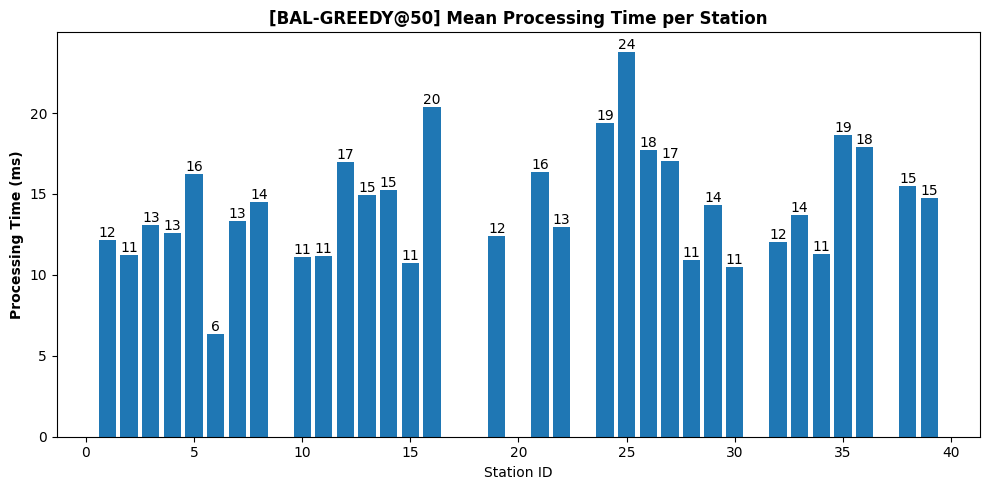

In [25]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [26]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           2  0.220139  0.065278  0.000000  0.000000       NaN   
1            0           3  0.013194  0.000000  0.000000  0.000000       NaN   
2            0           4  0.135417  0.034028  0.000000  0.000000       NaN   
3            0           6  0.014583  0.000000  0.000000  0.000000       NaN   
4            0          13  0.500000  0.323611  0.029167  0.052778  0.124306   
5            0          14  0.040278  0.000000  0.000000  0.000000  0.000000   
6            0          24  0.099306  0.000000  0.000000  0.000000  0.000000   
7            0          25  0.065972  0.000000  0.000000  0.000000  0.000000   
8            0          28  0.184722  0.065278  0.000000  0.000000       NaN   
9            0          29  0.013889  0.000000  0.000000  0.000000       NaN   
10           0          32  0.050000  0.000000  0.000000  0.000000  0.000000   
11           0          37  0.000000  0.

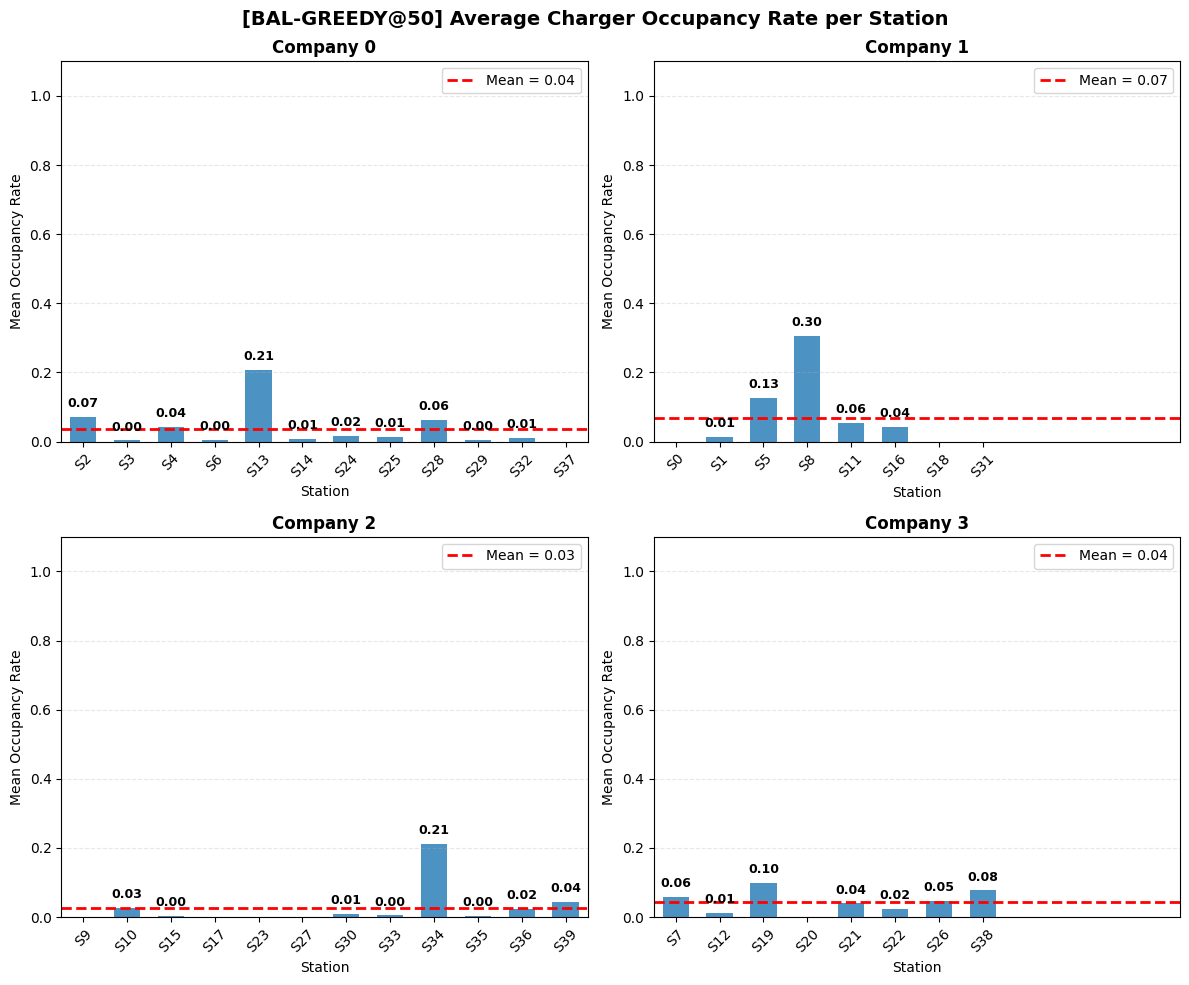

In [27]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

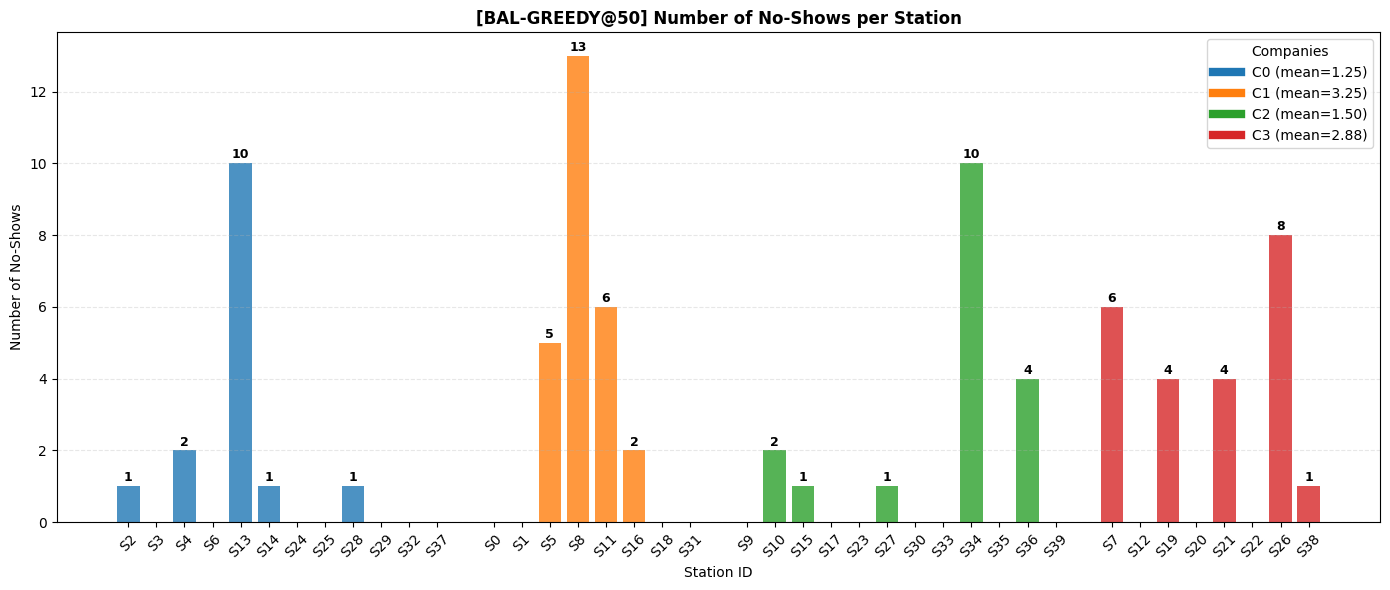

In [28]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [29]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,2,14,13,1,0,0,0.928571,0.071429,0.0,0.0
1,0,3,1,1,0,0,0,1.000000,0.000000,0.0,0.0
2,0,4,10,8,2,0,0,0.800000,0.200000,0.0,0.0
3,0,6,1,1,0,0,0,1.000000,0.000000,0.0,0.0
4,0,13,51,40,10,0,0,0.784314,0.196078,0.0,0.0
5,0,14,3,2,1,0,0,0.666667,0.333333,0.0,0.0
6,0,24,3,3,0,0,0,1.000000,0.000000,0.0,0.0
7,0,25,2,2,0,0,0,1.000000,0.000000,0.0,0.0
8,0,28,10,9,1,0,0,0.900000,0.100000,0.0,0.0
9,0,29,1,1,0,0,0,1.000000,0.000000,0.0,0.0


#### **BRAM-EV**

##### *Params*

In [30]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [31]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [32]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:31:19.405 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 23:31:20.302 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 23:31:20.848 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 23:31:22.057 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 23:31:22.399 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 23:31:22.608 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 23:31:22.767 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 23:31:23.150 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 23:31:23.843 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 23:31:24.297 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 23:31:24.872 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [33]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 1.23 kWh
  Station 1: 28.70 kWh
  Station 2: 0.00 kWh
  Station 3: 1.38 kWh
  Station 4: 3.79 kWh
  Station 5: 1.38 kWh
  Station 6: 0.00 kWh
  Station 7: 9.95 kWh
  Station 8: 73.53 kWh
  Station 9: 2.04 kWh
  Station 10: 0.00 kWh
  Station 11: 0.00 kWh
  Station 12: 10.52 kWh
  Station 13: 33.95 kWh
  Station 14: 11.76 kWh
  Station 15: 23.60 kWh
  Station 16: 1.47 kWh
  Station 17: 4.08 kWh
  Station 18: 17.72 kWh
  Station 19: 16.01 kWh
  Station 20: 13.50 kWh
  Station 21: 5.56 kWh
  Station 22: 14.87 kWh
  Station 23: 26.87 kWh
  Station 24: 1.47 kWh
  Station 25: 6.58 kWh
  Station 26: 46.83 kWh
  Station 27: 63.57 kWh
  Station 28: 4.27 kWh
  Station 29: 5.38 kWh
  Station 30: 4.26 kWh
  Station 31: 4.96 kWh
  Station 32: 0.00 kWh
  Station 33: 9.40 kWh
  Station 34: 0.00 kWh
  Station 35: 2.67 kWh
  Station 36: 2.73 kWh
  Station 37: 1.50 kWh
  Station 38: 72.59 kWh
  Station 39: 2.47 kWh

--- User Req

In [34]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

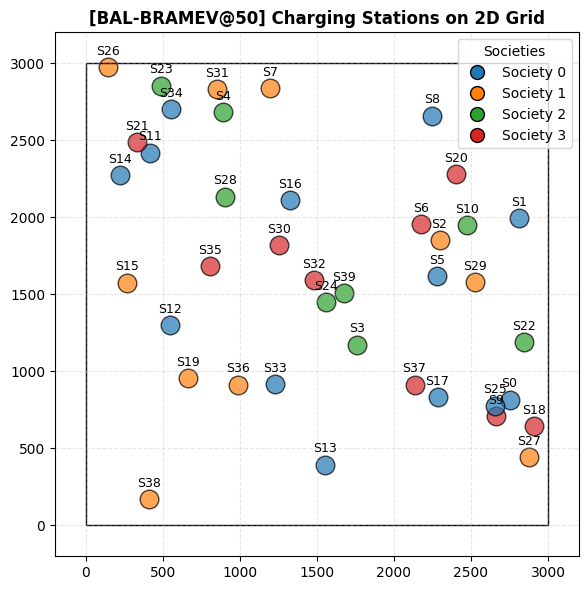

In [35]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

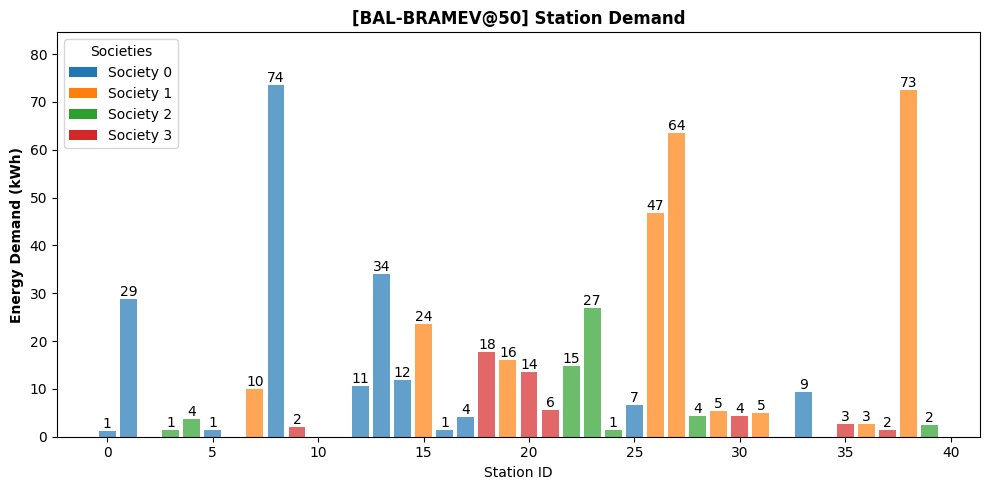

In [36]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

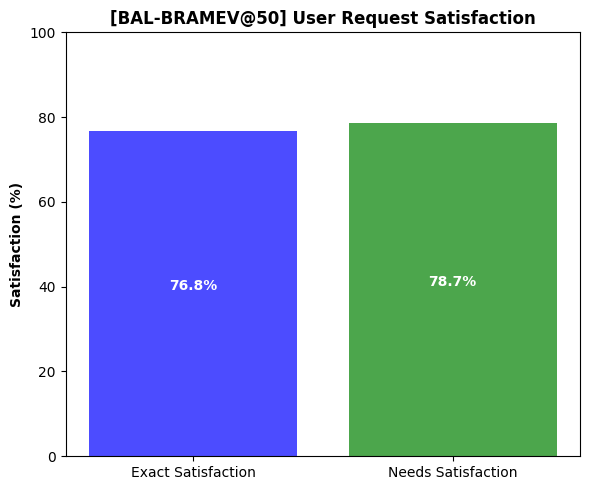

In [37]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

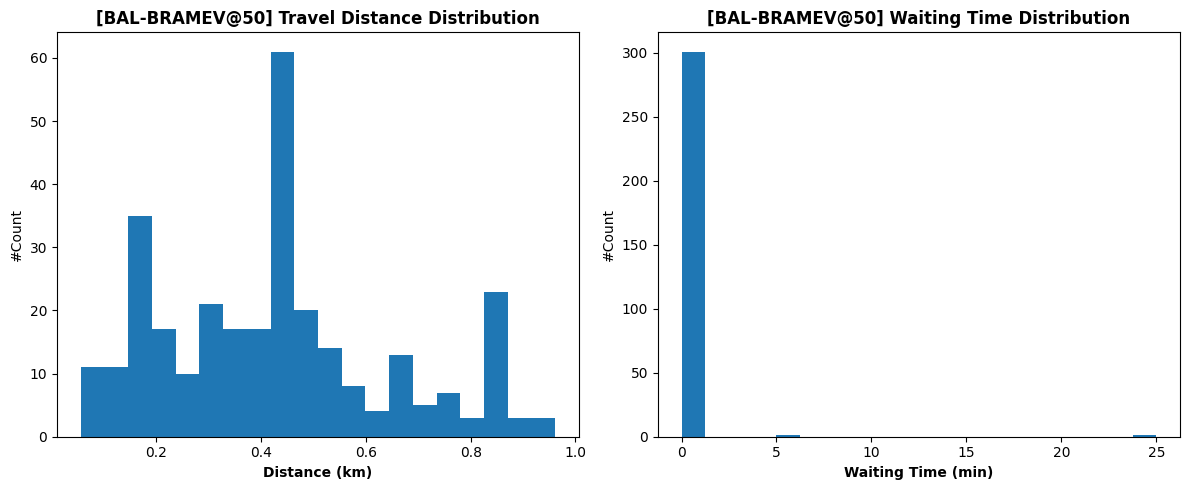

In [38]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

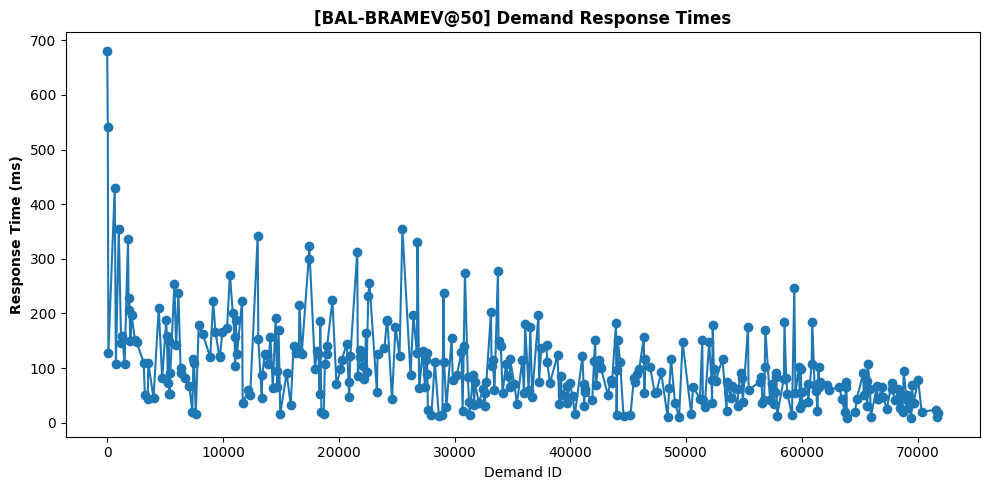

In [39]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

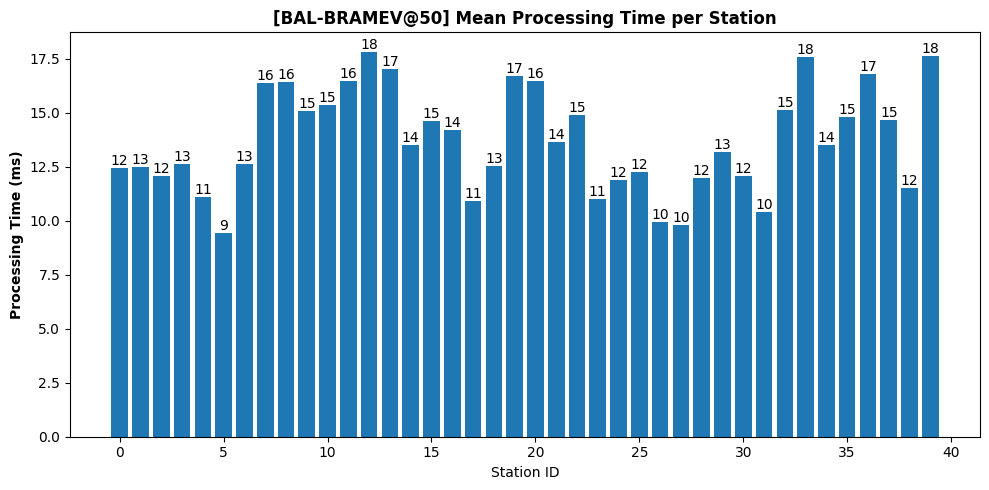

In [40]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

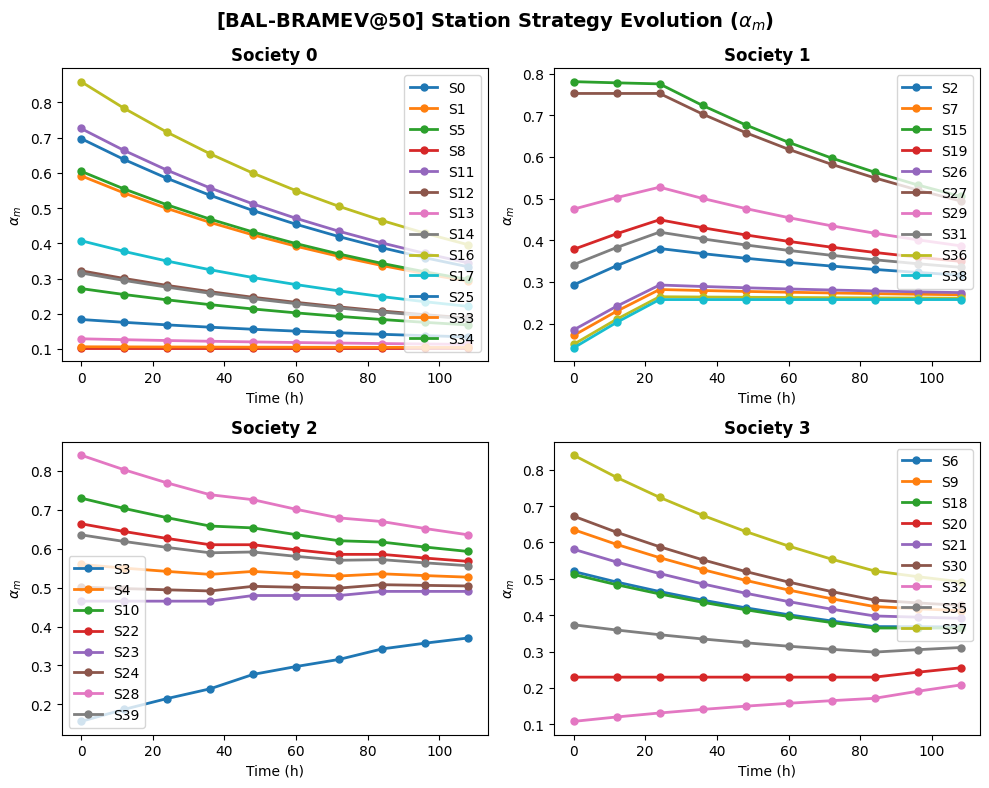

In [41]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [42]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           0  0.031944  0.000000  0.000000  0.000000  0.000000   
1            0           1  0.338194  0.040278  0.000000  0.000000  0.000000   
2            0           5  0.022917  0.000000  0.000000  0.000000       NaN   
3            0           8  0.518750  0.285417  0.040972  0.034722  0.029861   
4            0          11  0.000000  0.000000  0.000000  0.000000  0.000000   
5            0          12  0.130556  0.018750  0.000000  0.000000  0.000000   
6            0          13  0.240278  0.209722  0.000000  0.000000  0.000000   
7            0          14  0.193750  0.000000  0.000000  0.000000  0.000000   
8            0          16  0.015278  0.000000  0.000000  0.000000  0.000000   
9            0          17  0.071528  0.000000  0.000000  0.000000       NaN   
10           0          25  0.097222  0.000000  0.000000  0.000000  0.000000   
11           0          33  0.106944  0.

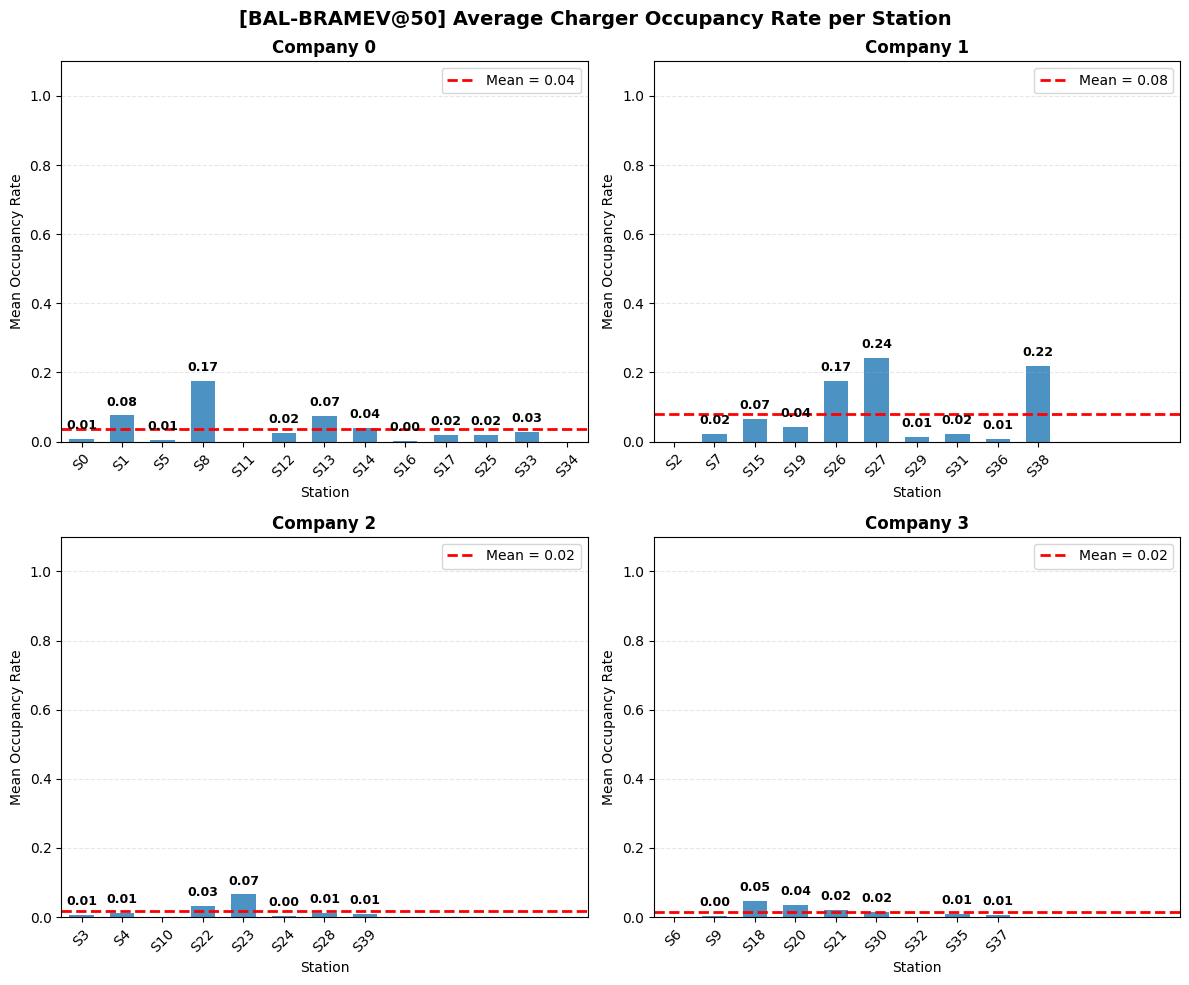

In [43]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

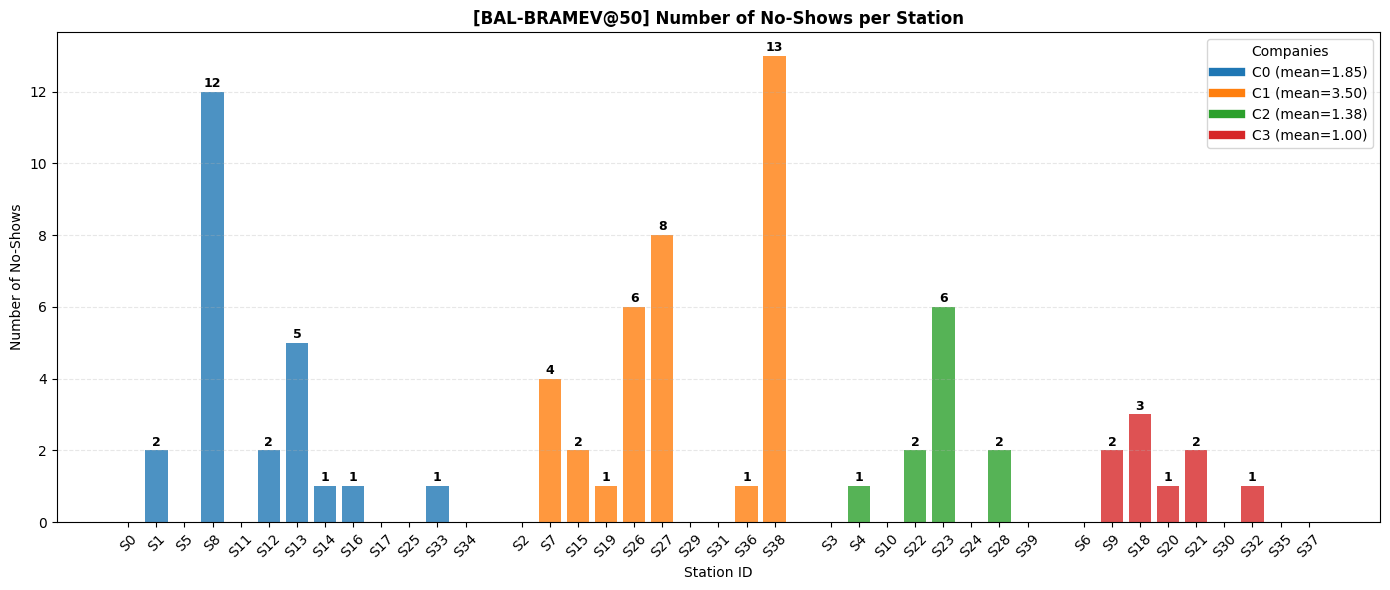

In [44]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [45]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,0,2,1,0,0,0,0.500000,0.000000,0.0,0.0
1,0,1,17,15,2,0,0,0.882353,0.117647,0.0,0.0
2,0,5,1,1,0,0,0,1.000000,0.000000,0.0,0.0
3,0,8,50,38,12,0,0,0.760000,0.240000,0.0,0.0
4,0,11,0,0,0,0,0,NaN,NaN,NaN,NaN
5,0,12,7,5,2,0,0,0.714286,0.285714,0.0,0.0
6,0,13,24,19,5,0,0,0.791667,0.208333,0.0,0.0
7,0,14,8,7,1,0,0,0.875000,0.125000,0.0,0.0
8,0,16,2,1,1,0,0,0.500000,0.500000,0.0,0.0
9,0,17,2,2,0,0,0,1.000000,0.000000,0.0,0.0


#### **COMPARISON**

##### *Params*

In [46]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

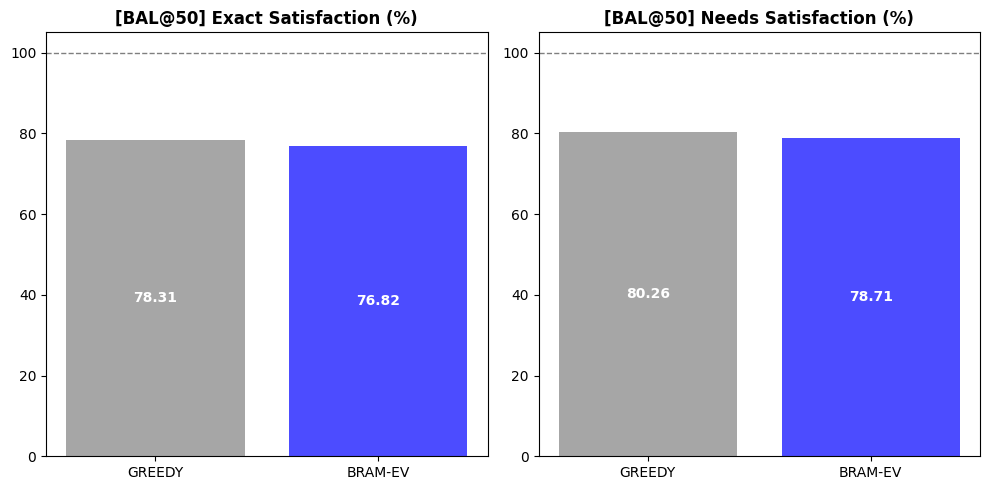

In [47]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

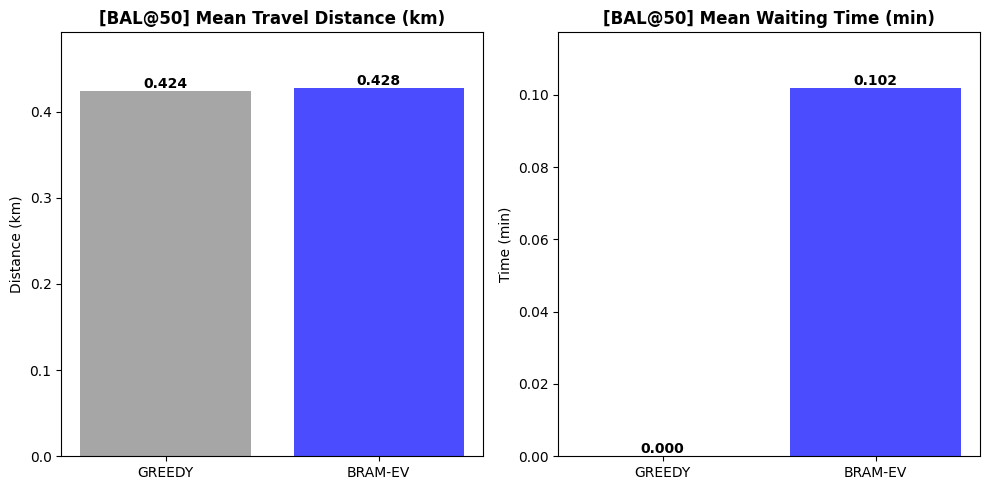

In [48]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

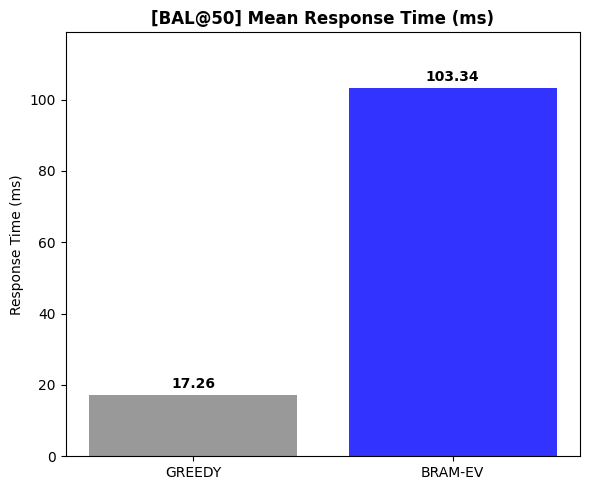

In [49]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@100cars**

#### **CONFIG**

In [50]:
nb_car = 100
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [51]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [52]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [53]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:31:56.614 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-13 23:31:56.668 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-13 23:31:56.790 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-13 23:31:56.903 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-13 23:31:57.083 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-13 23:31:57.181 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-13 23:31:57.370 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-13 23:31:57.530 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-13 23:31:57.632 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-13 23:31:57.775 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-13 23:31:58.020 | IN

##### *Metrics*

In [54]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 23.98 kWh
  Station 1: 26.90 kWh
  Station 2: 3.92 kWh
  Station 3: 3.27 kWh
  Station 4: 14.99 kWh
  Station 5: 1.75 kWh
  Station 6: 5.10 kWh
  Station 7: 2.00 kWh
  Station 8: 57.51 kWh
  Station 9: 0.67 kWh
  Station 10: 5.87 kWh
  Station 11: 5.21 kWh
  Station 12: 9.68 kWh
  Station 13: 3.32 kWh
  Station 14: 57.70 kWh
  Station 15: 6.92 kWh
  Station 16: 87.40 kWh
  Station 17: 21.70 kWh
  Station 18: 23.31 kWh
  Station 19: 4.55 kWh
  Station 20: 0.00 kWh
  Station 21: 37.11 kWh
  Station 22: 5.47 kWh
  Station 23: 172.28 kWh
  Station 24: 53.43 kWh
  Station 25: 1.71 kWh
  Station 26: 7.73 kWh
  Station 27: 46.91 kWh
  Station 28: 5.22 kWh
  Station 29: 12.51 kWh
  Station 30: 9.41 kWh
  Station 31: 5.70 kWh
  Station 32: 157.15 kWh
  Station 33: 1.87 kWh
  Station 34: 3.03 kWh
  Station 35: 3.92 kWh
  Station 36: 136.53 kWh
  Station 37: 23.12 kWh
  Station 38: 5.49 kWh
  Station 39: 5.18 kWh

--- Use

In [55]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

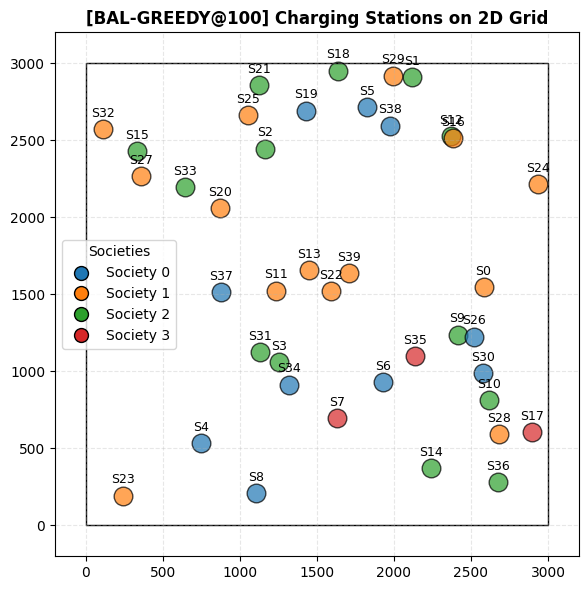

In [56]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

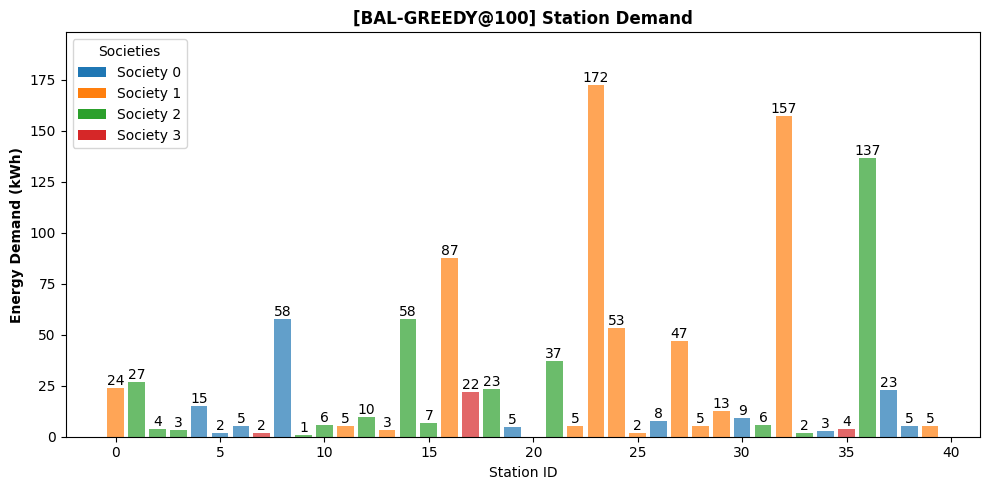

In [57]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

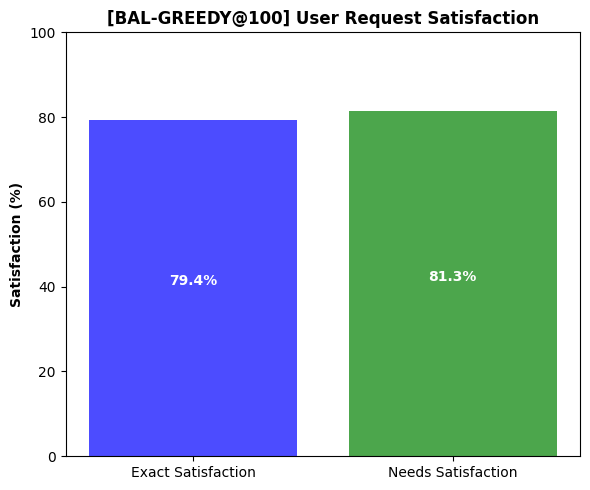

In [58]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

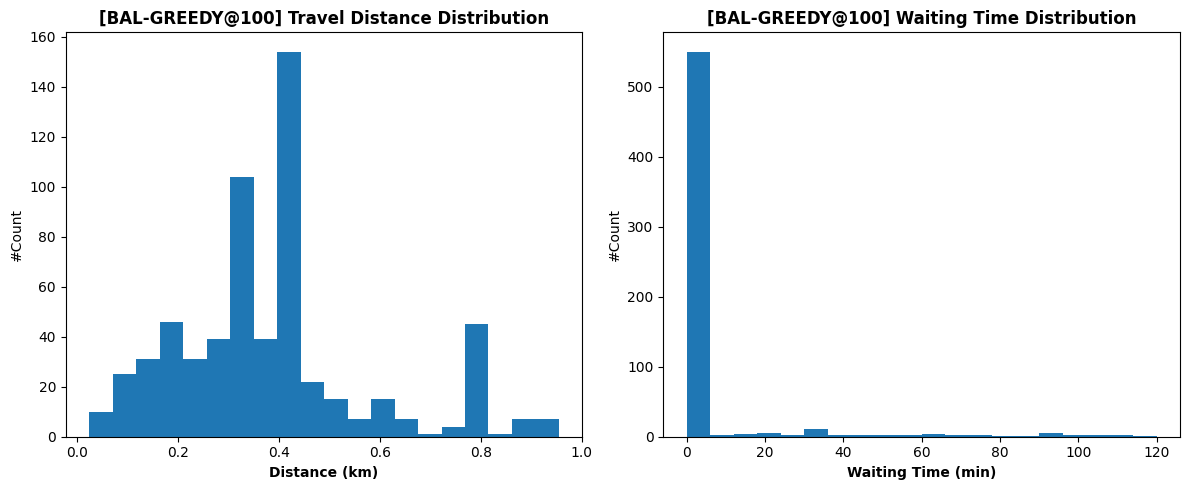

In [59]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

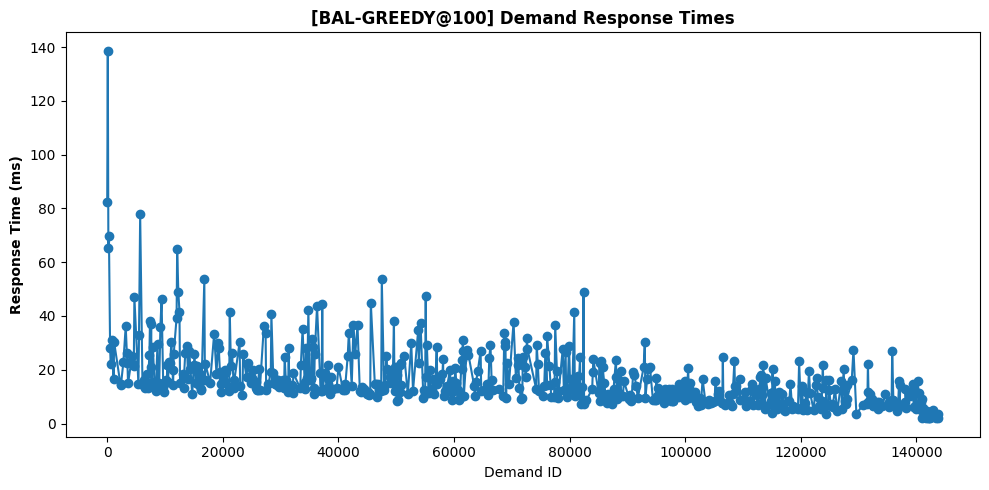

In [60]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

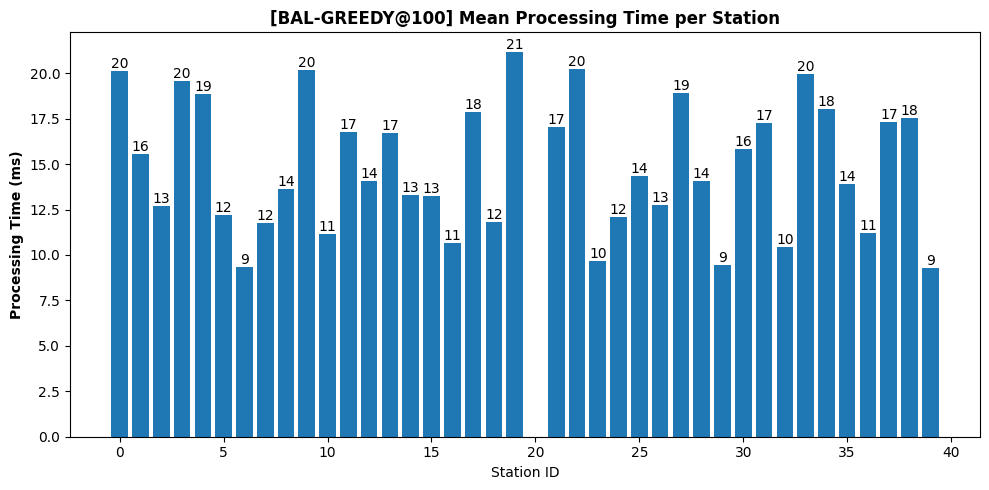

In [61]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [62]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           4  0.220833  0.013889  0.000000  0.000000  0.000000   
1            0           5  0.029167  0.000000  0.000000  0.000000  0.000000   
2            0           6  0.058333  0.000000  0.000000  0.000000  0.000000   
3            0           8  0.486806  0.239583  0.041667  0.000000  0.050000   
4            0          19  0.079167  0.000000  0.000000  0.000000  0.000000   
5            0          26  0.120833  0.000000  0.000000  0.000000       NaN   
6            0          30  0.144444  0.000000  0.000000  0.000000  0.000000   
7            0          34  0.057639  0.000000  0.000000  0.000000  0.000000   
8            0          37  0.305556  0.124306  0.007639  0.000000  0.000000   
9            0          38  0.084028  0.000000  0.000000  0.000000  0.000000   
10           1           0  0.259028  0.071528  0.000000  0.000000  0.000000   
11           1          11  0.069444  0.

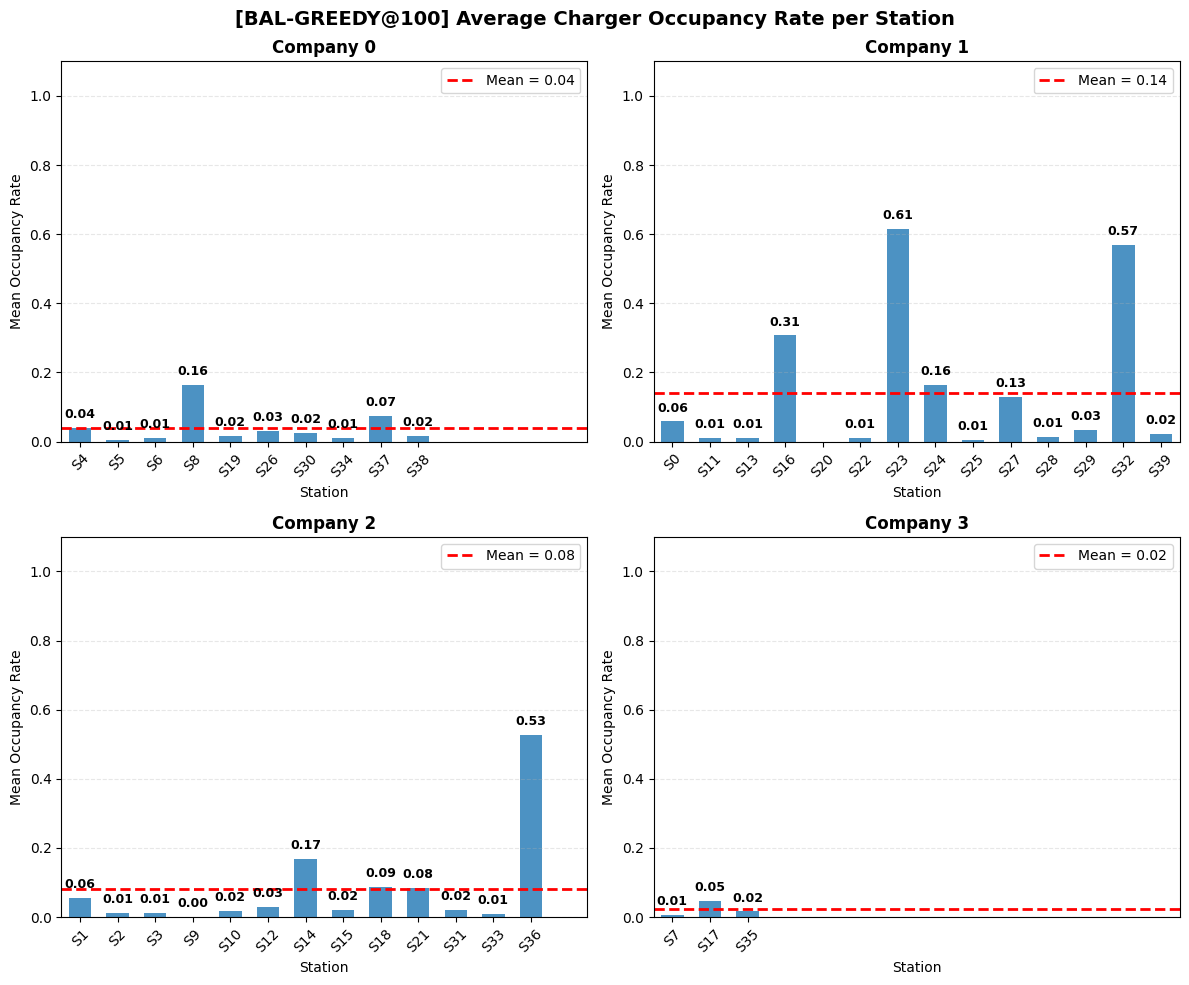

In [63]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

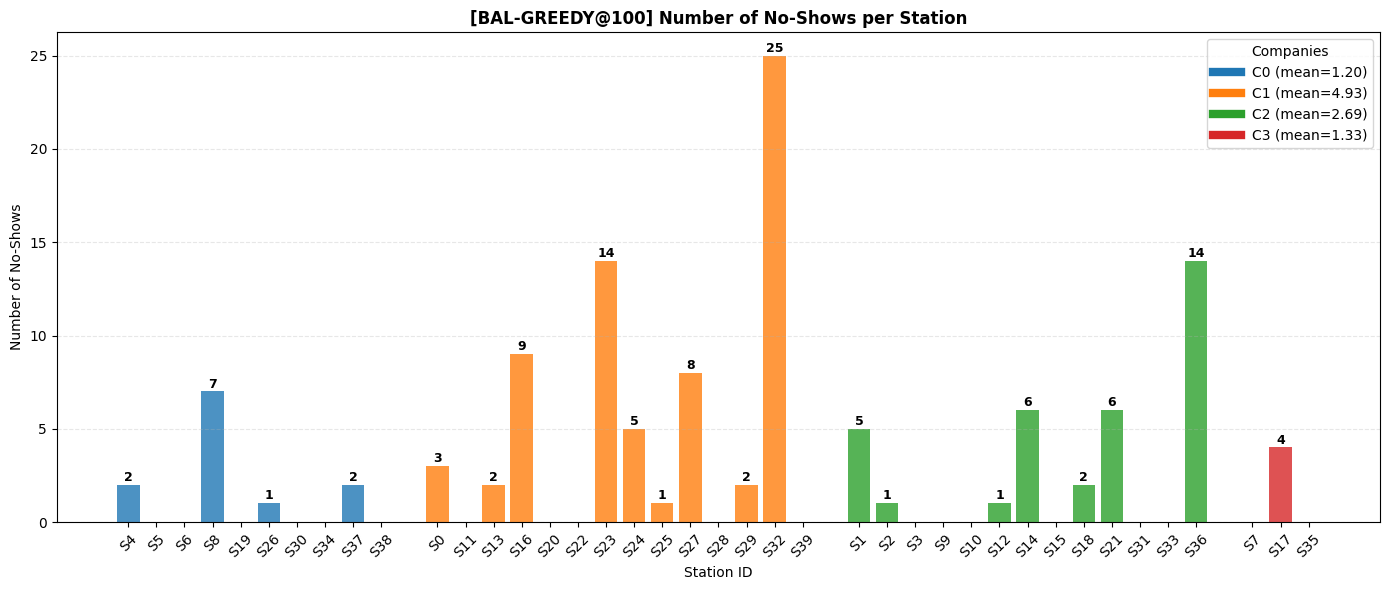

In [64]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [65]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,4,11,9,2,0,0,0.818182,0.181818,0.0,0.000000
1,0,5,1,1,0,0,0,1.000000,0.000000,0.0,0.000000
2,0,6,3,3,0,0,0,1.000000,0.000000,0.0,0.000000
3,0,8,40,32,7,0,0,0.800000,0.175000,0.0,0.000000
4,0,19,2,2,0,0,0,1.000000,0.000000,0.0,0.000000
5,0,26,5,4,1,0,0,0.800000,0.200000,0.0,0.000000
6,0,30,5,5,0,0,0,1.000000,0.000000,0.0,0.000000
7,0,34,2,2,0,0,0,1.000000,0.000000,0.0,0.000000
8,0,37,17,14,2,0,0,0.823529,0.117647,0.0,0.000000
9,0,38,3,3,0,0,0,1.000000,0.000000,0.0,0.000000


#### **BRAM-EV**

##### *Params*

In [66]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [67]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [68]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:32:10.780 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 23:32:11.099 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 23:32:11.699 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 23:32:12.622 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 23:32:13.343 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 23:32:14.135 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 23:32:15.502 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 23:32:16.232 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 23:32:17.028 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 23:32:17.796 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 23:32:18.838 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [69]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 1.50 kWh
  Station 1: 0.00 kWh
  Station 2: 1.87 kWh
  Station 3: 9.22 kWh
  Station 4: 16.37 kWh
  Station 5: 5.08 kWh
  Station 6: 5.43 kWh
  Station 7: 43.17 kWh
  Station 8: 18.97 kWh
  Station 9: 5.13 kWh
  Station 10: 13.61 kWh
  Station 11: 26.43 kWh
  Station 12: 39.58 kWh
  Station 13: 12.71 kWh
  Station 14: 132.38 kWh
  Station 15: 17.39 kWh
  Station 16: 99.92 kWh
  Station 17: 0.00 kWh
  Station 18: 0.00 kWh
  Station 19: 25.49 kWh
  Station 20: 45.79 kWh
  Station 21: 65.94 kWh
  Station 22: 21.18 kWh
  Station 23: 83.24 kWh
  Station 24: 8.08 kWh
  Station 25: 6.47 kWh
  Station 26: 128.86 kWh
  Station 27: 17.35 kWh
  Station 28: 9.47 kWh
  Station 29: 3.30 kWh
  Station 30: 2.83 kWh
  Station 31: 33.72 kWh
  Station 32: 5.17 kWh
  Station 33: 149.92 kWh
  Station 34: 26.23 kWh
  Station 35: 4.28 kWh
  Station 36: 1.46 kWh
  Station 37: 0.00 kWh
  Station 38: 4.28 kWh
  Station 39: 3.75 kWh

---

In [70]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

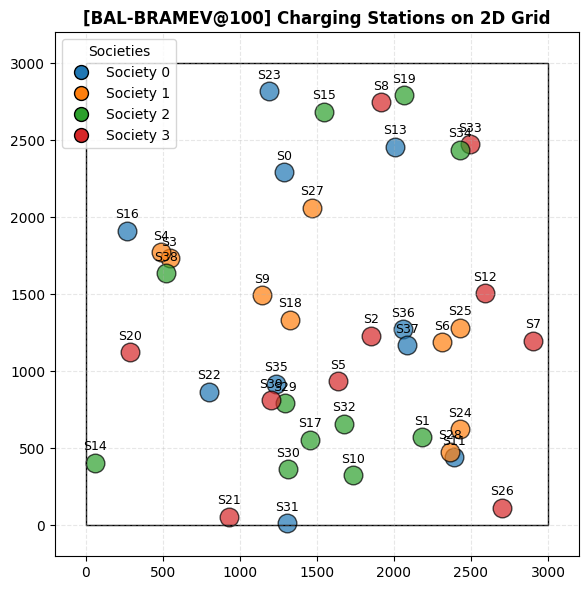

In [71]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

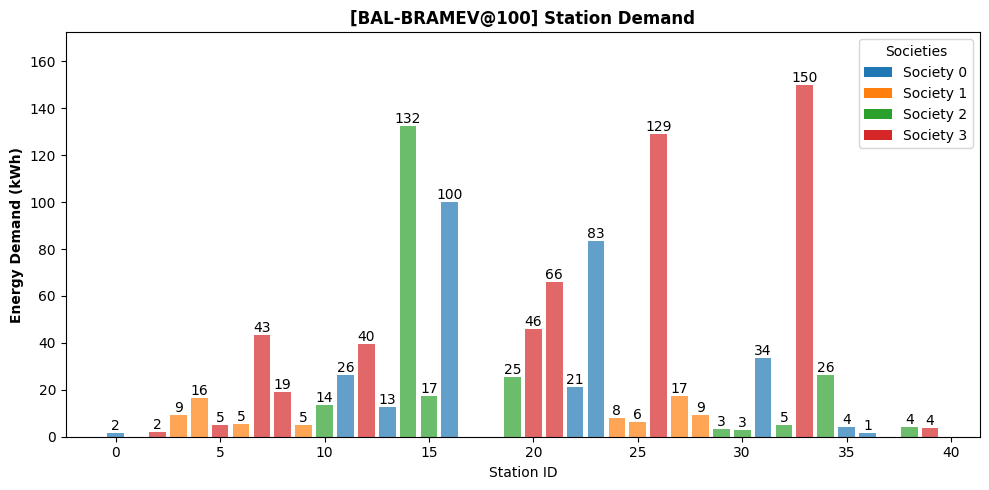

In [72]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

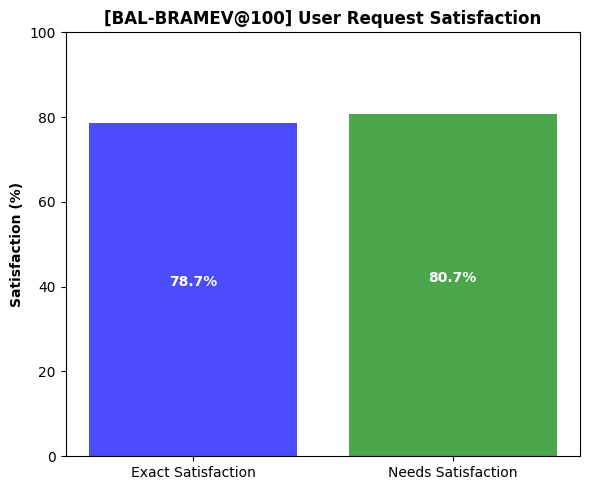

In [73]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

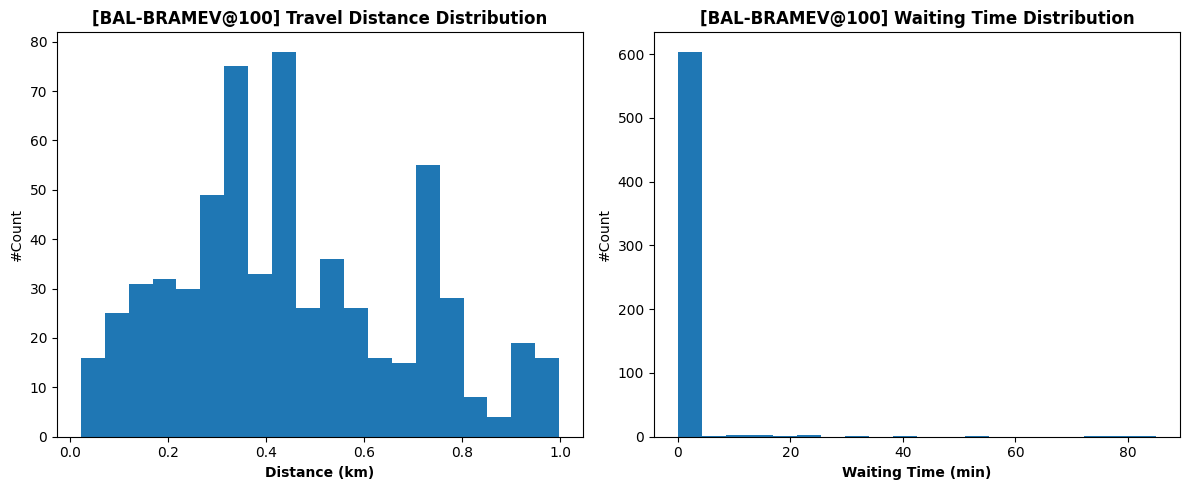

In [74]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

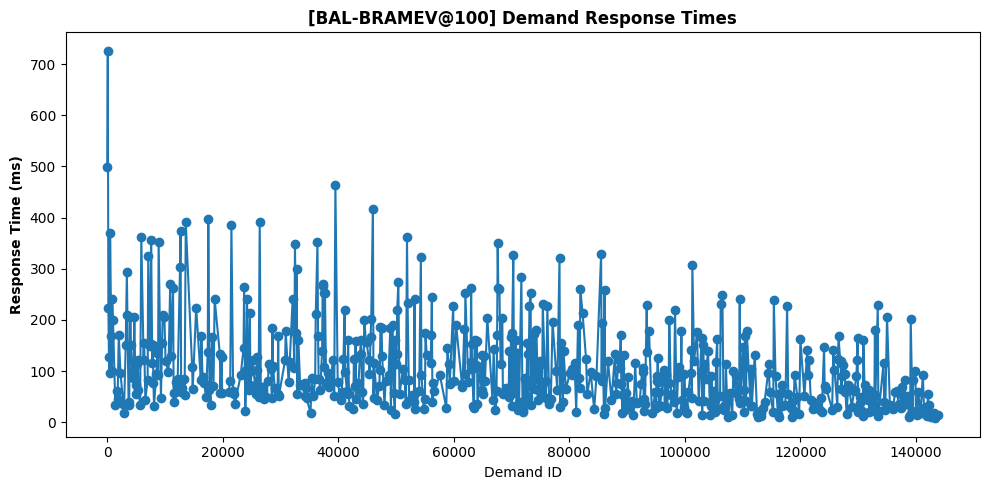

In [75]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

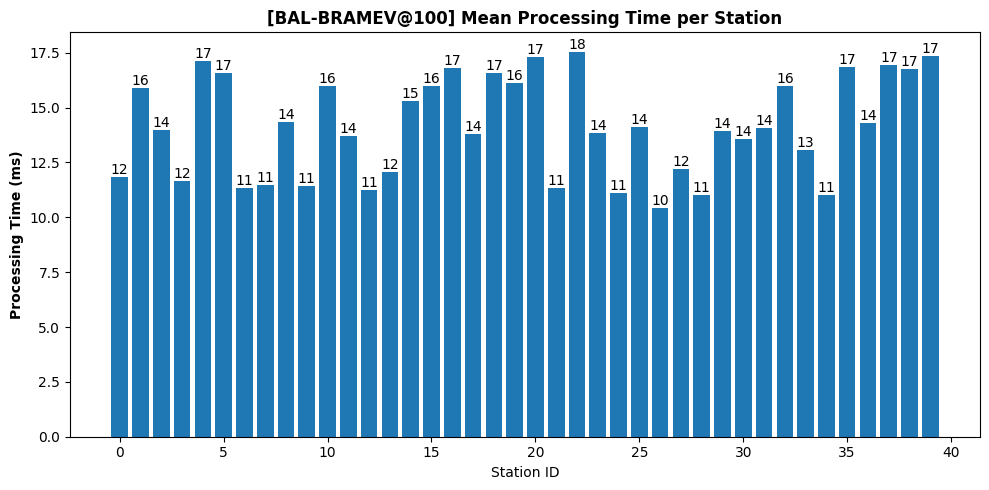

In [76]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

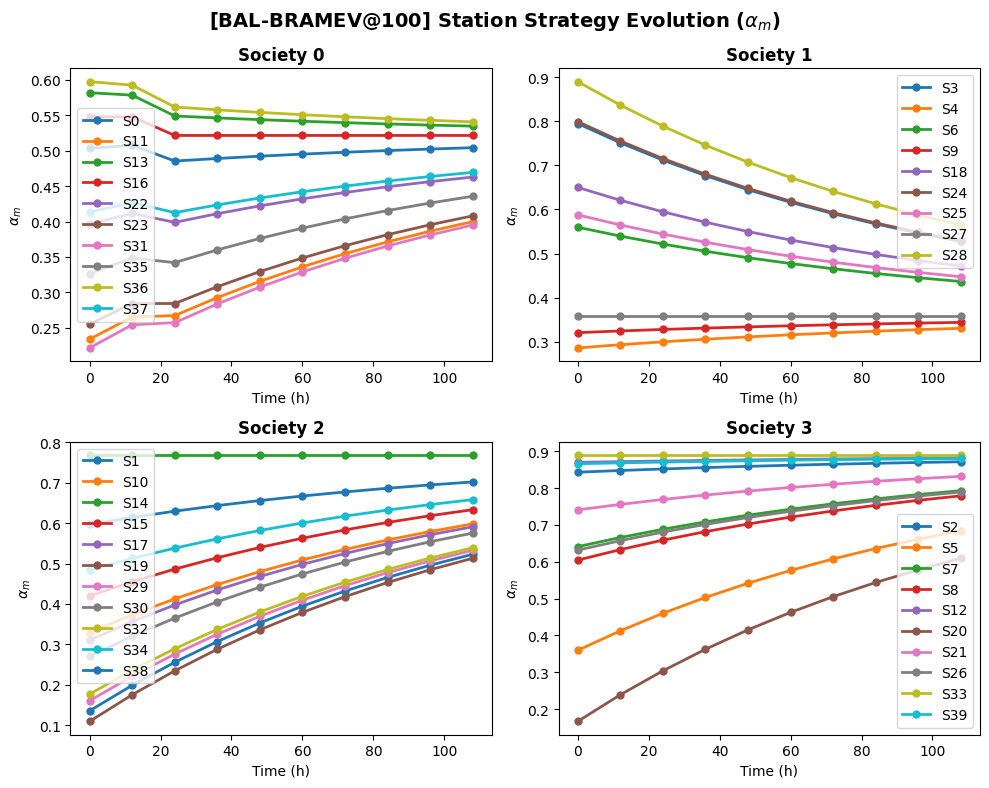

In [77]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [78]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           0  0.025000  0.000000  0.000000  0.000000       NaN   
1            0          11  0.142361  0.121528  0.000000  0.000000  0.049306   
2            0          13  0.161806  0.000000  0.000000  0.000000       NaN   
3            0          16  0.557639  0.341667  0.156944  0.062500  0.039583   
4            0          22  0.183333  0.079167  0.000000  0.000000  0.000000   
5            0          23  0.480556  0.465278  0.038889  0.040972  0.125694   
6            0          31  0.247222  0.111111  0.000000  0.000000  0.047222   
7            0          35  0.066667  0.000000  0.000000  0.000000  0.000000   
8            0          36  0.024306  0.000000  0.000000  0.000000  0.000000   
9            0          37  0.000000  0.000000  0.000000  0.000000  0.000000   
10           1           3  0.111806  0.000000  0.000000  0.000000       NaN   
11           1           4  0.154167  0.

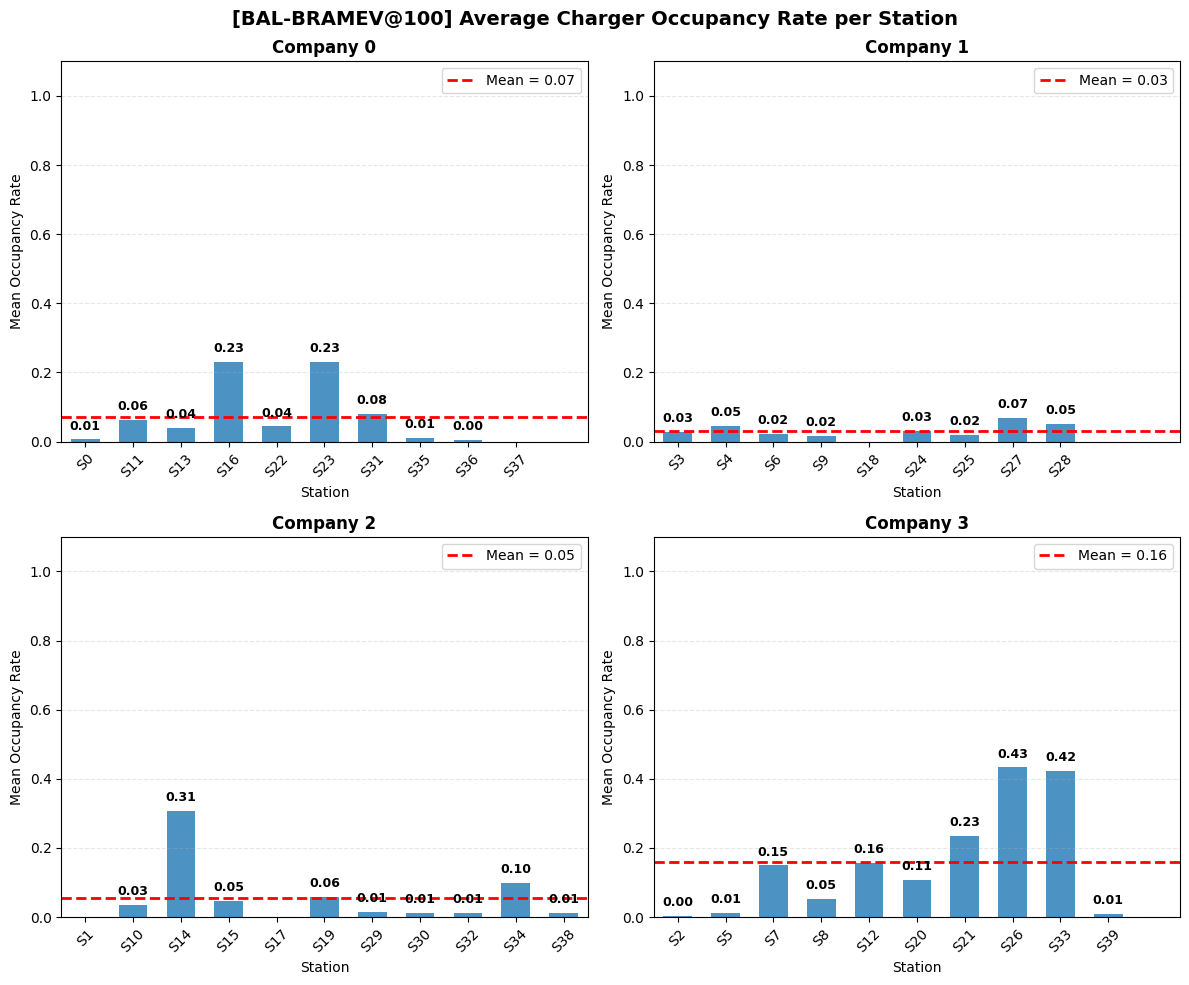

In [79]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

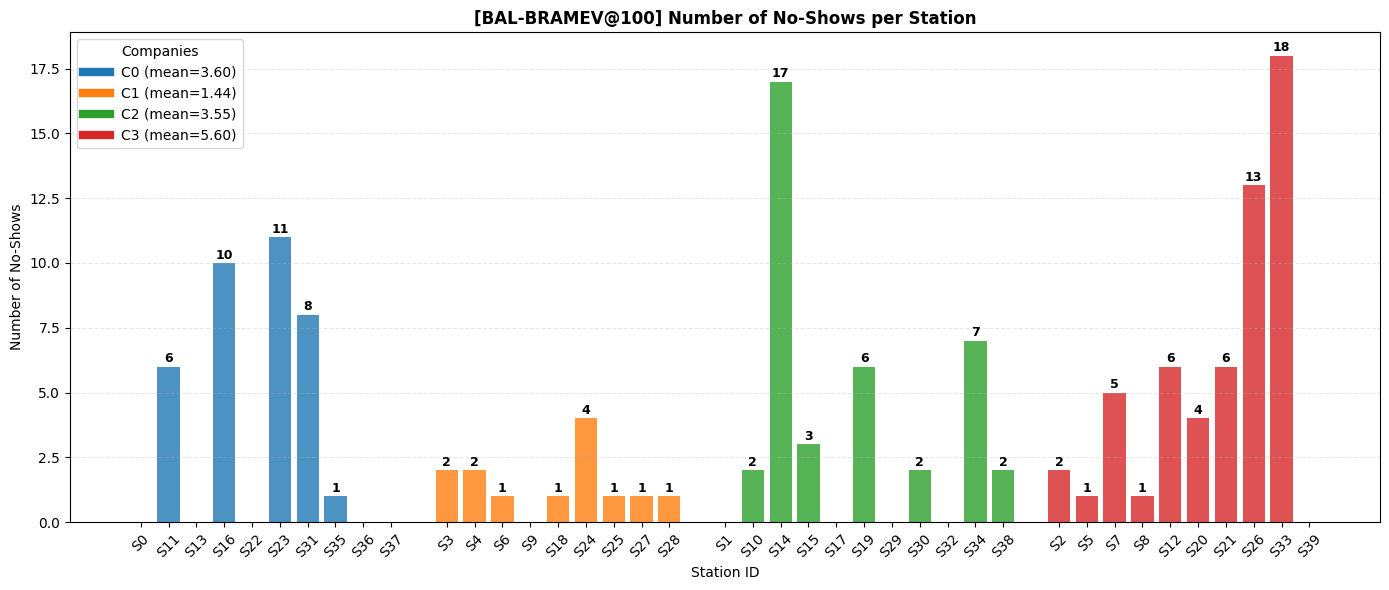

In [80]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [81]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,0,1,1,0,0,0,1.000000,0.000000,0.0,0.0
1,0,11,20,14,6,0,0,0.700000,0.300000,0.0,0.0
2,0,13,6,6,0,0,0,1.000000,0.000000,0.0,0.0
3,0,16,66,56,10,0,0,0.848485,0.151515,0.0,0.0
4,0,22,11,11,0,0,0,1.000000,0.000000,0.0,0.0
5,0,23,57,45,11,0,0,0.789474,0.192982,0.0,0.0
6,0,31,27,19,8,0,0,0.703704,0.296296,0.0,0.0
7,0,35,4,3,1,0,0,0.750000,0.250000,0.0,0.0
8,0,36,1,1,0,0,0,1.000000,0.000000,0.0,0.0
9,0,37,0,0,0,0,0,NaN,NaN,NaN,NaN


#### **COMPARISON**

##### *Params*

In [82]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

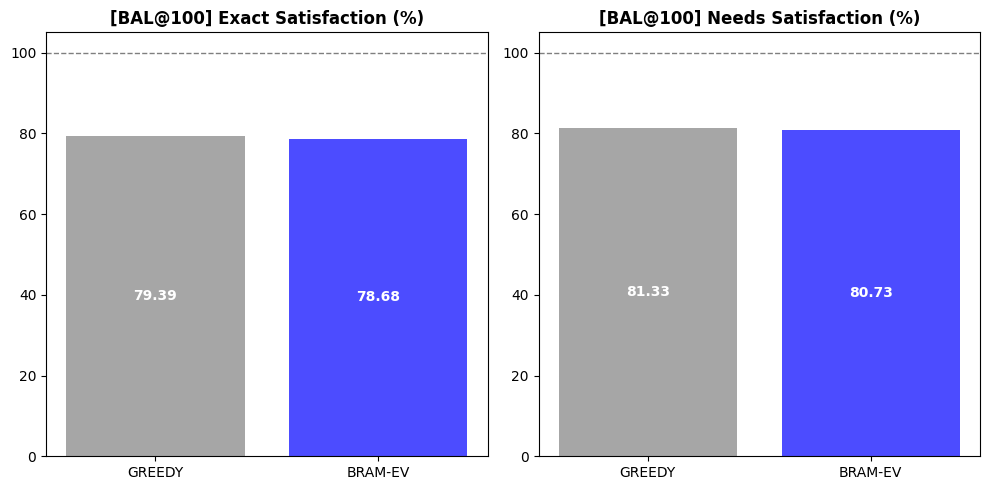

In [83]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

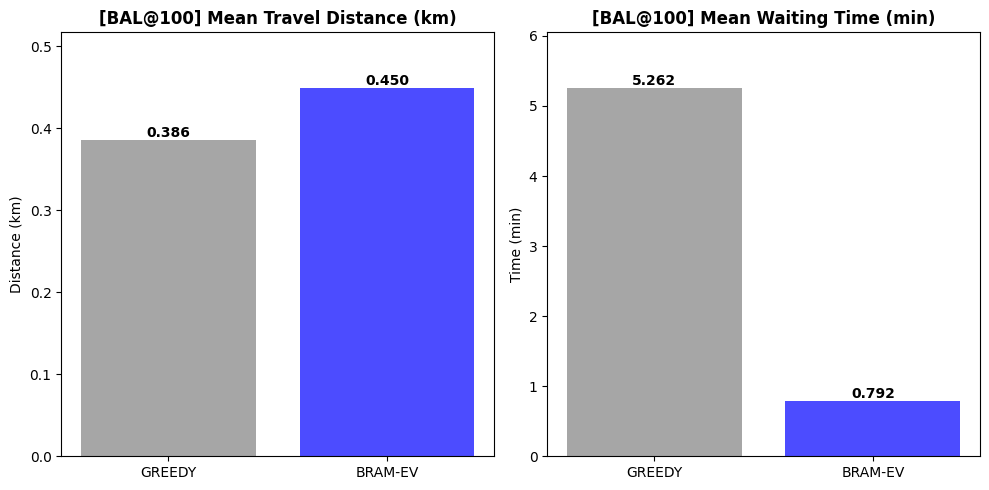

In [84]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

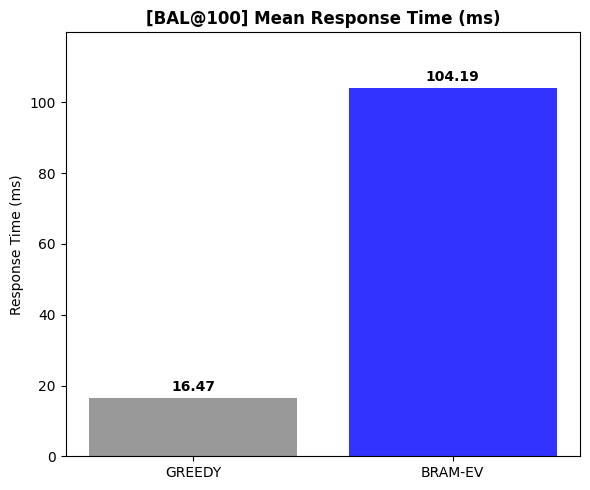

In [85]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@150cars**

#### **CONFIG**

In [86]:
nb_car = 150
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [87]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [88]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [89]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:33:20.093 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-13 23:33:20.290 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-13 23:33:20.519 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-13 23:33:20.834 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-13 23:33:21.194 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-13 23:33:21.368 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-13 23:33:21.652 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-13 23:33:21.804 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-13 23:33:21.976 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-13 23:33:22.343 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-13 23:33:22.640 | IN

##### *Metrics*

In [90]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 40.23 kWh
  Station 1: 4.68 kWh
  Station 2: 0.00 kWh
  Station 3: 16.74 kWh
  Station 4: 17.45 kWh
  Station 5: 74.21 kWh
  Station 6: 3.87 kWh
  Station 7: 11.48 kWh
  Station 8: 5.27 kWh
  Station 9: 196.68 kWh
  Station 10: 8.77 kWh
  Station 11: 39.12 kWh
  Station 12: 9.39 kWh
  Station 13: 4.08 kWh
  Station 14: 2.41 kWh
  Station 15: 42.37 kWh
  Station 16: 1.57 kWh
  Station 17: 3.62 kWh
  Station 18: 198.26 kWh
  Station 19: 8.00 kWh
  Station 20: 4.47 kWh
  Station 21: 14.86 kWh
  Station 22: 4.67 kWh
  Station 23: 1.54 kWh
  Station 24: 63.23 kWh
  Station 25: 9.79 kWh
  Station 26: 7.47 kWh
  Station 27: 6.68 kWh
  Station 28: 50.67 kWh
  Station 29: 0.00 kWh
  Station 30: 92.52 kWh
  Station 31: 8.97 kWh
  Station 32: 61.67 kWh
  Station 33: 61.73 kWh
  Station 34: 2.92 kWh
  Station 35: 190.78 kWh
  Station 36: 189.27 kWh
  Station 37: 40.02 kWh
  Station 38: 55.62 kWh
  Station 39: 2.42 kWh

---

In [91]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

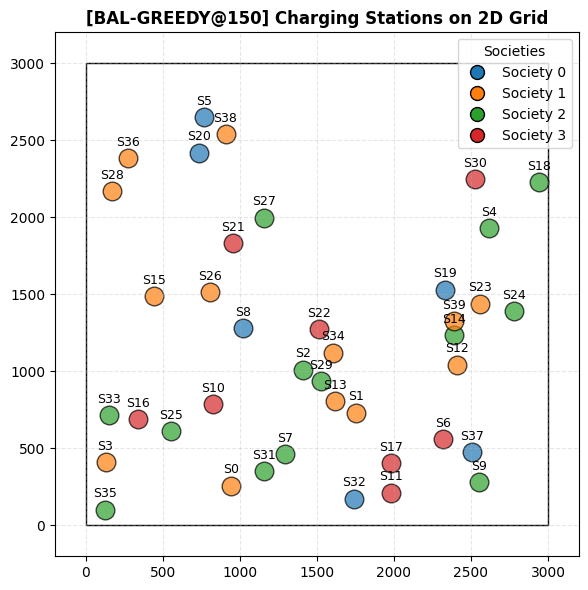

In [92]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

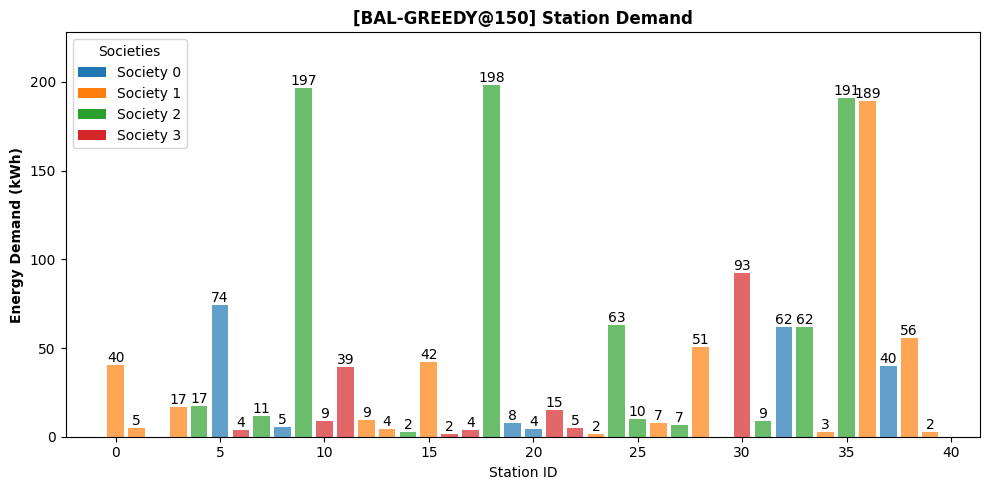

In [93]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

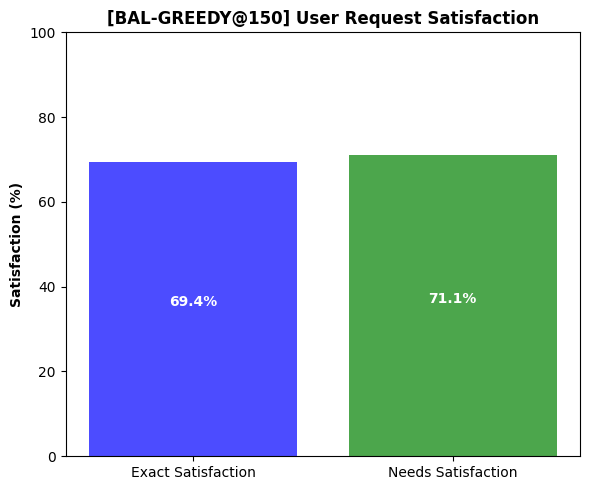

In [94]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

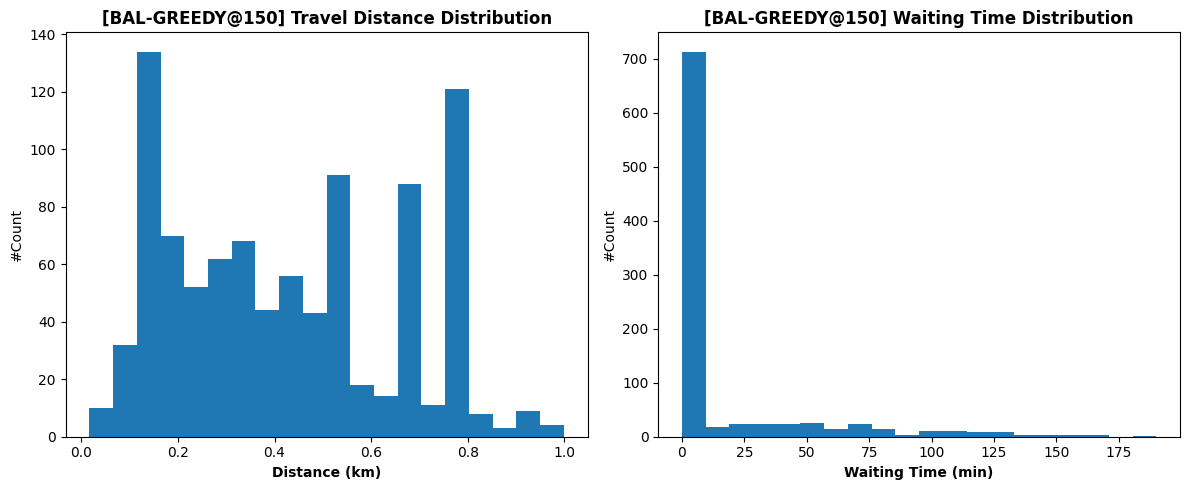

In [95]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

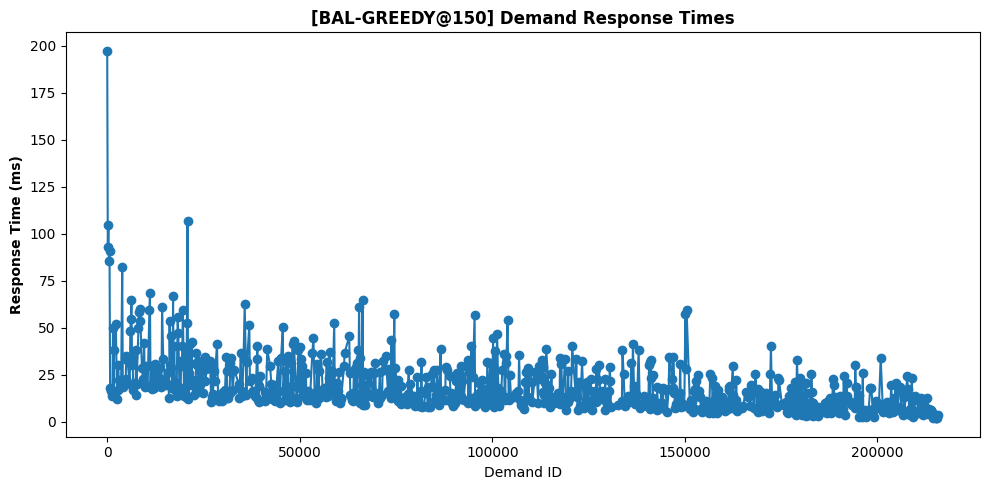

In [96]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

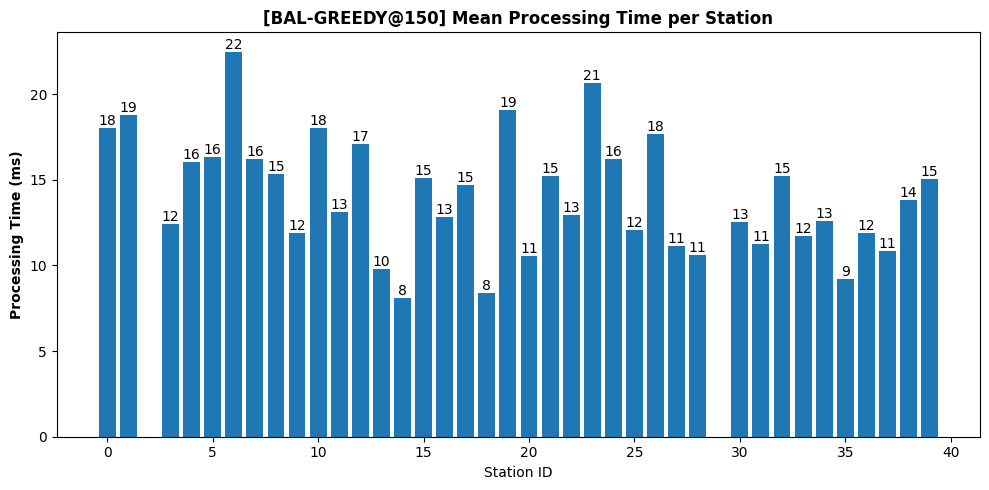

In [97]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [98]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           5  0.456944  0.281944  0.104167  0.034028  0.047917   
1            0           8  0.098611  0.000000  0.000000  0.000000       NaN   
2            0          19  0.110417  0.000000  0.000000  0.000000  0.000000   
3            0          20  0.060417  0.000000  0.000000  0.000000  0.000000   
4            0          32  0.475694  0.290972  0.027083  0.000000  0.094444   
5            0          37  0.294444  0.210417  0.027083  0.034028       NaN   
6            1           0  0.353472  0.149306  0.000000  0.000000  0.000000   
7            1           1  0.072222  0.000000  0.000000  0.000000  0.000000   
8            1           3  0.218750  0.052083  0.000000  0.000000       NaN   
9            1          12  0.103472  0.027083  0.000000  0.000000  0.000000   
10           1          13  0.048611  0.000000  0.000000  0.000000       NaN   
11           1          15  0.284028  0.

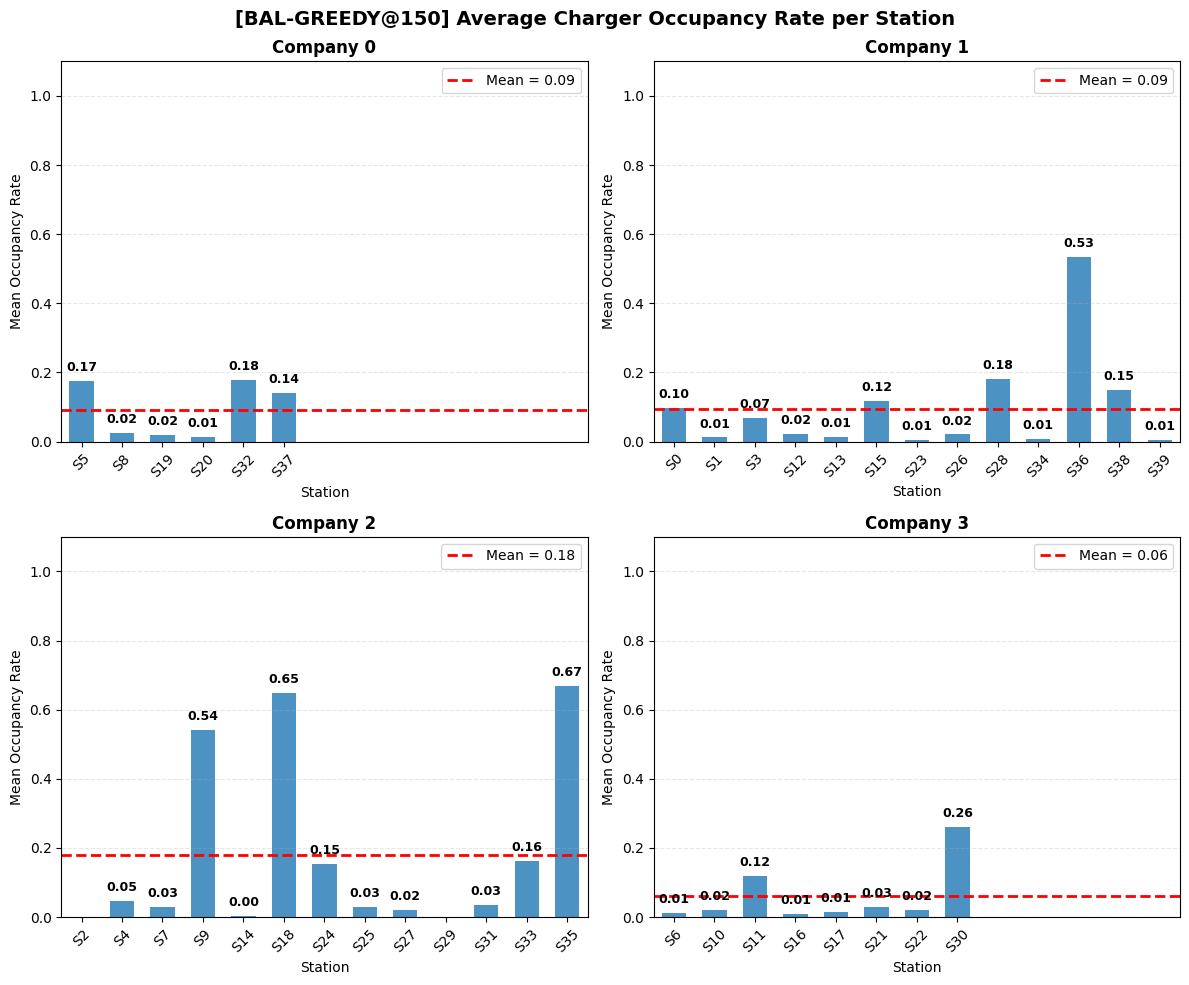

In [99]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

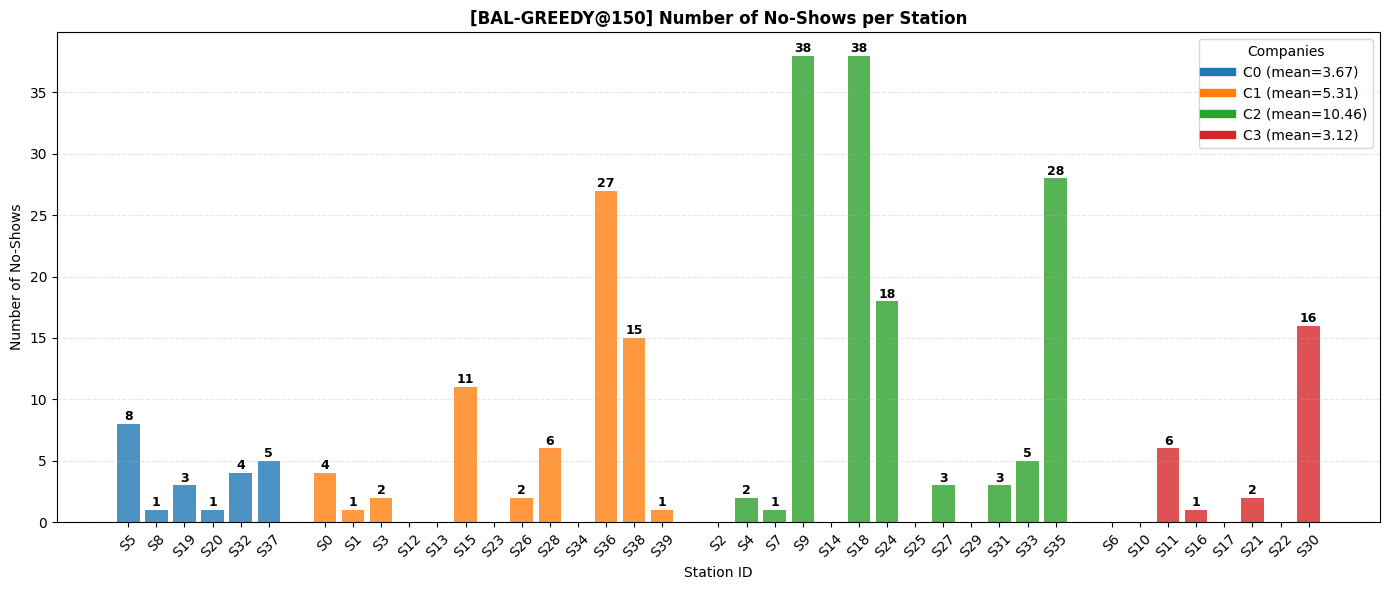

In [100]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [101]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,5,50,41,8,0,0,0.820000,0.160000,0.000000,0.000000
1,0,8,4,3,1,0,0,0.750000,0.250000,0.000000,0.000000
2,0,19,7,4,3,0,0,0.571429,0.428571,0.000000,0.000000
3,0,20,4,2,1,0,0,0.500000,0.250000,0.000000,0.000000
4,0,32,39,34,4,0,0,0.871795,0.102564,0.000000,0.000000
5,0,37,27,22,5,0,0,0.814815,0.185185,0.000000,0.000000
6,1,0,26,22,4,0,0,0.846154,0.153846,0.000000,0.000000
7,1,1,4,3,1,0,0,0.750000,0.250000,0.000000,0.000000
8,1,3,14,11,2,0,0,0.785714,0.142857,0.000000,0.000000
9,1,12,5,5,0,0,0,1.000000,0.000000,0.000000,0.000000


#### **BRAM-EV**

##### *Params*

In [102]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [103]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [104]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:33:43.379 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 23:33:44.383 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 23:33:46.644 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 23:33:48.058 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 23:33:50.004 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 23:33:51.603 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 23:33:53.237 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 23:33:55.081 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 23:33:56.151 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 23:33:57.684 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 23:33:58.809 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [105]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 41.47 kWh
  Station 1: 30.60 kWh
  Station 2: 3.37 kWh
  Station 3: 45.73 kWh
  Station 4: 9.33 kWh
  Station 5: 5.53 kWh
  Station 6: 38.52 kWh
  Station 7: 29.77 kWh
  Station 8: 65.13 kWh
  Station 9: 102.91 kWh
  Station 10: 1.55 kWh
  Station 11: 23.06 kWh
  Station 12: 20.15 kWh
  Station 13: 10.03 kWh
  Station 14: 7.88 kWh
  Station 15: 89.99 kWh
  Station 16: 11.60 kWh
  Station 17: 48.17 kWh
  Station 18: 51.84 kWh
  Station 19: 148.66 kWh
  Station 20: 31.59 kWh
  Station 21: 8.89 kWh
  Station 22: 5.76 kWh
  Station 23: 12.62 kWh
  Station 24: 18.39 kWh
  Station 25: 3.41 kWh
  Station 26: 29.03 kWh
  Station 27: 5.77 kWh
  Station 28: 7.29 kWh
  Station 29: 51.36 kWh
  Station 30: 37.86 kWh
  Station 31: 170.27 kWh
  Station 32: 13.57 kWh
  Station 33: 17.75 kWh
  Station 34: 5.83 kWh
  Station 35: 62.48 kWh
  Station 36: 161.88 kWh
  Station 37: 0.00 kWh
  Station 38: 100.11 kWh
  Station 39: 86.0

In [106]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

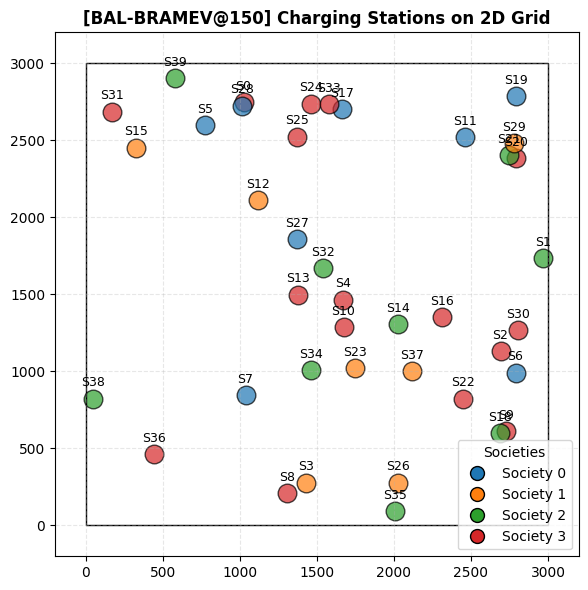

In [107]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

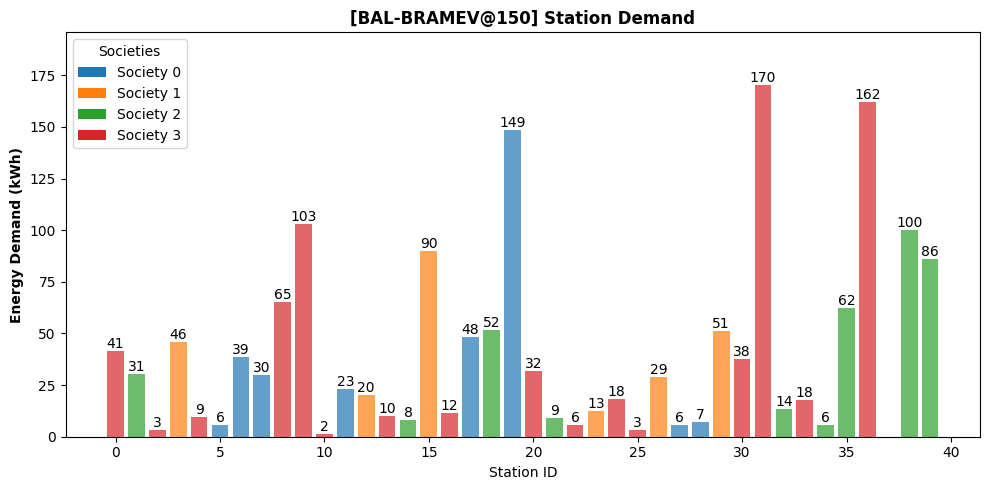

In [108]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

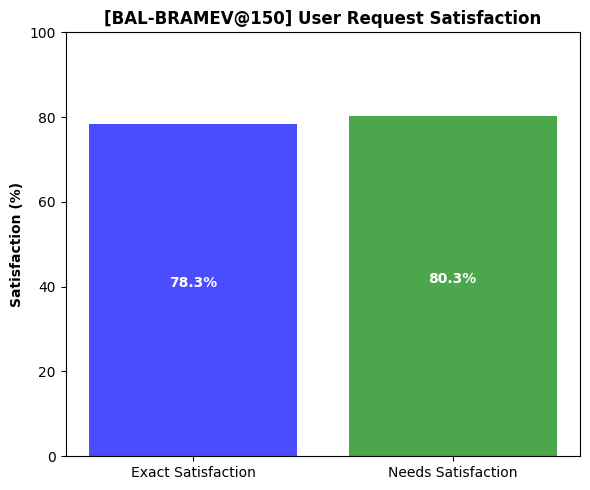

In [109]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

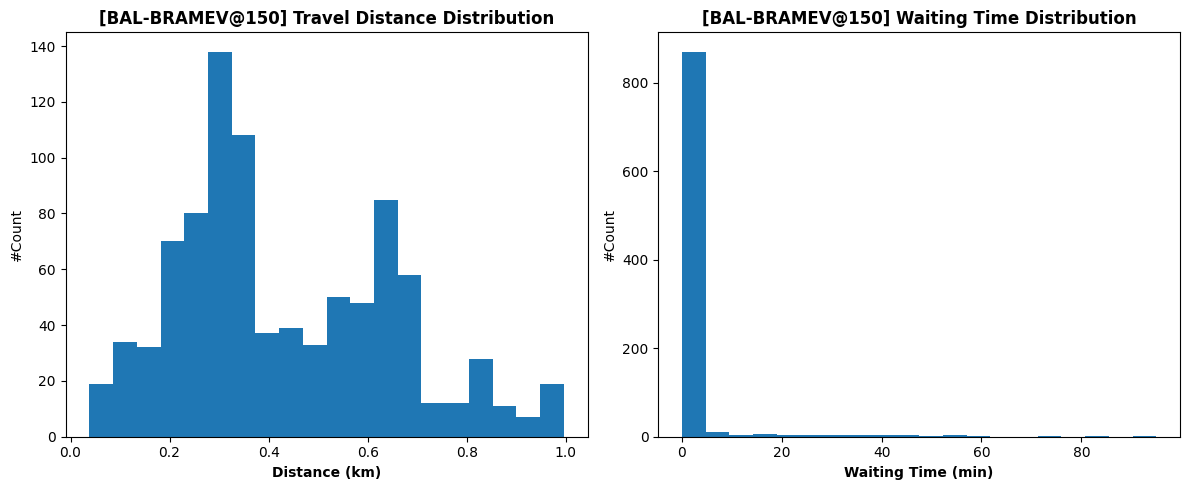

In [110]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

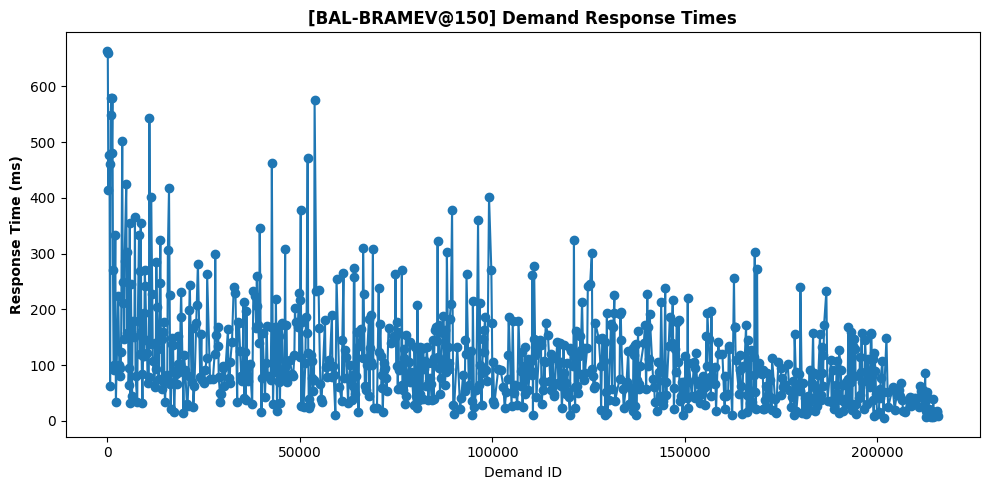

In [111]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

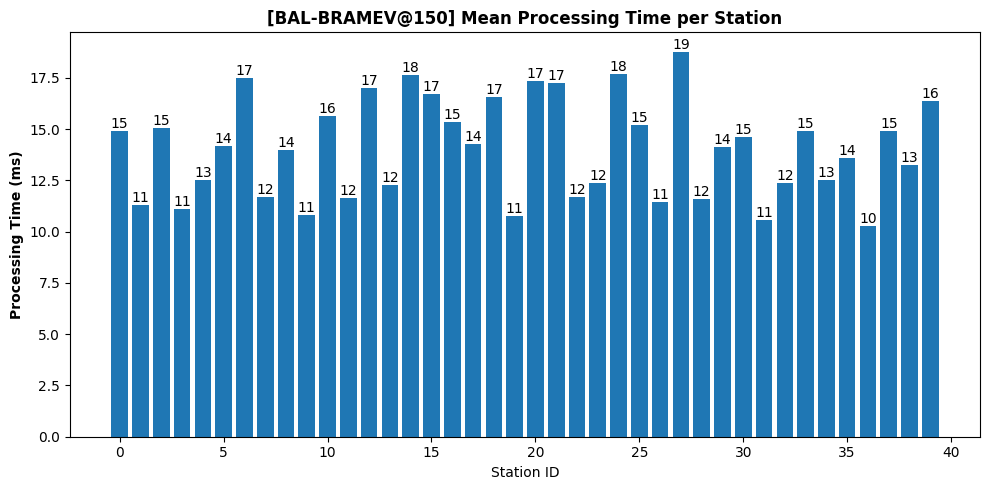

In [112]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

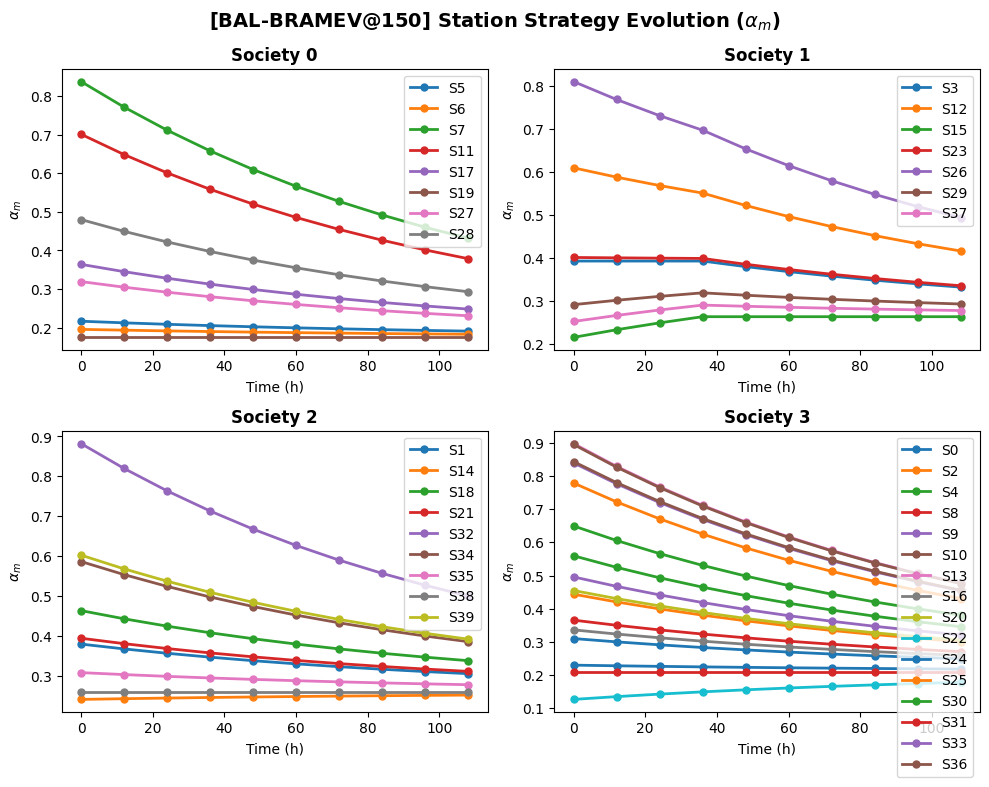

In [113]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [114]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           5  0.090278  0.000000  0.000000  0.000000  0.000000   
1            0           6  0.316667  0.111806  0.018750  0.000000  0.040972   
2            0           7  0.342361  0.072222  0.000000  0.034722       NaN   
3            0          11  0.246528  0.072222  0.000000  0.000000       NaN   
4            0          17  0.366667  0.226389  0.062500  0.000000  0.067361   
5            0          19  0.753472  0.638889  0.369444  0.352083       NaN   
6            0          27  0.052778  0.016667  0.000000  0.000000  0.000000   
7            0          28  0.103472  0.000000  0.000000  0.000000       NaN   
8            1           3  0.309028  0.262500  0.052778  0.052083       NaN   
9            1          12  0.234028  0.077083  0.000000  0.000000  0.000000   
10           1          15  0.559722  0.344444  0.138194  0.041667  0.084028   
11           1          23  0.153472  0.

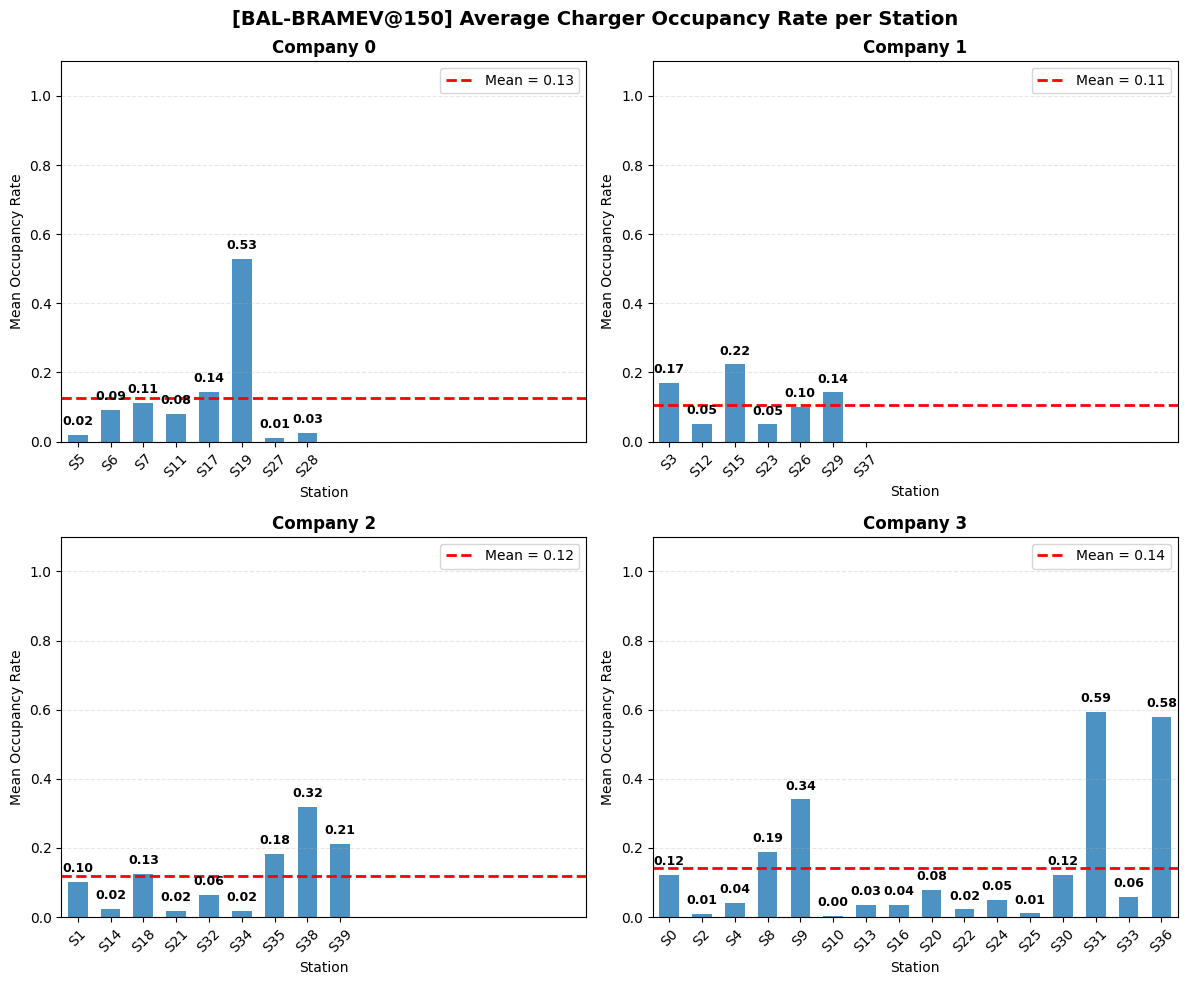

In [115]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

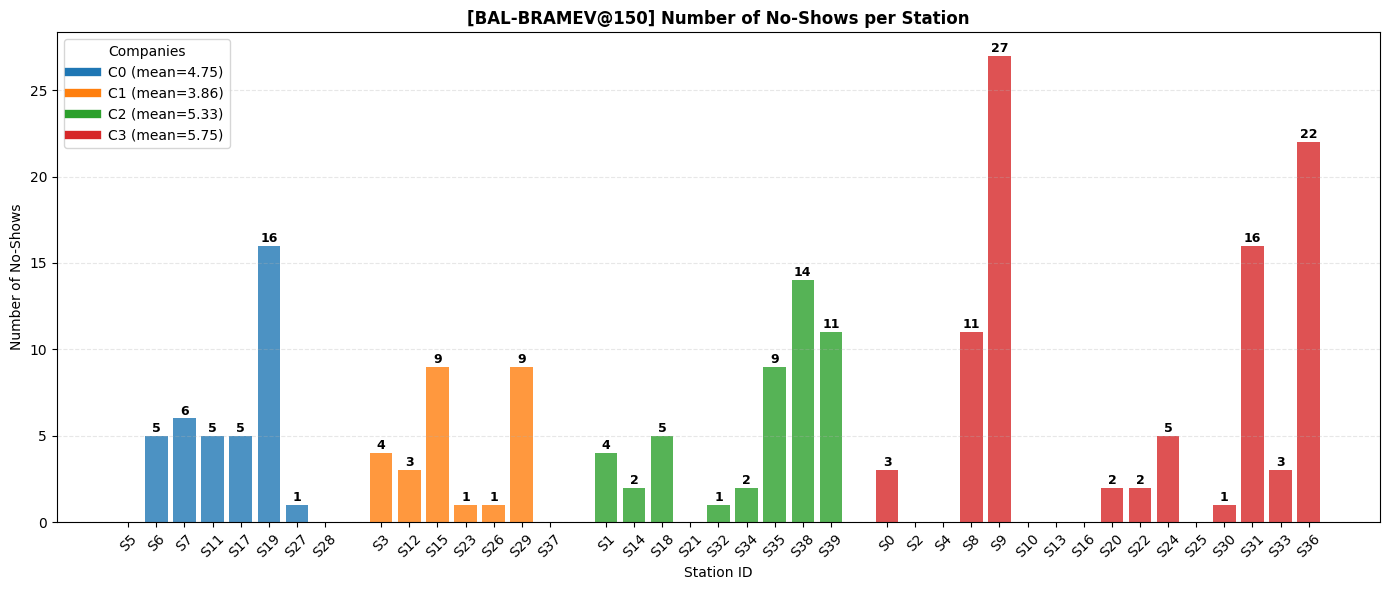

In [116]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [117]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,5,3,3,0,0,0,1.000000,0.000000,0.0,0.0
1,0,6,26,21,5,0,0,0.807692,0.192308,0.0,0.0
2,0,7,20,14,6,0,0,0.700000,0.300000,0.0,0.0
3,0,11,19,14,5,0,0,0.736842,0.263158,0.0,0.0
4,0,17,33,27,5,0,0,0.818182,0.151515,0.0,0.0
5,0,19,97,81,16,0,0,0.835052,0.164948,0.0,0.0
6,0,27,5,4,1,0,0,0.800000,0.200000,0.0,0.0
7,0,28,4,4,0,0,0,1.000000,0.000000,0.0,0.0
8,1,3,26,22,4,0,0,0.846154,0.153846,0.0,0.0
9,1,12,15,12,3,0,0,0.800000,0.200000,0.0,0.0


#### **COMPARISON**

##### *Params*

In [118]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

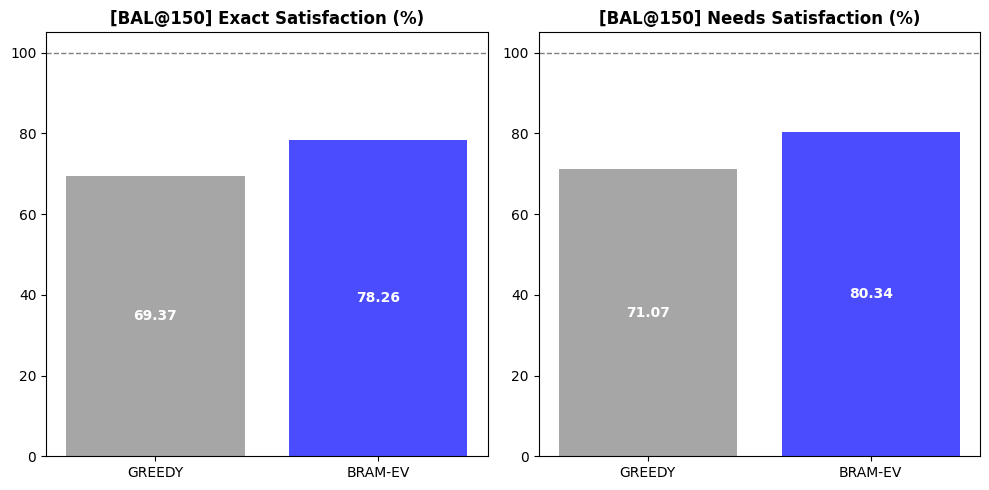

In [119]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

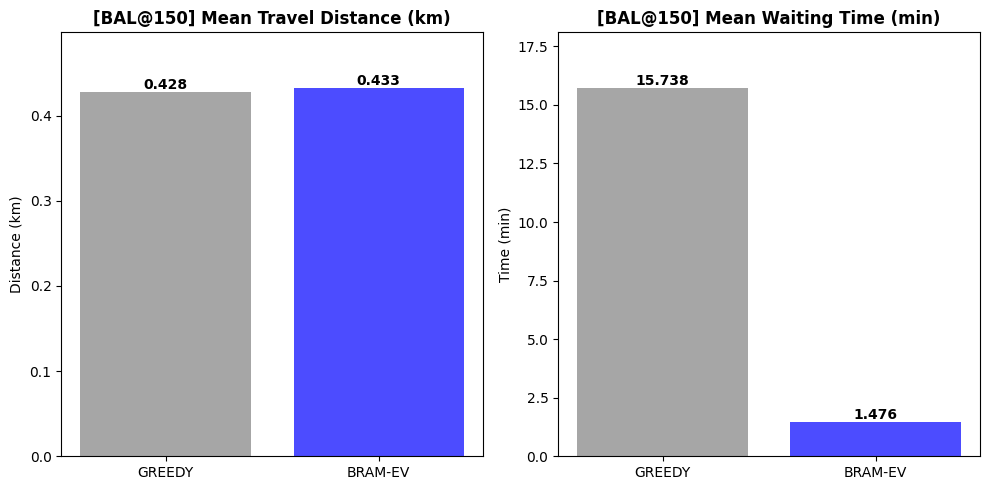

In [120]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

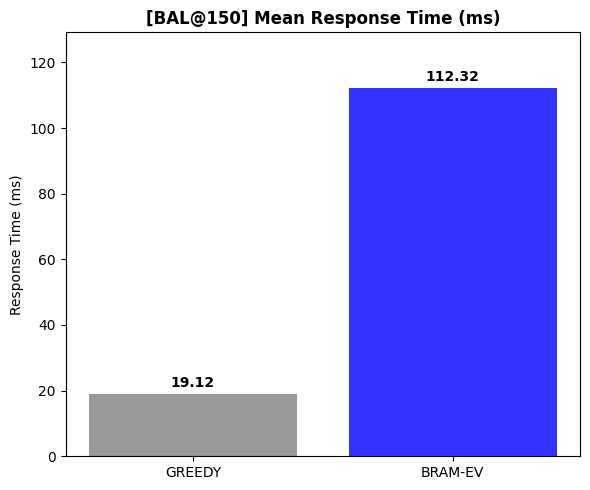

In [121]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@200cars**

#### **CONFIG**

In [122]:
nb_car = 200
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [123]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [124]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [125]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:35:16.919 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-13 23:35:17.276 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-13 23:35:17.593 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-13 23:35:17.737 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-13 23:35:18.047 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-13 23:35:18.332 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-13 23:35:18.529 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-13 23:35:18.860 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-13 23:35:19.283 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-13 23:35:19.522 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-13 23:35:20.130 | IN

##### *Metrics*

In [126]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 12.32 kWh
  Station 1: 158.47 kWh
  Station 2: 92.45 kWh
  Station 3: 211.57 kWh
  Station 4: 75.74 kWh
  Station 5: 92.85 kWh
  Station 6: 6.14 kWh
  Station 7: 18.33 kWh
  Station 8: 0.00 kWh
  Station 9: 28.35 kWh
  Station 10: 7.81 kWh
  Station 11: 19.62 kWh
  Station 12: 80.01 kWh
  Station 13: 19.85 kWh
  Station 14: 2.39 kWh
  Station 15: 32.67 kWh
  Station 16: 13.35 kWh
  Station 17: 100.18 kWh
  Station 18: 63.99 kWh
  Station 19: 122.93 kWh
  Station 20: 5.42 kWh
  Station 21: 28.03 kWh
  Station 22: 6.87 kWh
  Station 23: 8.73 kWh
  Station 24: 9.28 kWh
  Station 25: 3.75 kWh
  Station 26: 152.97 kWh
  Station 27: 19.10 kWh
  Station 28: 11.93 kWh
  Station 29: 235.80 kWh
  Station 30: 56.26 kWh
  Station 31: 4.53 kWh
  Station 32: 3.46 kWh
  Station 33: 55.73 kWh
  Station 34: 62.00 kWh
  Station 35: 191.42 kWh
  Station 36: 10.57 kWh
  Station 37: 20.48 kWh
  Station 38: 8.32 kWh
  Station 39: 4.

In [127]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

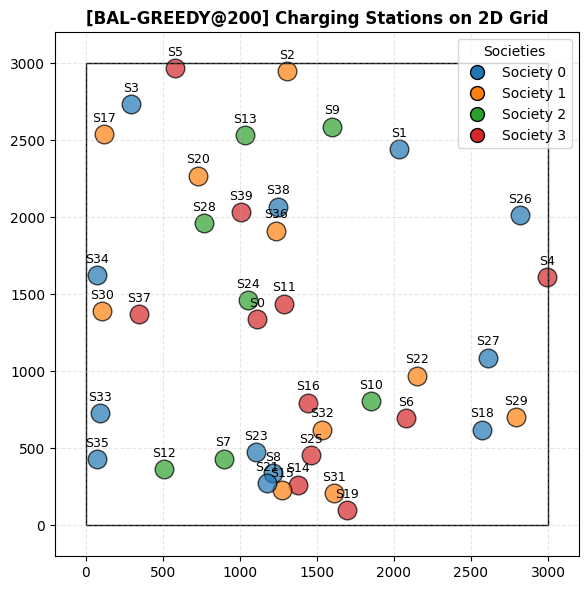

In [128]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

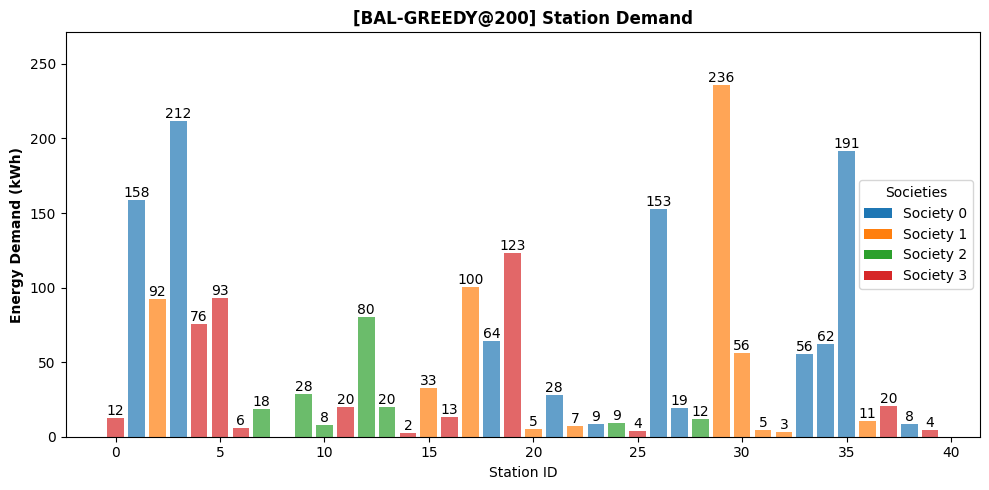

In [129]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

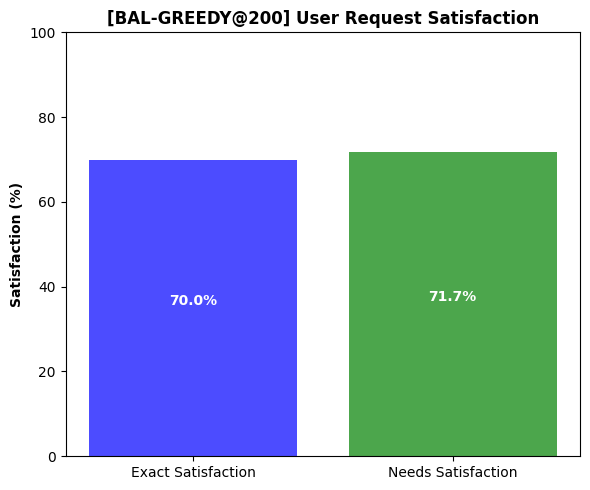

In [130]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

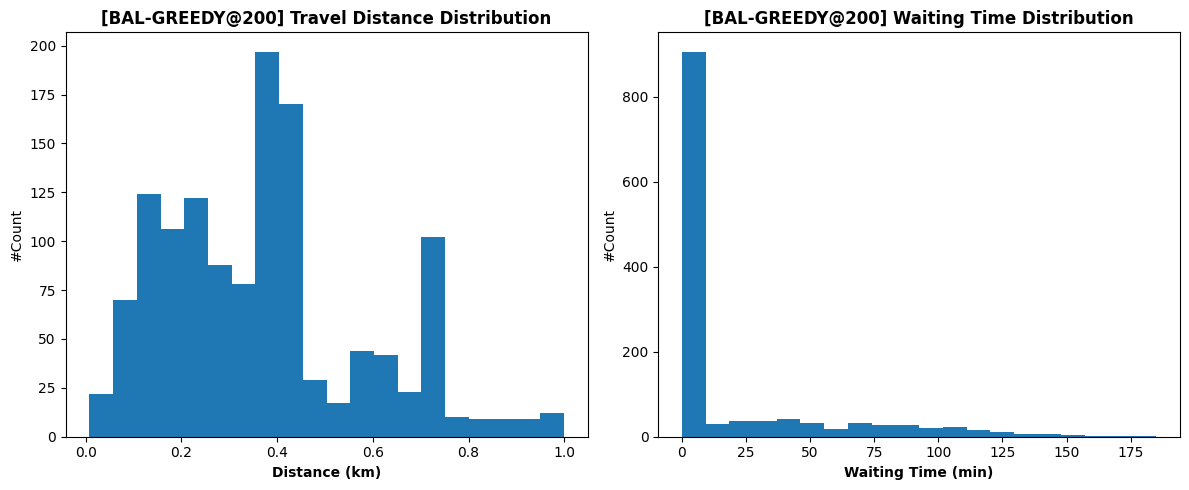

In [131]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

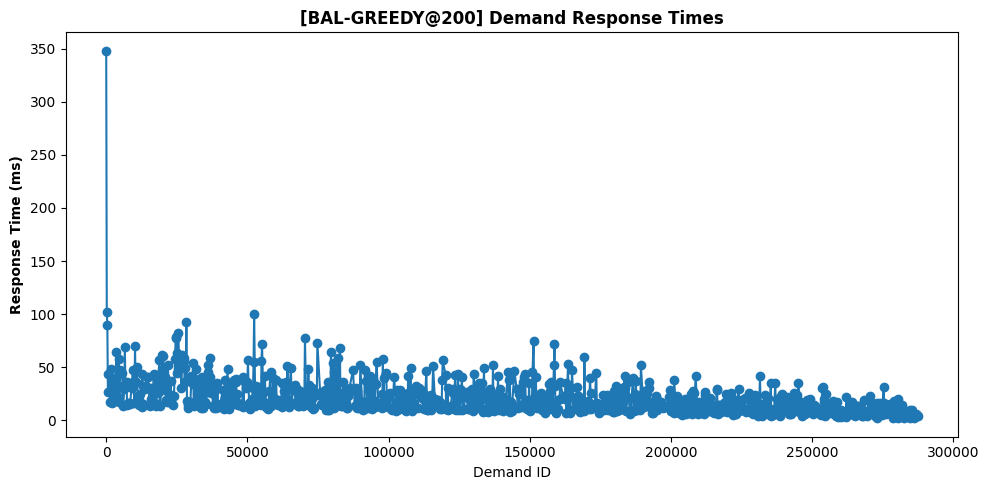

In [132]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

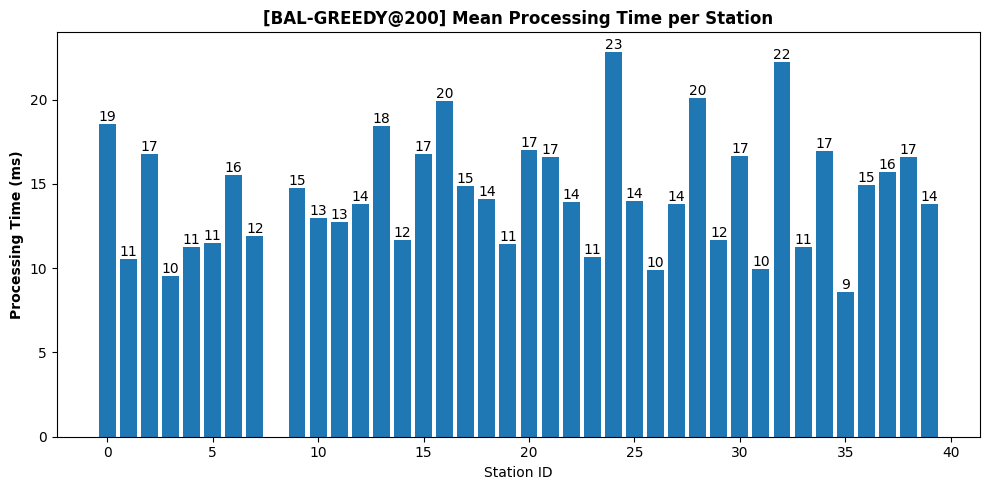

In [133]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [134]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           1  0.695833  0.524306  0.563889  0.492361       NaN   
1            0           3  0.855556  0.662500  0.816667  0.667361       NaN   
2            0           8  0.000000  0.000000  0.000000  0.000000       NaN   
3            0          18  0.423611  0.309028  0.090972  0.013194  0.111111   
4            0          21  0.251389  0.097917  0.021528  0.011806  0.000000   
5            0          23  0.095833  0.018750  0.000000  0.000000       NaN   
6            0          26  0.625694  0.631944  0.519444  0.500694       NaN   
7            0          27  0.186111  0.065278  0.000000  0.000000  0.000000   
8            0          33  0.477778  0.142361  0.045833  0.165972       NaN   
9            0          34  0.486806  0.239583  0.022222  0.000000  0.031944   
10           0          35  0.612500  0.768056  0.765972  0.608333       NaN   
11           0          38  0.157639  0.

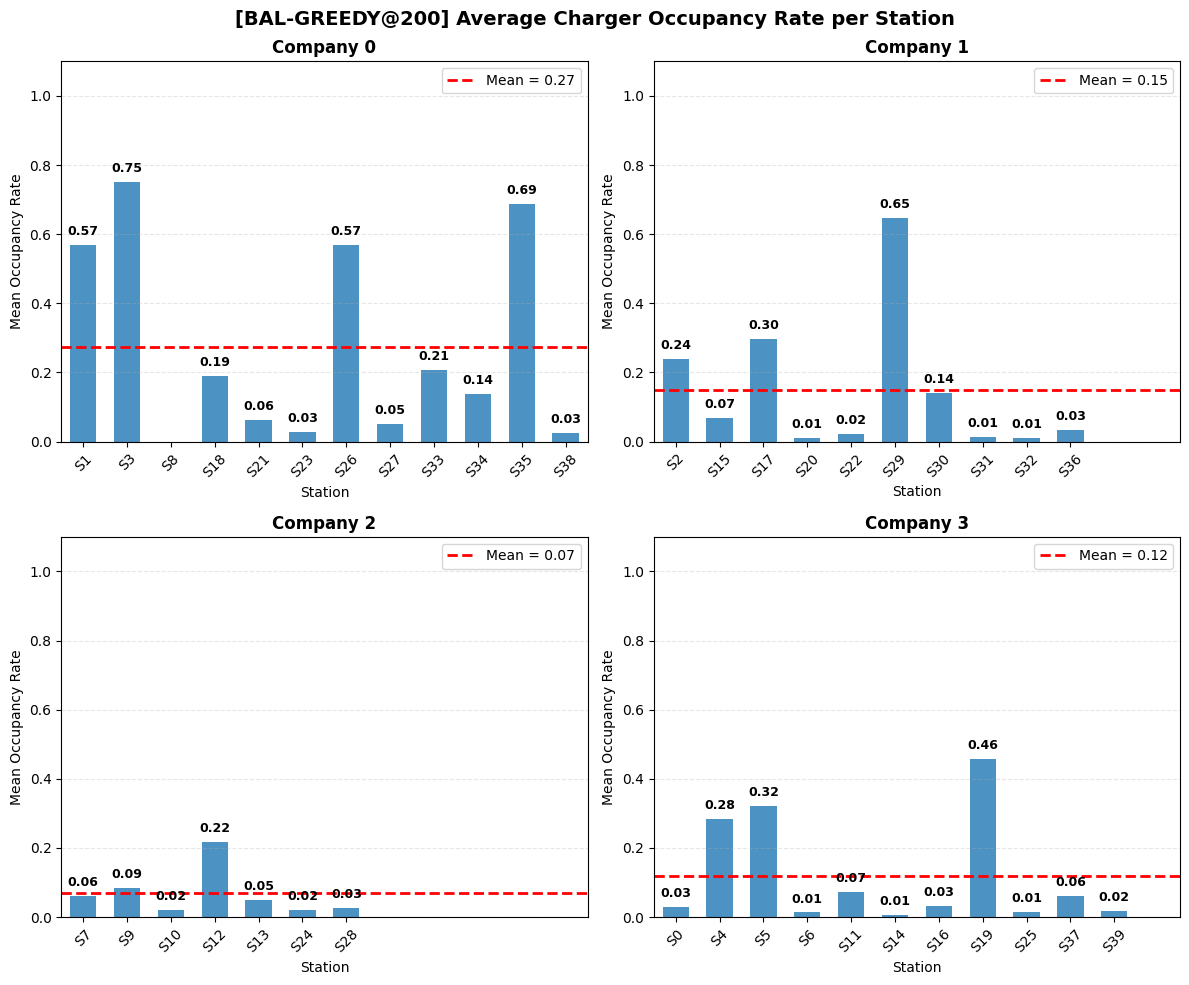

In [135]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

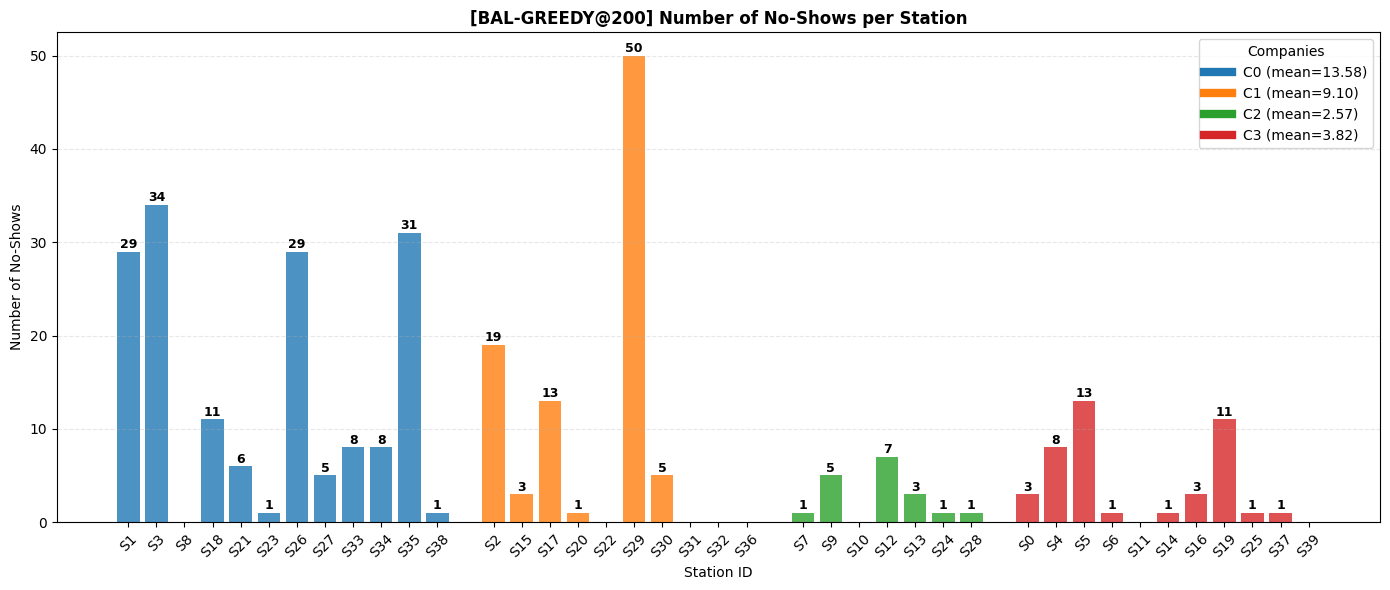

In [136]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [137]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,1,127,98,29,0,0,0.771654,0.228346,0.000000,0.000000
1,0,3,194,153,34,2,2,0.788660,0.175258,0.010309,0.010309
2,0,8,0,0,0,0,0,NaN,NaN,NaN,NaN
3,0,18,48,36,11,0,0,0.750000,0.229167,0.000000,0.000000
4,0,21,22,16,6,0,0,0.727273,0.272727,0.000000,0.000000
5,0,23,6,5,1,0,0,0.833333,0.166667,0.000000,0.000000
6,0,26,129,95,29,1,0,0.736434,0.224806,0.007752,0.000000
7,0,27,15,10,5,0,0,0.666667,0.333333,0.000000,0.000000
8,0,33,38,30,8,0,0,0.789474,0.210526,0.000000,0.000000
9,0,34,41,33,8,0,0,0.804878,0.195122,0.000000,0.000000


#### **BRAM-EV**

##### *Params*

In [138]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [139]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [140]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:35:48.872 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 23:35:56.051 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 23:35:58.124 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 23:35:59.996 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 23:36:01.879 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 23:36:03.919 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 23:36:05.472 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 23:36:07.052 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 23:36:08.524 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 23:36:09.570 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 23:36:10.930 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [141]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 0.00 kWh
  Station 1: 85.45 kWh
  Station 2: 11.10 kWh
  Station 3: 39.77 kWh
  Station 4: 50.54 kWh
  Station 5: 3.54 kWh
  Station 6: 21.14 kWh
  Station 7: 192.38 kWh
  Station 8: 110.35 kWh
  Station 9: 88.53 kWh
  Station 10: 7.70 kWh
  Station 11: 20.62 kWh
  Station 12: 14.04 kWh
  Station 13: 194.65 kWh
  Station 14: 1.69 kWh
  Station 15: 4.67 kWh
  Station 16: 167.77 kWh
  Station 17: 9.52 kWh
  Station 18: 96.20 kWh
  Station 19: 45.02 kWh
  Station 20: 39.35 kWh
  Station 21: 15.43 kWh
  Station 22: 73.23 kWh
  Station 23: 3.47 kWh
  Station 24: 15.29 kWh
  Station 25: 102.56 kWh
  Station 26: 19.75 kWh
  Station 27: 10.63 kWh
  Station 28: 77.11 kWh
  Station 29: 114.84 kWh
  Station 30: 41.00 kWh
  Station 31: 13.28 kWh
  Station 32: 21.78 kWh
  Station 33: 33.27 kWh
  Station 34: 61.99 kWh
  Station 35: 11.24 kWh
  Station 36: 13.82 kWh
  Station 37: 46.37 kWh
  Station 38: 112.17 kWh
  Station 3

In [142]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

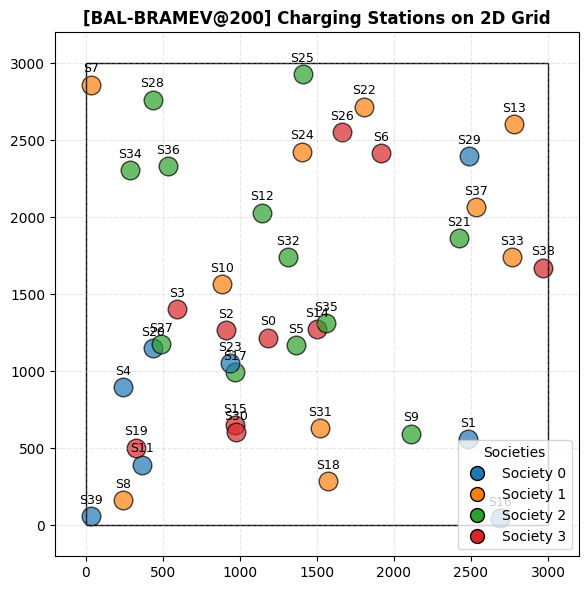

In [143]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

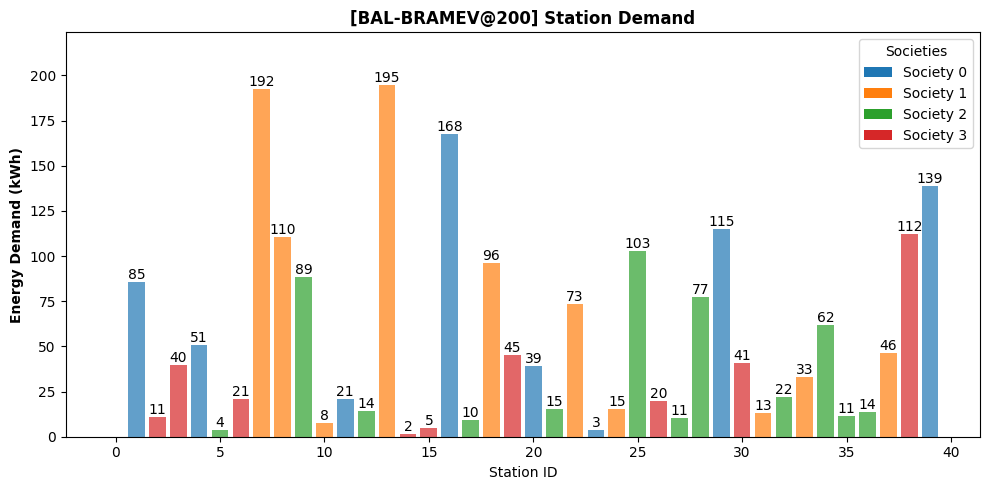

In [144]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

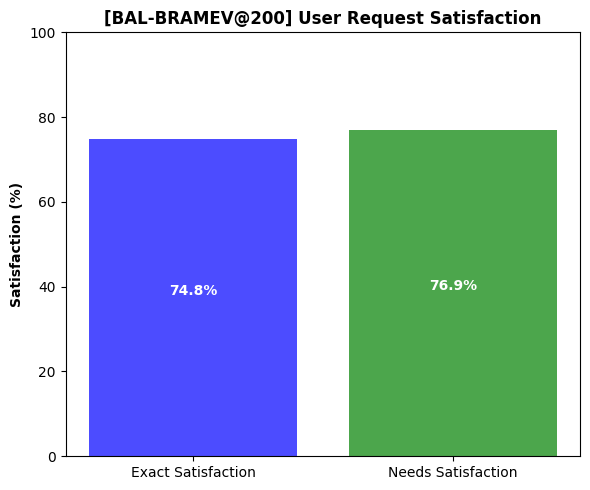

In [145]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

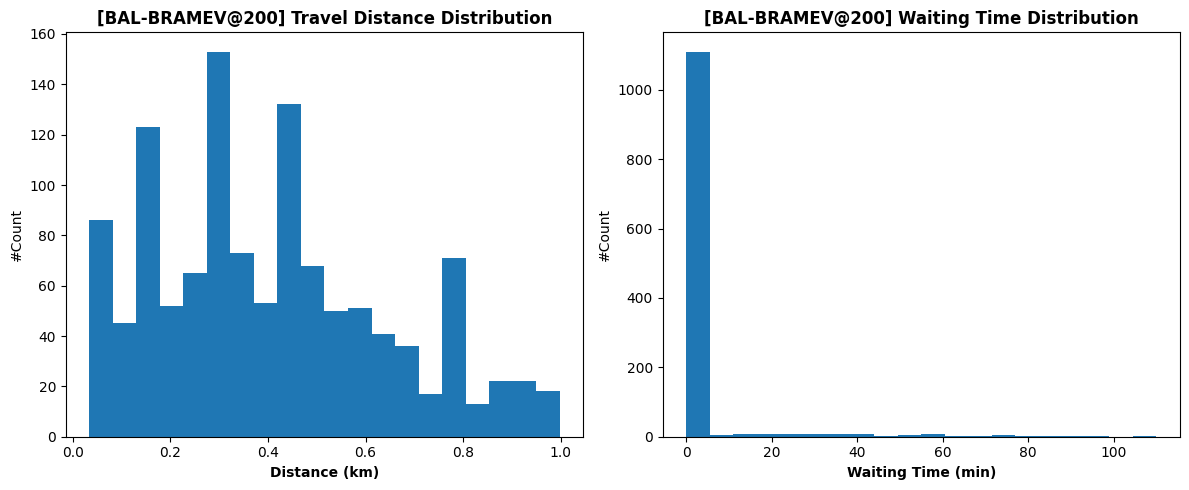

In [146]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

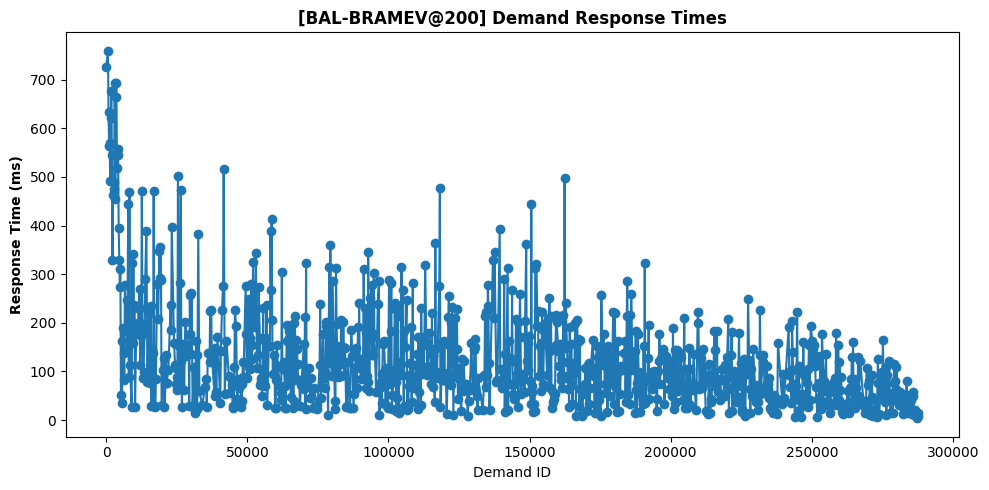

In [147]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

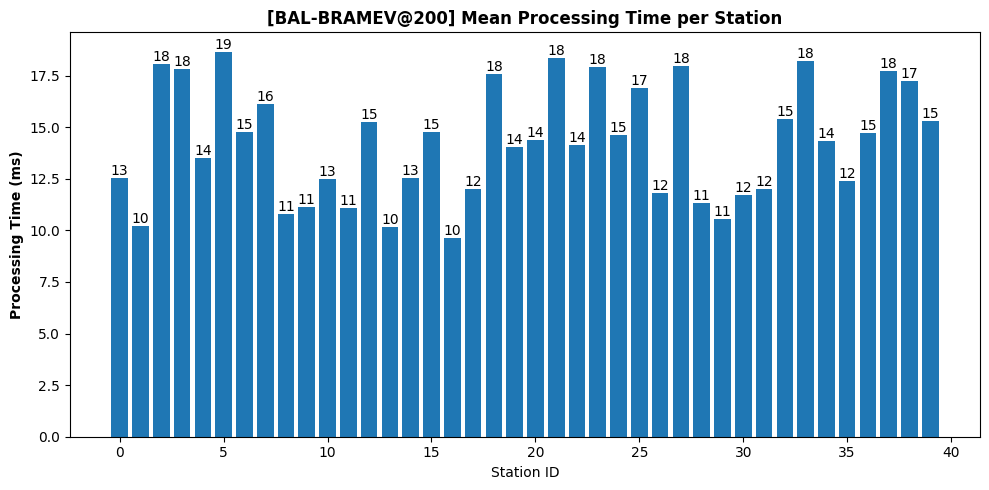

In [148]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

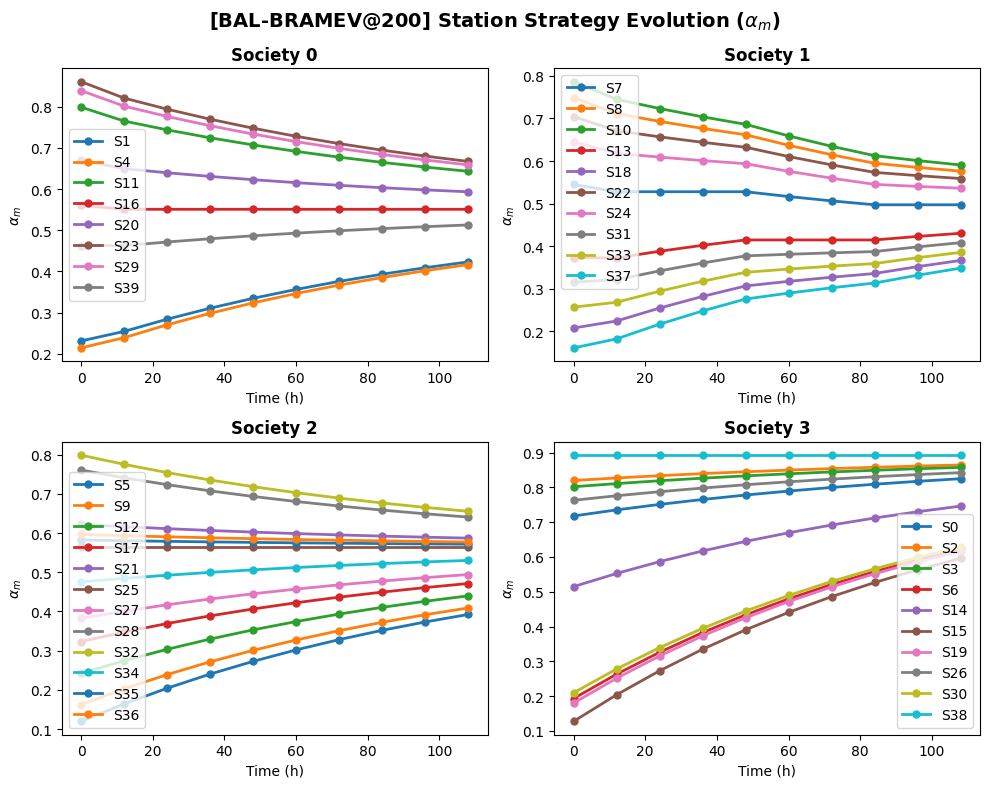

In [149]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [150]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           1  0.522917  0.384028  0.129167  0.242361       NaN   
1            0           4  0.404167  0.199306  0.040972  0.000000  0.111806   
2            0          11  0.180556  0.102083  0.000000  0.000000       NaN   
3            0          16  0.634028  0.661806  0.620139  0.479861       NaN   
4            0          20  0.284028  0.150694  0.074306  0.034722  0.027778   
5            0          23  0.055556  0.000000  0.000000  0.000000  0.000000   
6            0          29  0.561111  0.579167  0.222917  0.326389       NaN   
7            0          39  0.582639  0.465972  0.336111  0.196528  0.227083   
8            1           7  0.647917  0.537500  0.397222  0.434722  0.269444   
9            1           8  0.534028  0.458333  0.236111  0.347917       NaN   
10           1          10  0.127083  0.000000  0.000000  0.000000       NaN   
11           1          13  0.786111  0.

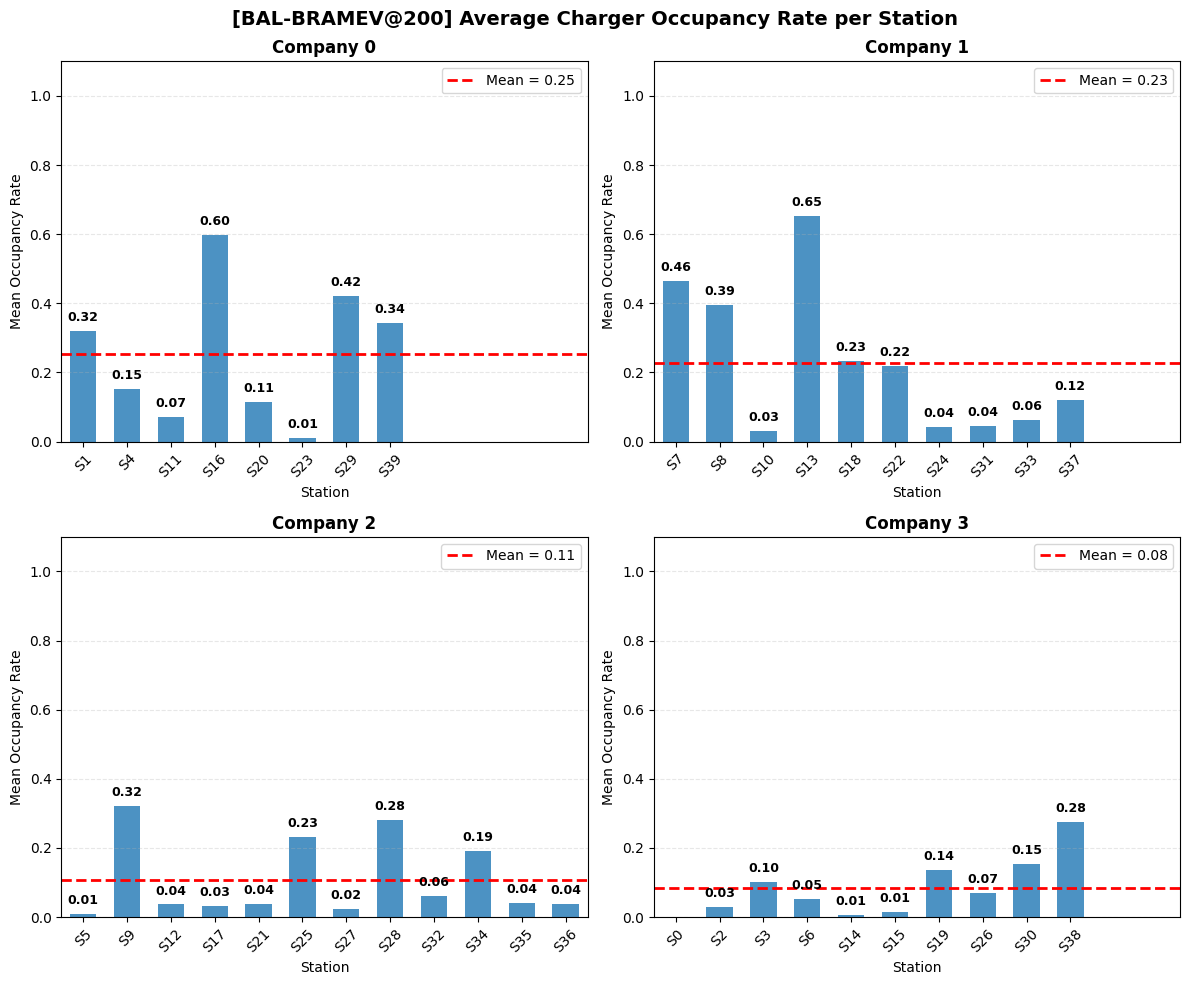

In [151]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

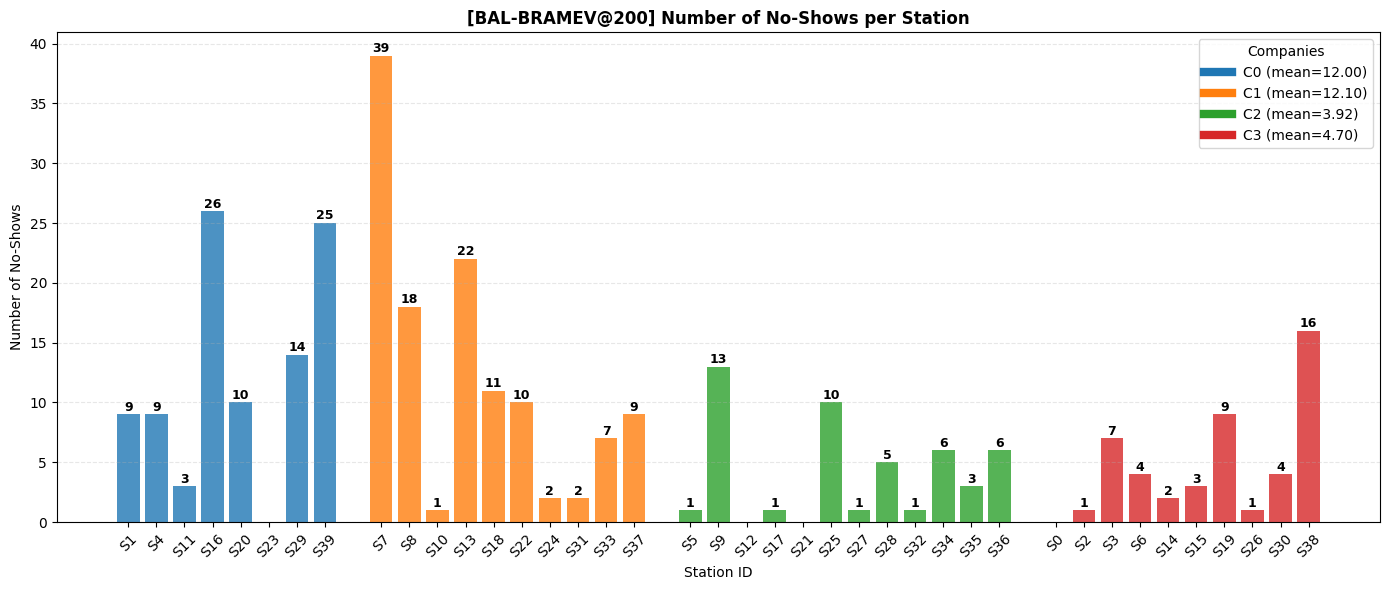

In [152]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [153]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,1,57,47,9,0,0,0.824561,0.157895,0.0,0.0
1,0,4,37,28,9,0,0,0.756757,0.243243,0.0,0.0
2,0,11,16,12,3,0,0,0.750000,0.187500,0.0,0.0
3,0,16,120,94,26,0,0,0.783333,0.216667,0.0,0.0
4,0,20,33,22,10,0,0,0.666667,0.303030,0.0,0.0
5,0,23,2,2,0,0,0,1.000000,0.000000,0.0,0.0
6,0,29,80,64,14,0,0,0.800000,0.175000,0.0,0.0
7,0,39,105,79,25,0,0,0.752381,0.238095,0.0,0.0
8,1,7,145,104,39,0,0,0.717241,0.268966,0.0,0.0
9,1,8,80,60,18,0,0,0.750000,0.225000,0.0,0.0


#### **COMPARISON**

##### *Params*

In [154]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

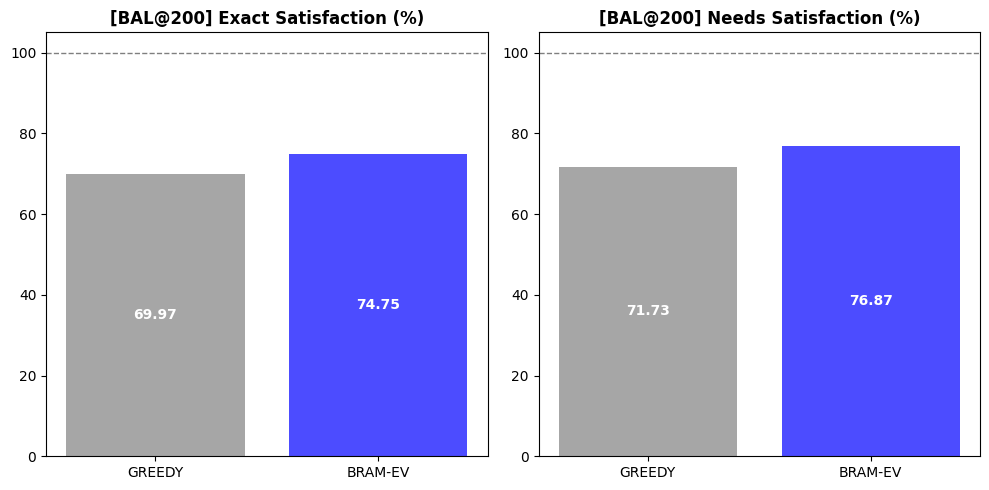

In [155]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

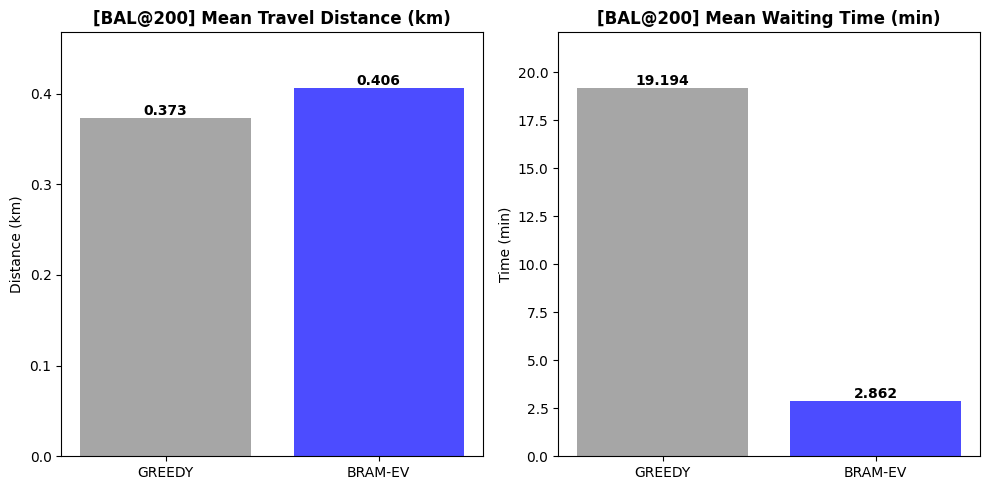

In [156]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

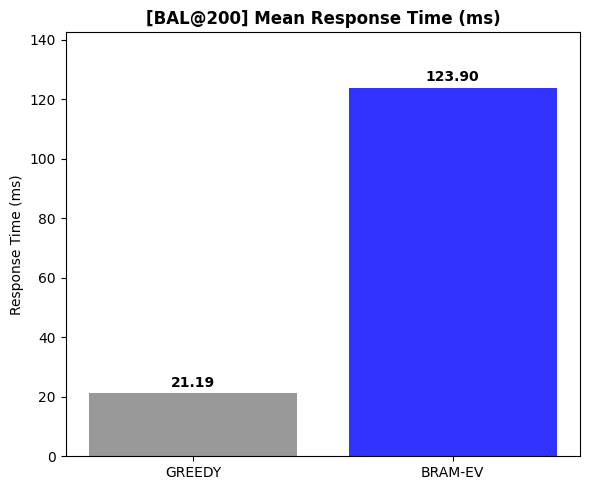

In [157]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@250cars**

#### **CONFIG**

In [158]:
nb_car = 250
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [159]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [160]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [161]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:37:53.593 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-13 23:37:53.925 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-13 23:37:54.334 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-13 23:37:54.722 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-13 23:37:55.113 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-13 23:37:55.387 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-13 23:37:55.865 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-13 23:37:56.486 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-13 23:37:56.979 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-13 23:37:57.294 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-13 23:37:57.730 | IN

##### *Metrics*

In [162]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 141.97 kWh
  Station 1: 39.11 kWh
  Station 2: 4.43 kWh
  Station 3: 92.96 kWh
  Station 4: 130.30 kWh
  Station 5: 6.26 kWh
  Station 6: 3.67 kWh
  Station 7: 43.83 kWh
  Station 8: 283.55 kWh
  Station 9: 44.63 kWh
  Station 10: 72.18 kWh
  Station 11: 4.56 kWh
  Station 12: 5.52 kWh
  Station 13: 17.16 kWh
  Station 14: 168.90 kWh
  Station 15: 2.92 kWh
  Station 16: 9.66 kWh
  Station 17: 3.50 kWh
  Station 18: 99.94 kWh
  Station 19: 55.32 kWh
  Station 20: 13.44 kWh
  Station 21: 19.82 kWh
  Station 22: 4.80 kWh
  Station 23: 301.14 kWh
  Station 24: 21.67 kWh
  Station 25: 5.05 kWh
  Station 26: 43.54 kWh
  Station 27: 31.95 kWh
  Station 28: 11.18 kWh
  Station 29: 4.58 kWh
  Station 30: 145.51 kWh
  Station 31: 8.96 kWh
  Station 32: 9.90 kWh
  Station 33: 86.22 kWh
  Station 34: 216.55 kWh
  Station 35: 17.25 kWh
  Station 36: 10.48 kWh
  Station 37: 1.20 kWh
  Station 38: 80.58 kWh
  Station 39: 304.

In [163]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

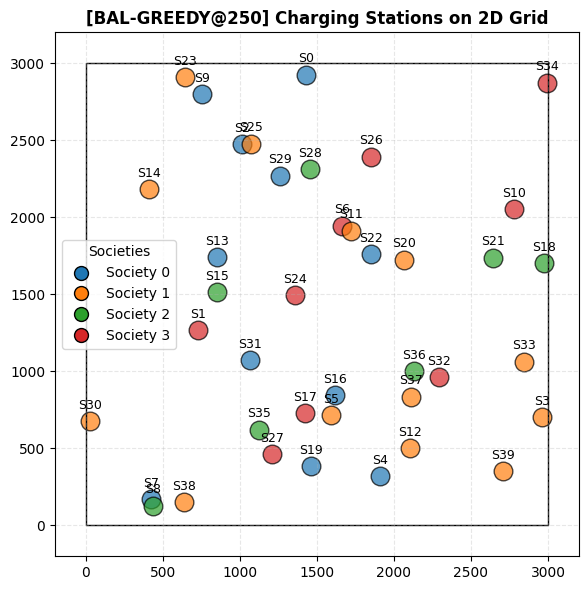

In [164]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

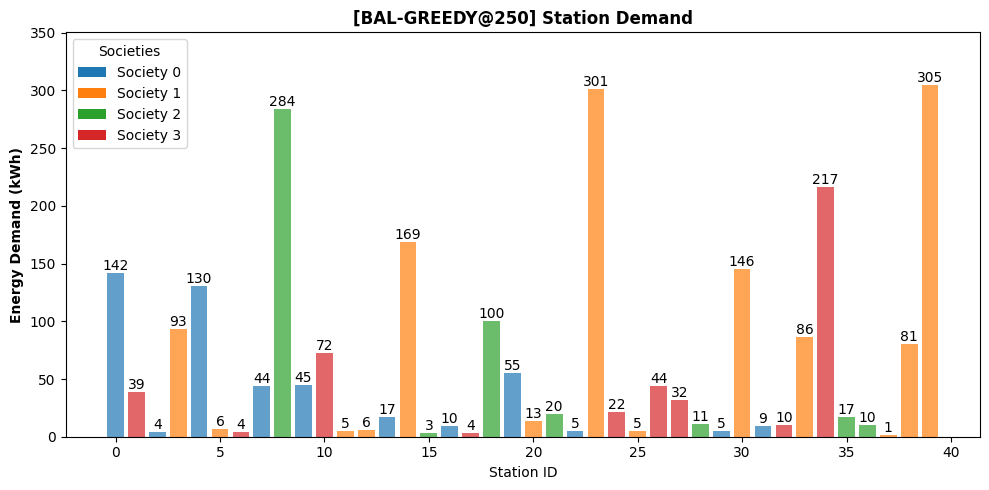

In [165]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

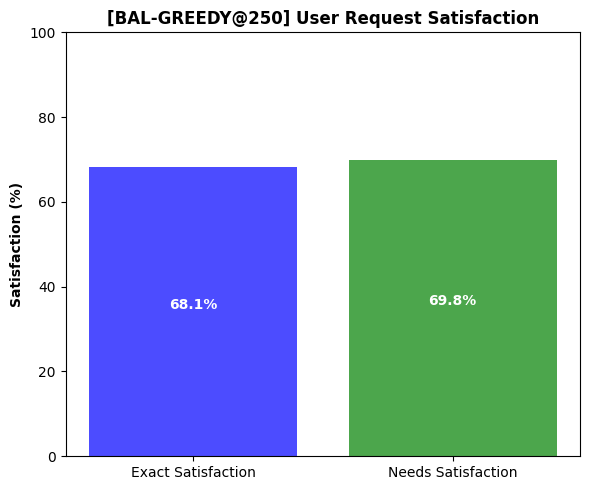

In [166]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

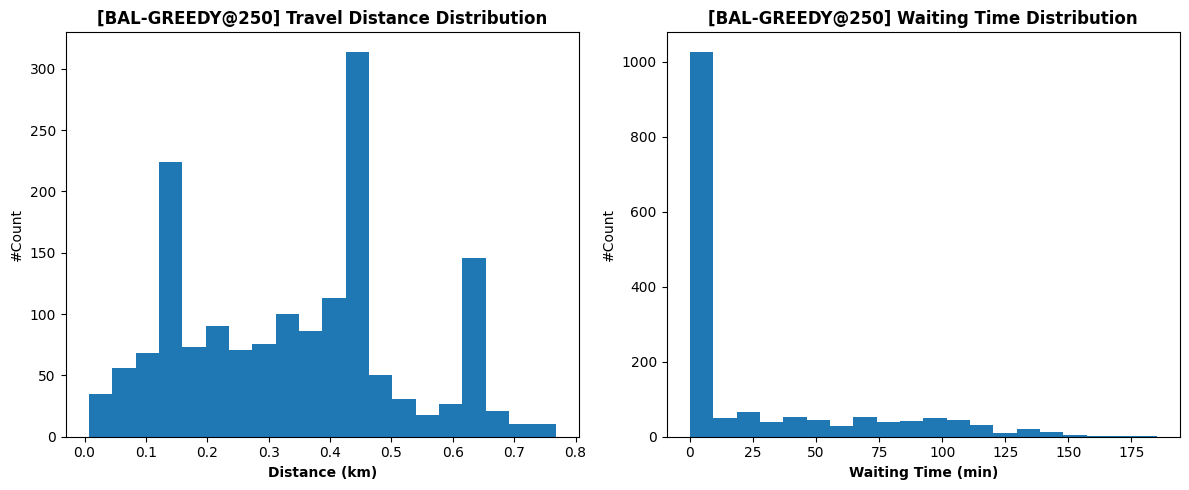

In [167]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

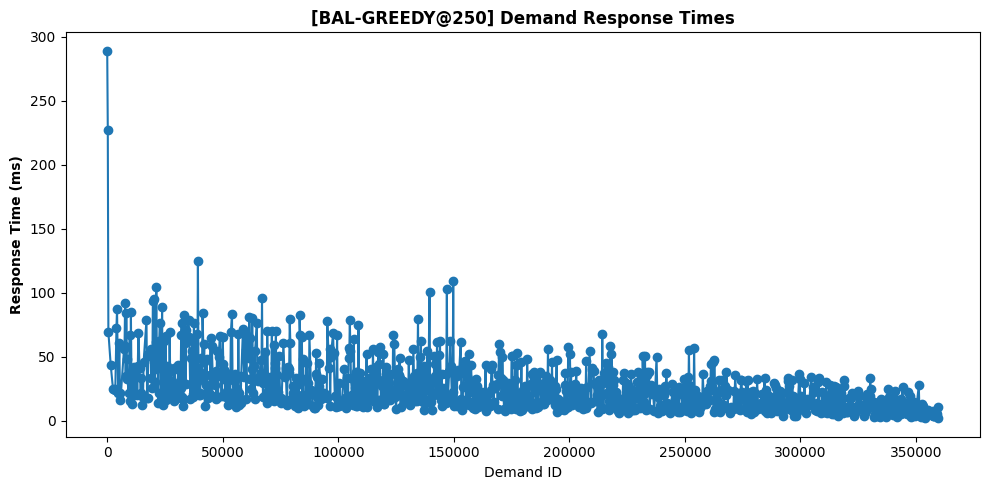

In [168]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

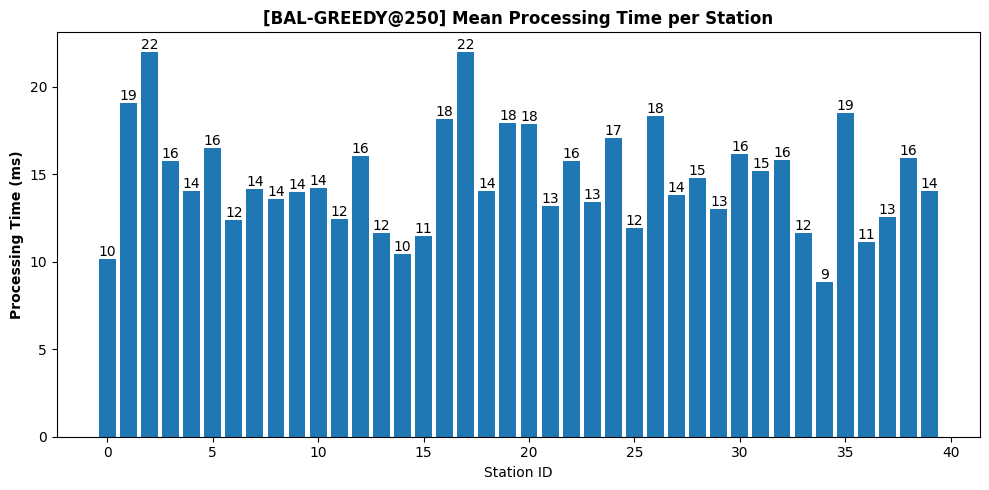

In [169]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [170]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           0  0.632639  0.624306  0.310417  0.395139       NaN   
1            0           2  0.084028  0.000000  0.000000  0.000000  0.000000   
2            0           4  0.710417  0.468750  0.272222  0.140972  0.295833   
3            0           7  0.286111  0.187500  0.002083  0.029167  0.109722   
4            0           9  0.456944  0.161806  0.006250  0.000000  0.052083   
5            0          13  0.169444  0.040278  0.025694  0.022222       NaN   
6            0          16  0.136806  0.000000  0.000000  0.000000  0.000000   
7            0          19  0.408333  0.255556  0.061111  0.000000  0.022222   
8            0          22  0.083333  0.000000  0.000000  0.000000  0.000000   
9            0          29  0.068750  0.000000  0.000000  0.000000       NaN   
10           0          31  0.121528  0.000000  0.000000  0.000000  0.000000   
11           1           3  0.538889  0.

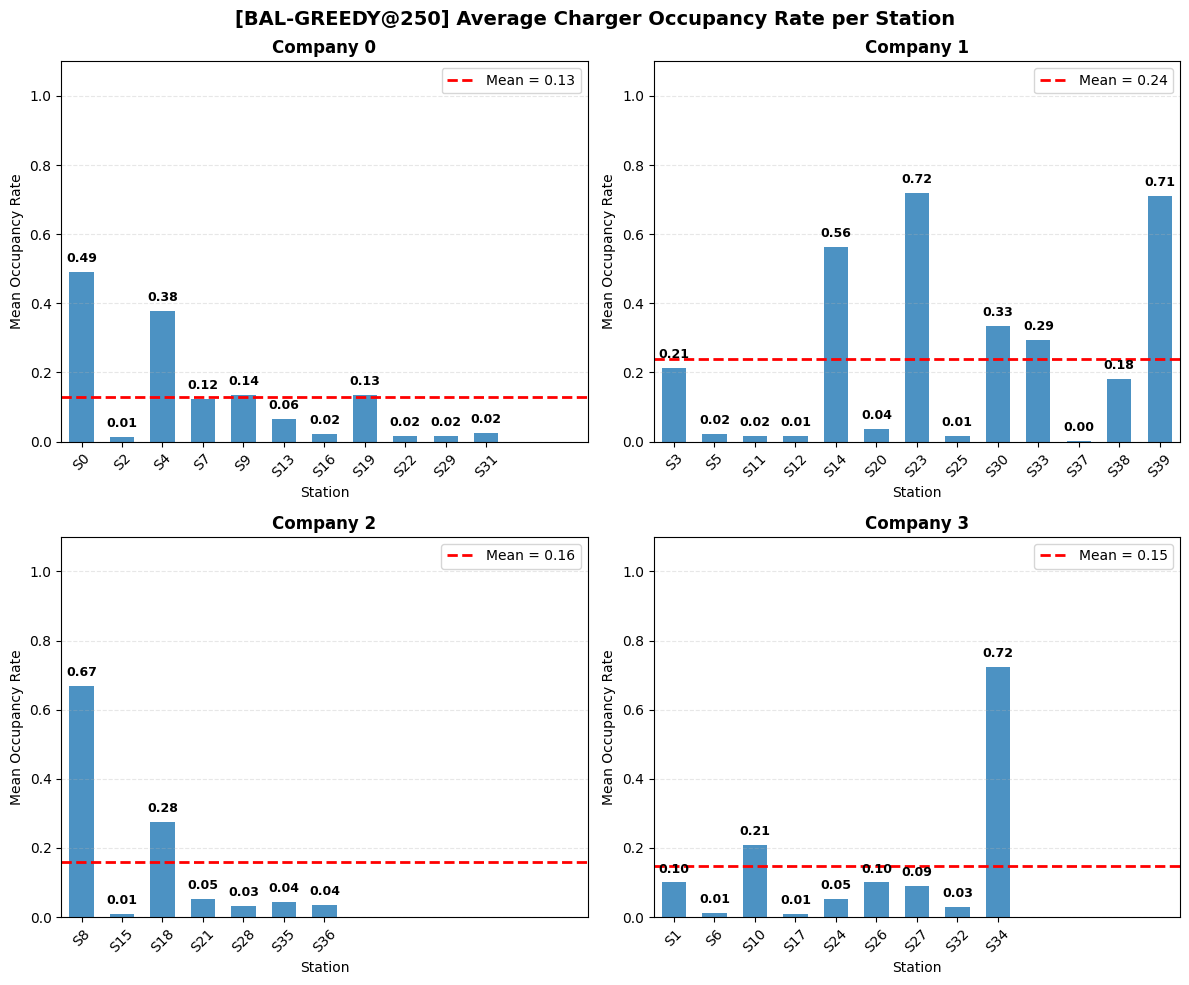

In [171]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

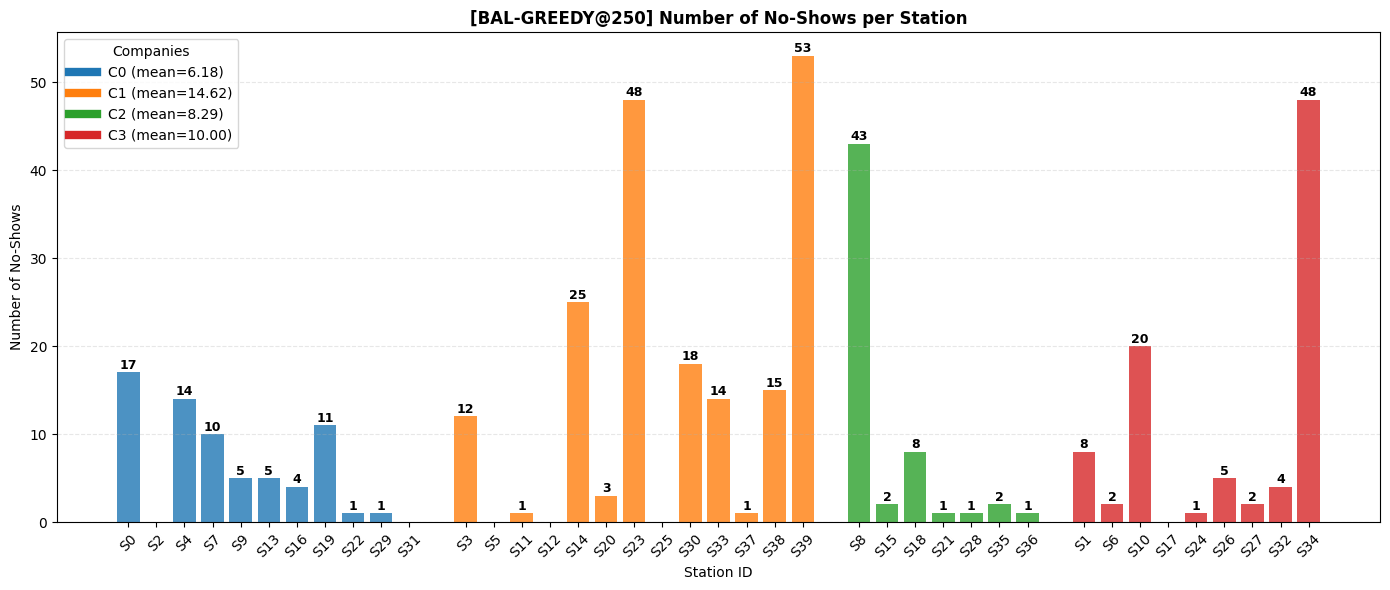

In [172]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [173]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,0,97,80,17,0,0,0.824742,0.175258,0.000000,0.000000
1,0,2,3,3,0,0,0,1.000000,0.000000,0.000000,0.000000
2,0,4,87,71,14,0,0,0.816092,0.160920,0.000000,0.000000
3,0,7,36,26,10,0,0,0.722222,0.277778,0.000000,0.000000
4,0,9,29,24,5,0,0,0.827586,0.172414,0.000000,0.000000
5,0,13,15,9,5,0,0,0.600000,0.333333,0.000000,0.000000
6,0,16,10,6,4,0,0,0.600000,0.400000,0.000000,0.000000
7,0,19,43,31,11,0,0,0.720930,0.255814,0.000000,0.000000
8,0,22,4,3,1,0,0,0.750000,0.250000,0.000000,0.000000
9,0,29,4,3,1,0,0,0.750000,0.250000,0.000000,0.000000


#### **BRAM-EV**

##### *Params*

In [174]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [175]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [176]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:38:36.363 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 23:38:43.041 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 23:38:45.249 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 23:38:47.896 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 23:38:49.888 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 23:38:51.977 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 23:38:54.728 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 23:38:56.919 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 23:38:59.816 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 23:39:01.368 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 23:39:02.597 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [177]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 83.26 kWh
  Station 1: 90.24 kWh
  Station 2: 154.88 kWh
  Station 3: 62.47 kWh
  Station 4: 224.78 kWh
  Station 5: 262.17 kWh
  Station 6: 3.29 kWh
  Station 7: 32.66 kWh
  Station 8: 103.13 kWh
  Station 9: 47.73 kWh
  Station 10: 18.84 kWh
  Station 11: 88.69 kWh
  Station 12: 170.17 kWh
  Station 13: 5.19 kWh
  Station 14: 202.04 kWh
  Station 15: 18.57 kWh
  Station 16: 62.18 kWh
  Station 17: 89.09 kWh
  Station 18: 91.02 kWh
  Station 19: 12.03 kWh
  Station 20: 28.01 kWh
  Station 21: 22.75 kWh
  Station 22: 7.55 kWh
  Station 23: 14.23 kWh
  Station 24: 89.62 kWh
  Station 25: 30.01 kWh
  Station 26: 90.31 kWh
  Station 27: 86.72 kWh
  Station 28: 36.73 kWh
  Station 29: 35.88 kWh
  Station 30: 22.15 kWh
  Station 31: 18.76 kWh
  Station 32: 93.50 kWh
  Station 33: 94.43 kWh
  Station 34: 62.12 kWh
  Station 35: 15.68 kWh
  Station 36: 24.07 kWh
  Station 37: 42.41 kWh
  Station 38: 9.55 kWh
  Station

In [178]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

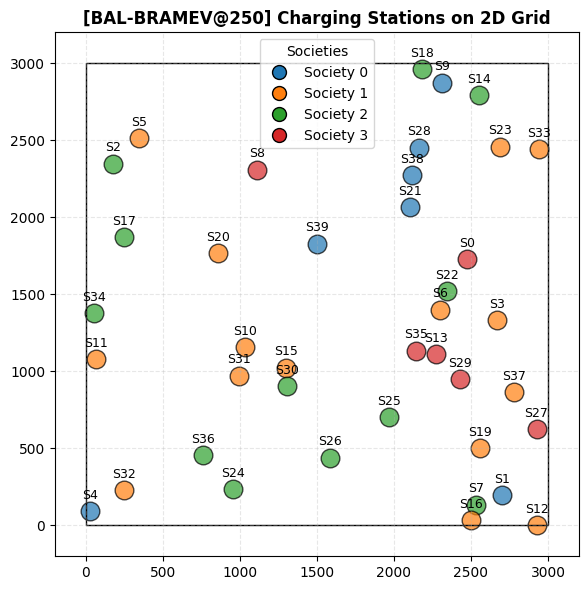

In [179]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

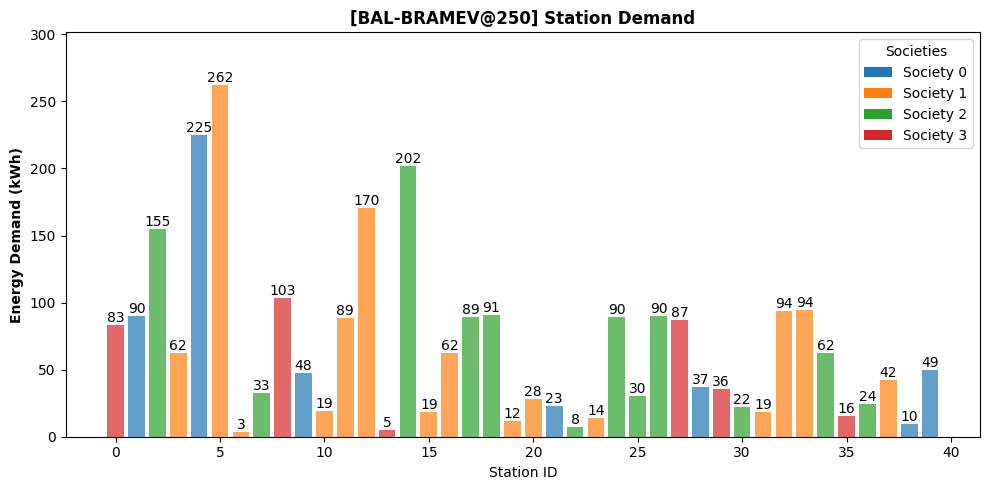

In [180]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

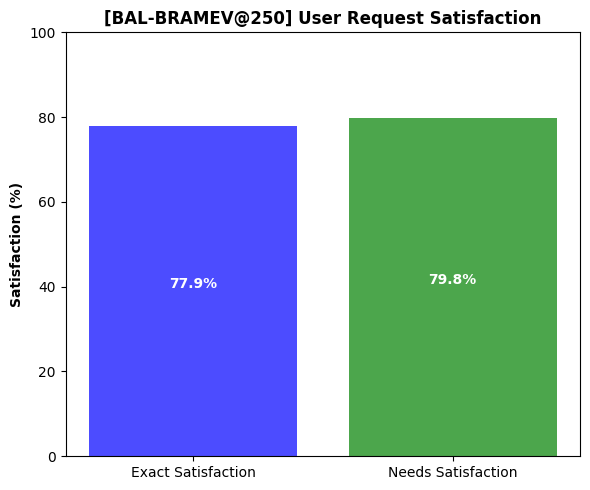

In [181]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

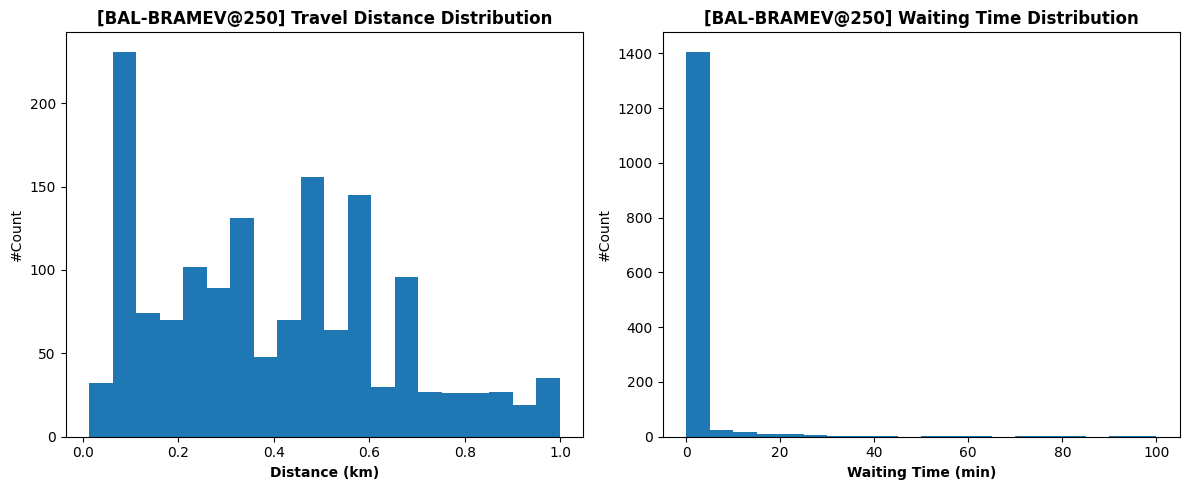

In [182]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

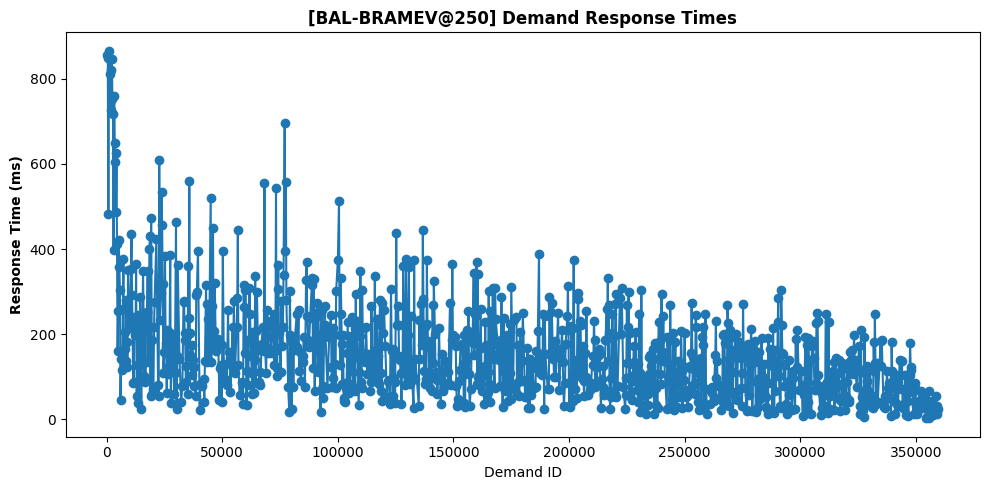

In [183]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

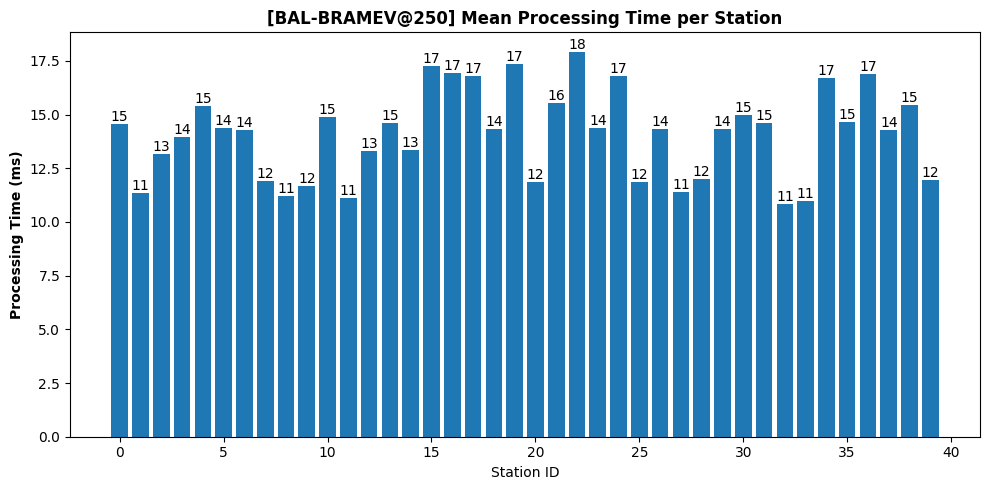

In [184]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

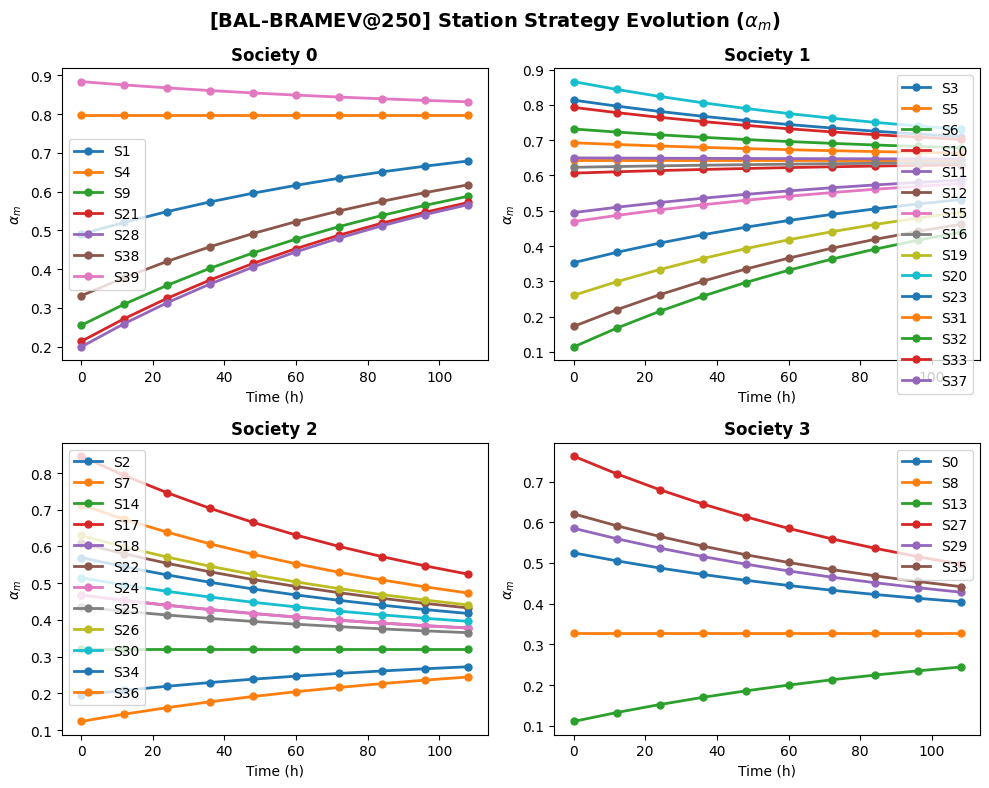

In [185]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [186]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           1  0.485417  0.397222  0.221528  0.287500       NaN   
1            0           4  0.705556  0.690972  0.472917  0.391667  0.394444   
2            0           9  0.362500  0.304167  0.024306  0.052083       NaN   
3            0          21  0.253472  0.086111  0.000000  0.000000  0.000000   
4            0          28  0.282639  0.204861  0.029167  0.028472       NaN   
5            0          38  0.118750  0.023611  0.000000  0.000000  0.000000   
6            0          39  0.373611  0.243750  0.058333  0.040972       NaN   
7            1           3  0.499306  0.253472  0.071528  0.018750  0.092361   
8            1           5  0.821528  0.738194  0.602778  0.472917  0.580556   
9            1           6  0.033333  0.020139  0.000000  0.000000  0.000000   
10           1          10  0.154861  0.094444  0.000000  0.000000  0.021528   
11           1          11  0.484722  0.

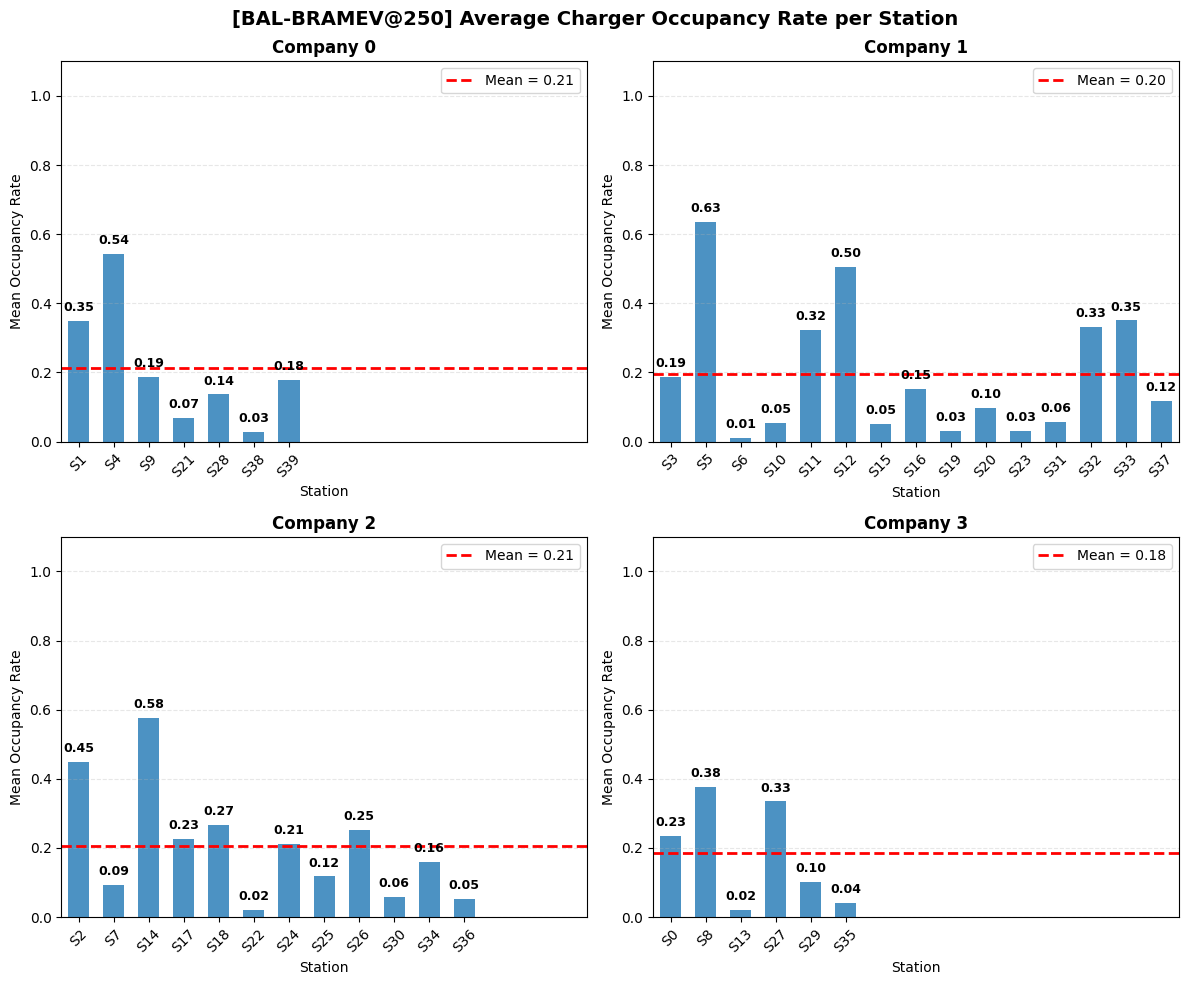

In [187]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

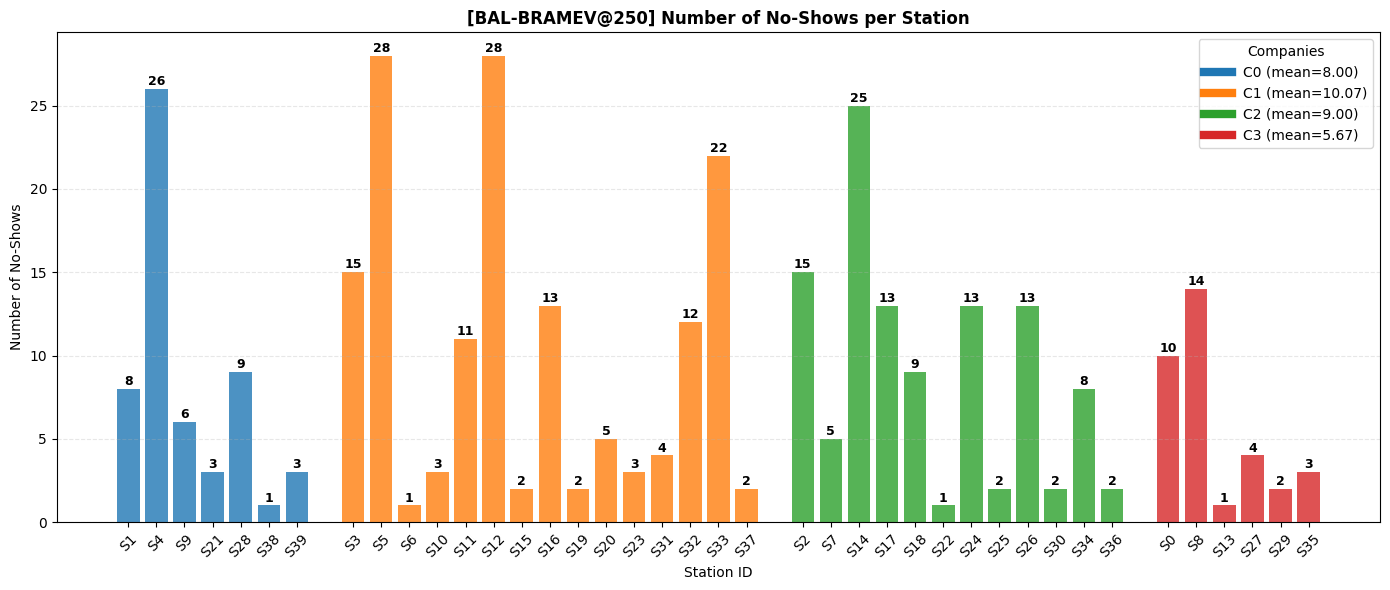

In [188]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [189]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,1,58,48,8,0,0,0.827586,0.137931,0.0,0.0
1,0,4,152,125,26,0,0,0.822368,0.171053,0.0,0.0
2,0,9,32,26,6,0,0,0.812500,0.187500,0.0,0.0
3,0,21,15,12,3,0,0,0.800000,0.200000,0.0,0.0
4,0,28,30,21,9,0,0,0.700000,0.300000,0.0,0.0
5,0,38,7,6,1,0,0,0.857143,0.142857,0.0,0.0
6,0,39,27,24,3,0,0,0.888889,0.111111,0.0,0.0
7,1,3,50,35,15,0,0,0.700000,0.300000,0.0,0.0
8,1,5,174,146,28,0,0,0.839080,0.160920,0.0,0.0
9,1,6,3,2,1,0,0,0.666667,0.333333,0.0,0.0


#### **COMPARISON**

##### *Params*

In [190]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

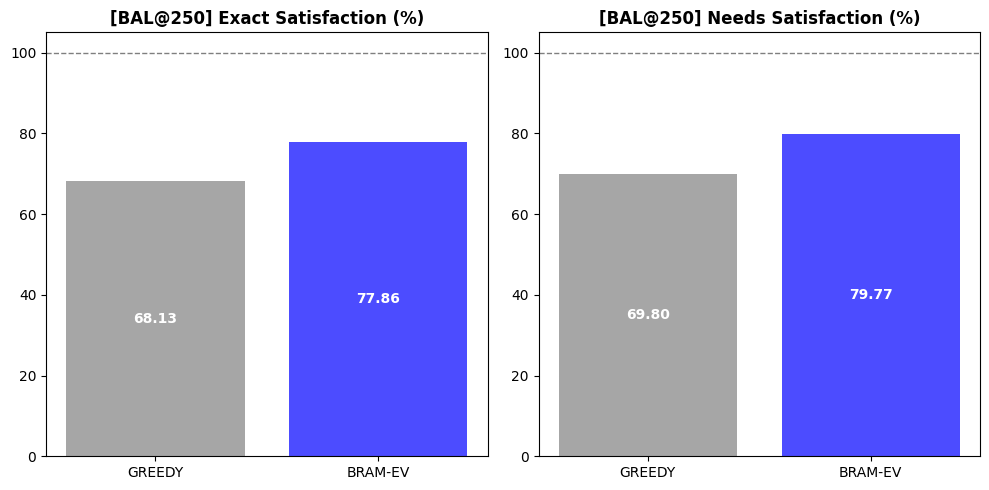

In [191]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

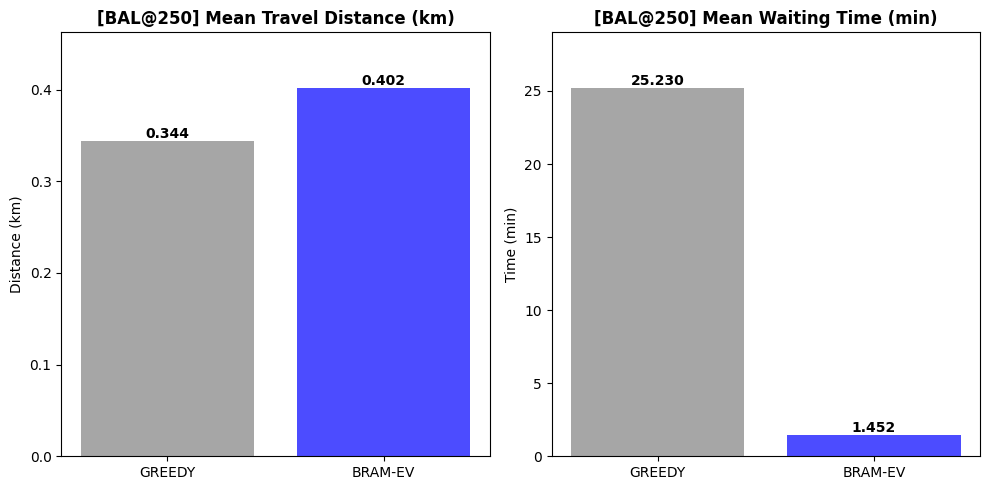

In [192]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

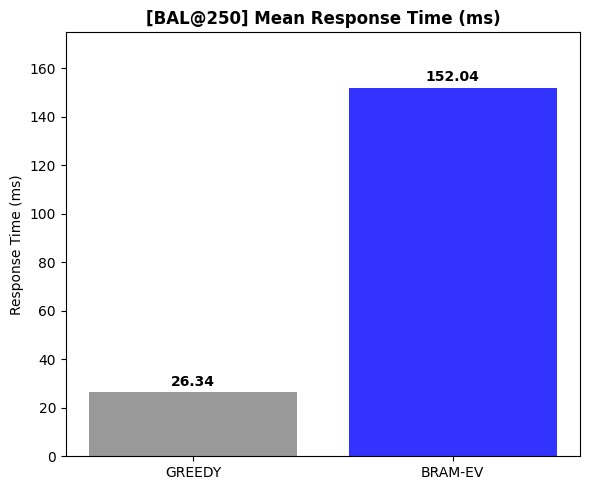

In [193]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

## **COMPARISON**

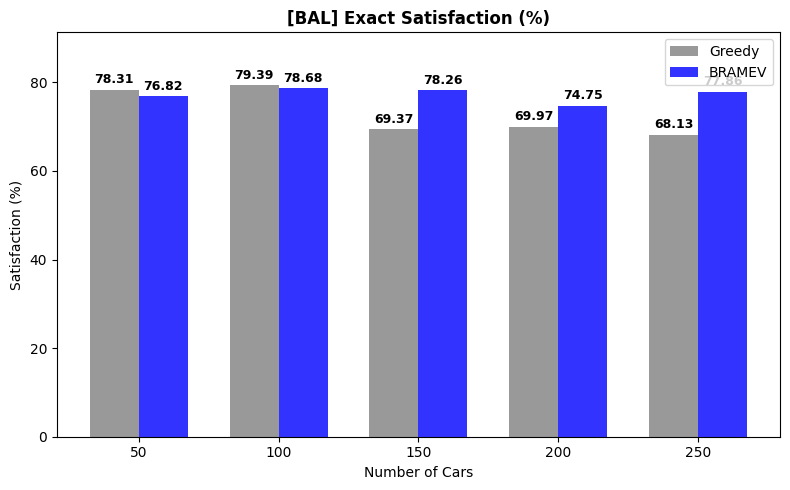

In [194]:
plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

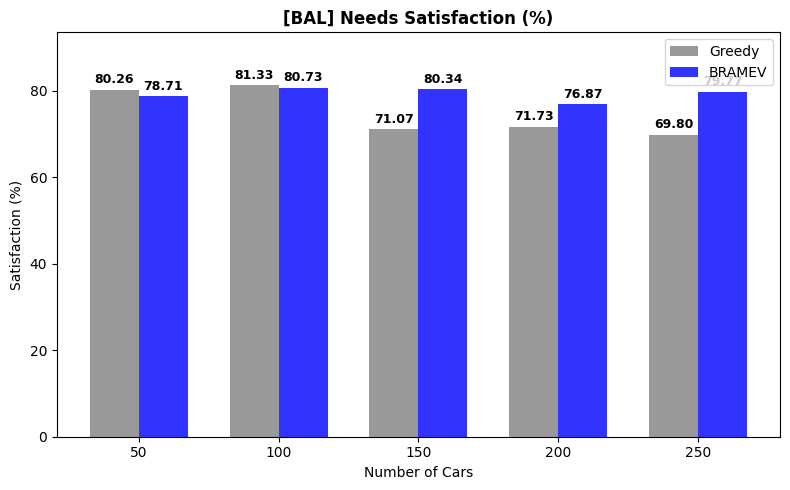

In [195]:
plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

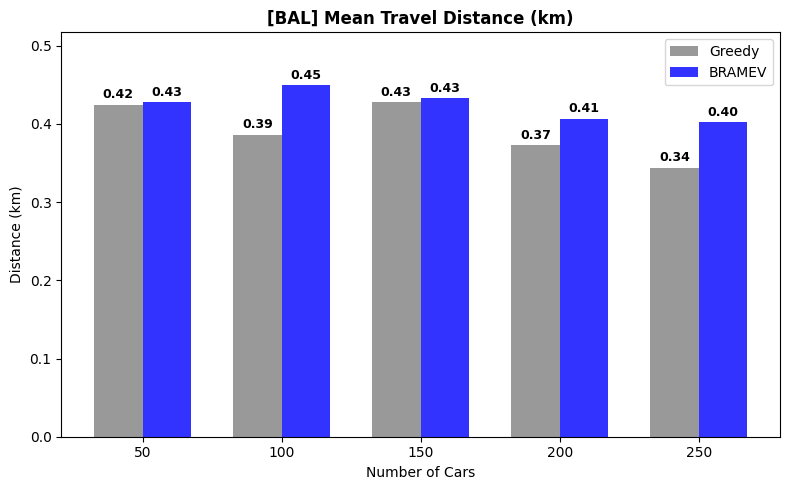

In [196]:
plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


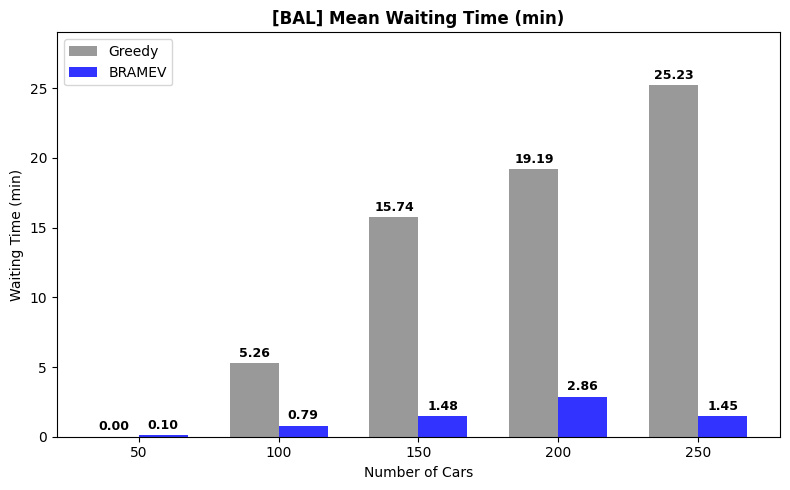

In [197]:
plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


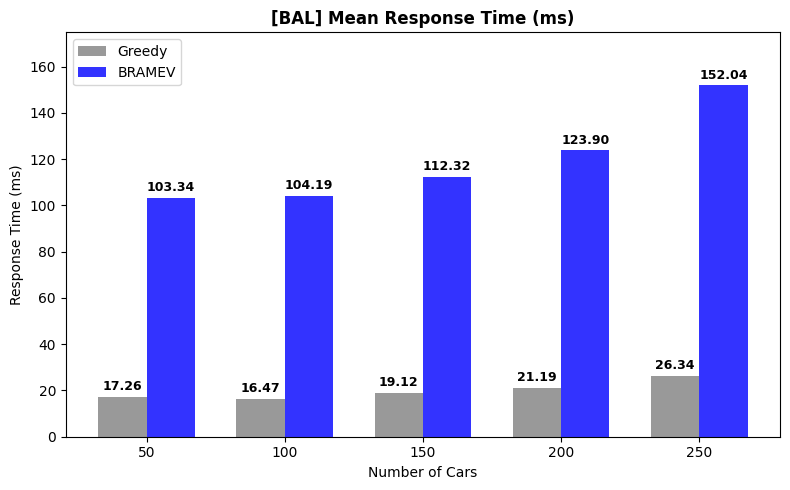

In [198]:
plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)
